In [17]:
# import wandb
import rdkit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl

# from pytorch_lightning.callbacks import RichProgressBar
# from pytorch_lightning.loggers import WandbLogger

from torchinfo import summary
from smiles_utils import *

torch.set_default_dtype(torch.float32)

In [18]:
class Delimited:
    def __init__(self):
        pass

    def __call__(self, line):
        smiles = line[0]
        smiles_sol = line[1]
        prop = np.array(line[2:])
        return smiles, smiles_sol,prop

class MolGraphDataset(Dataset):
    def __init__(self, file_path, set_name, transform=None):
        self.data = pd.read_csv(file_path+set_name+'.csv')
        self.file_path = file_path
        self.conditional = Delimited()
        
    
    def __len__(self):
        return len(self.data)
    
    def _convertToAdj(self,smiles_list):
        adj = [Chem.rdmolops.GetAdjacencyMatrix(Chem.MolFromSmiles(i),useBO=True)\
               +np.eye(len(Chem.MolFromSmiles(i).GetAtoms()))\
               if i !='gas' else np.zeros([2,2]) for i in smiles_list]
        
        max_atom_nums = np.max([i_adj.shape[0] for i_adj in adj])
        
        adj = np.concatenate([np.pad(i_adj,((0,max_atom_nums-i_adj.shape[0]),
                                            (0,max_atom_nums-i_adj.shape[0])),
                                     'constant',
                                     constant_values=0).reshape(1,
                                                                max_atom_nums,
                                                                max_atom_nums) for i_adj in adj],
                             axis=0)
        
        return adj, max_atom_nums
    
    def _convertToFeatures(self,smiles_list,max_atom_nums):
        features = [np.concatenate([np.concatenate([atom_symbol_HNums(atom),
                                                    atom_degree(atom),
                                                    atom_Aroma(atom),
                                                    atom_Hybrid(atom),
                                                    atom_ring(atom),
                                                    atom_FC(atom)],
                                                   axis=0).reshape(1,-1)\
                                    for atom in Chem.MolFromSmiles(i).GetAtoms()],axis=0)\
                    if i !='gas' else np.zeros([2,45]) for i in smiles_list]
        
        features = np.concatenate([np.pad(i_features,
                                          ((0,max_atom_nums-i_features.shape[0]),
                                           (0,0)),
                                          'constant',
                                          constant_values=0).reshape(1,
                                                                     max_atom_nums,
                                                                     -1)\
                                   for i_features in features],axis=0)
        
        EZ_features = [EZ_stereo(smiles) if smiles !='gas'\
                       else np.zeros([2,2]) for smiles in smiles_list]
        
        EZ_features = np.concatenate([np.pad(i_EZ_features,
                                             ((0,max_atom_nums-i_EZ_features.shape[0]),(0,0)),
                                             'constant', constant_values=0).reshape(1,max_atom_nums,-1)\
                                      for i_EZ_features in EZ_features],axis=0)
        
        features = np.concatenate([features,EZ_features],axis=2)
        
        return features
    
    def _make_matrix(self,smiles_list):
        adj, max_atom_nums = self._convertToAdj(smiles_list)
        features = self._convertToFeatures(smiles_list,max_atom_nums)
        
        return features, adj
        
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        batch = np.array(self.data.iloc[idx]).reshape(1,-1)
        smiles_list, smiles_sol_list,prop = list(),list(),list()
        for record_i in batch:
            smiles_i,smiles_sol_i,prop_i = self.conditional(record_i)
            smiles_list.append(smiles_i)
            smiles_sol_list.append(smiles_sol_i)
            prop.append(prop_i)
            
        chrom_X,chrom_A = self._make_matrix(smiles_list)
        X_A = np.concatenate([chrom_X,chrom_A],axis=2)
        
        sol_X,sol_A = self._make_matrix(smiles_sol_list)
        X_A_sol = np.concatenate([sol_X,sol_A],axis=2)
        
        prop = pd.DataFrame(prop)
        sample = {'input':[X_A,X_A_sol],'output':np.array(prop).astype('float32')}
        return sample
    
def collate_max_atoms(samples):
    max_numatom = np.max([i["input"][0].shape[1] for i in samples])
    max_numatom_sol = np.max([i["input"][1].shape[1] for i in samples])
    padding_num = [max_numatom-i["input"][0].shape[1] for i in samples]
    padding_num_sol = [max_numatom_sol-i["input"][1].shape[1] for i in samples]
    padded_samples = [nn.functional.pad(torch.from_numpy(i["input"][0]),(0,num,0,num),value=0) for i,num in zip(samples, padding_num)]
    padded_samples_sol = [nn.functional.pad(torch.from_numpy(i["input"][1]),(0,num,0,num),value=0) for i,num in zip(samples, padding_num_sol)]
    output = np.stack([i["output"] for i in samples],axis=0)
    
    return ([torch.stack(padded_samples).squeeze().type(torch.float32).contiguous(), 
             torch.stack(padded_samples_sol).squeeze().type(torch.float32).contiguous()], 
            torch.from_numpy(output.squeeze()).type(torch.float32).contiguous())

In [19]:
class GCN(nn.Module):
    def __init__(self, unit, input_shape, activation=nn.ReLU(), is_bias=False):
        super(GCN, self).__init__()
        self.hidden_dim = unit
        self.input_shape = input_shape
        self.activation= activation
        
        self.Linear = nn.Linear(input_shape, self.hidden_dim, bias=is_bias)
        
        if unit != input_shape:
            self.Linear_dim = nn.Linear(input_shape, self.hidden_dim, bias=is_bias)
            nn.init.xavier_uniform_(self.Linear_dim.weight)
            
        nn.init.xavier_uniform_(self.Linear.weight)
        
    def forward(self, X, A):
        
        mat = torch.matmul(A, self.Linear(X))
        output = self.activation(mat)
        
        if self.hidden_dim == self.input_shape:
            output += X
        else:
            output += self.Linear_dim(X)
            
        return  output

In [20]:
class GCNNet(pl.LightningModule):
    def __init__(self, file_path, pred_dim=9):
        super().__init__()
        self.file_path = file_path
        self.pred_dim = pred_dim
        self.depth = 6
        self.dims = [47,]+[128,]*self.depth
        activation = nn.LeakyReLU(0.1)
        self.loss_fn = self.mae_loss
        is_bias = False
        
        self.GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        self.sol_GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        
        self.linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(1024),
                                        nn.Linear(1024, 512, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(512)])
        self.sol_linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(1024),
                                            nn.Linear(1024, 512, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(512),])
        
        self.pred_list = nn.ModuleList([nn.Linear(1024, 512, bias=True),
                                      nn.LeakyReLU(0.1),
                                      nn.BatchNorm1d(512),
                                        nn.Linear(512, 256, bias=True),
                                      nn.LeakyReLU(0.1),
                                      nn.BatchNorm1d(256),
                                        nn.Linear(256, 128, bias=True),
                                      nn.LeakyReLU(0.1),
                                      nn.BatchNorm1d(128),
                                      nn.Dropout(0.5),
                                      nn.Linear(128, pred_dim, bias=True)])
        
        self.linear_list.apply(self._init_weights)
        self.sol_linear_list.apply(self._init_weights)
        self.pred_list.apply(self._init_weights)
        self.train_preds = []
        self.train_props = []
        self.val_preds = []
        self.val_props = []
        self.train_error = []
        self.val_error = []
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0)
    def forward(self, X_A, X_A_sol):
        
        X, A = X_A[:,:,:47], X_A[:,:,47:]
        X_sol, A_sol =  X_A_sol[:,:,:47], X_A_sol[:,:,47:]
        
        H = X
        H_sol = X_sol
        
        for GCN, sol_GCN in zip(self.GCN_list, self.sol_GCN_list):
            H = GCN(H, A)
            H_sol = sol_GCN(H_sol, A_sol)
            
        H = torch.sum(H, dim=-2)
        H_sol = torch.sum(H_sol, dim=-2)
        
        for layer, sol_layer in zip(self.linear_list, self.sol_linear_list):
            H = layer(H)
            H_sol = sol_layer(H_sol)
        output = torch.cat([H,H_sol], dim=-1)
        
        for layer in self.pred_list:
            output = layer(output)
            
        return output
    
    def configure_optimizers(self):
        learning_rate = 1e-3
        wd = 5e-4
        lr_decay = 1-0.015
        lr_patience = 50
        self.optimizer = torch.optim.Adam(self.parameters(), lr = learning_rate, weight_decay = wd,)# eps=1e-7,  amsgrad=False)
        scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=lr_patience, gamma=lr_decay)
        sch_config = {
            "scheduler" : scheduler,
            "interval" : "epoch",
        }
        return [self.optimizer], [sch_config]
    
    def mae_loss(self, y, y_hat):
        y = y.reshape(-1, self.pred_dim)
        return torch.mean(torch.absolute((y[~torch.isnan(y)]-y_hat[~torch.isnan(y)])))
    
    def training_step(self, train_batch, batch_idx):
        x, y = train_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss
    
    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss    

In [21]:
# Build 한 GCNNet Architecture 의 모든 learnable 한 파라미터(W,b) 개수를 확인해보기!

model_test = GCNNet("data/")

from prettytable import PrettyTable

def count_parameters(model_test):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model_test.named_parameters():
        if not parameter.requires_grad: continue
        param = parameter.numel()
        table.add_row([name, param])
        total_params+=param
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params

count_parameters(model_test)

+----------------------------------+------------+
|             Modules              | Parameters |
+----------------------------------+------------+
|     GCN_list.0.Linear.weight     |    6016    |
|   GCN_list.0.Linear_dim.weight   |    6016    |
|     GCN_list.1.Linear.weight     |   16384    |
|     GCN_list.2.Linear.weight     |   16384    |
|     GCN_list.3.Linear.weight     |   16384    |
|     GCN_list.4.Linear.weight     |   16384    |
|     GCN_list.5.Linear.weight     |   16384    |
|   sol_GCN_list.0.Linear.weight   |    6016    |
| sol_GCN_list.0.Linear_dim.weight |    6016    |
|   sol_GCN_list.1.Linear.weight   |   16384    |
|   sol_GCN_list.2.Linear.weight   |   16384    |
|   sol_GCN_list.3.Linear.weight   |   16384    |
|   sol_GCN_list.4.Linear.weight   |   16384    |
|   sol_GCN_list.5.Linear.weight   |   16384    |
|       linear_list.0.weight       |   131072   |
|        linear_list.0.bias        |    1024    |
|       linear_list.2.weight       |    1024    |


2199817

### GCNNet에 Train 된 Weight 적용하기

In [22]:
db_path = 'data/' # train 된 weight 가 저장된 위치

model_trained = GCNNet.load_from_checkpoint(checkpoint_path=db_path + '/last_For_All_AdachDB_GCN_TL.ckpt', # GCNNet에 weight 적용!
    file_path=db_path + '/last_For_All_AdachDB_GCN_TL.ckpt')

In [23]:
model_trained # 잘 적용 되었다!

GCNNet(
  (GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (sol_GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (linear_list): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_st

### 새로운 GCNNet_transfer Model building 하기

In [24]:
# 사전 훈련된 Model 의 parameter 들은 고정시키기!

for param in model_trained.parameters():
    param.requires_grad = False

In [25]:
# 교체할 레이어를 새로 정의

model_trained.pred_dim = 336

'''
new_layers = [nn.Linear(512, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.5),
              nn.Linear(1024, 2048, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.4),
              nn.Linear(2048, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.2),
              nn.Linear(1024, model_trained.pred_dim, bias=True)]
              '''
new_layers = [ nn.Linear(512, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.5),
              nn.Linear(1024, 512, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.3),
              nn.Linear(512, model_trained.pred_dim, bias=True)]


# 원래의 pred_list 중에서 교체하고 싶은 마지막 3개의 레이어를 바꿈
# 원래의 pred_list를 가져오되, 앞의 3 layer 는 그대로 유지하고, 나머지를 교체할 레이어로 변경

model_trained.pred_list = nn.ModuleList(list(model_trained.pred_list[:3]) + new_layers)
model_trained

GCNNet(
  (GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (sol_GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (linear_list): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [26]:
# 새롭게 교체한, 마지막 pred_list 의 Grad 켜줌! 

for param in list(model_trained.pred_list[3:]):
    param.requires_grad = True 

In [27]:
# 열려있는 Layer 확인!

for name, param in model_trained.named_parameters(): # resnet18 model 의 parameter 에 접근하여, 이름과 값을 가져옴
    
    if param.requires_grad == True: # 그 중에서, requires_grad=True 가 켜져있는 것?
        
        print(name) # 그 이름과, 파라미터! : 마지막 한 layer 만 켜져있음!

pred_list.3.weight
pred_list.3.bias
pred_list.6.weight
pred_list.6.bias
pred_list.9.weight
pred_list.9.bias


In [28]:
count_parameters(model_trained)

+--------------------+------------+
|      Modules       | Parameters |
+--------------------+------------+
| pred_list.3.weight |   524288   |
|  pred_list.3.bias  |    1024    |
| pred_list.6.weight |   524288   |
|  pred_list.6.bias  |    512     |
| pred_list.9.weight |   172032   |
|  pred_list.9.bias  |    336     |
+--------------------+------------+
Total Trainable Params: 1222480


1222480

### 새로운 GCNNet_transfer Model 학습하기

In [29]:
### 2. DataLoader 를 통한 : train, val. Data 준비 ###

db_path = 'data/' # train 된 model 이 저장된 위치

train_set = MolGraphDataset(db_path,"Train_abs_spectrum_sum_12496_251216")
train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2, collate_fn=collate_max_atoms)

val_set = MolGraphDataset(db_path,"Test_abs_spectrum_sum_12496_251216")
val_loader = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

In [30]:
len(train_set) + len(val_set)

12496

In [15]:
from pytorch_lightning.loggers import CSVLogger

model_name = 'Transfer_learning_pred_layer'
model_path = 'model/'+model_name


csv_logger = CSVLogger(save_dir=db_path+model_path+"/logs/", name=model_name)

checkpoint_callback = pl.callbacks.ModelCheckpoint(dirpath=db_path+model_path, 
                                                   filename='{epoch}-{train_loss:.4f}-{val_loss:.4f}',
                                                   every_n_epochs=100,
                                                   save_top_k=10,
                                                   monitor='val_loss',
                                                   mode='min',
                                                   save_last=True)

lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval="epoch")

In [ ]:
### trainer Module : pl.Trainer() 로 정의하여, epoch 부분을 파격적으로 간결화


trainer = pl.Trainer(max_epochs=4000, accelerator='gpu', devices=[2], logger=csv_logger,
                     callbacks=[checkpoint_callback, lr_monitor]) 


trainer.fit(model_trained, train_loader, val_loader) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ufslab223/anaconda3/envs/hana_new/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:658: Checkpoint directory /home/ufslab223/Shared/URP_Intern/PDY/data/model/Transfer_learning_pred_layer exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name            | Type       | Params | Mode 
-------------------------------------------------------
0 | GCN_list        | ModuleList | 94.0 K | train
1 | sol_GCN_list    | ModuleList | 94.0 K | train
2 | linear_list     | ModuleList | 659 K  | train
3 | sol_linear_list | ModuleList | 659 K  | train
4 | pred_list       | ModuleList | 1.7 M  | train
-------------------------------------------------------
1.2 M     Trainable params
2.0 M     Non-trainable params
3.3 M     Total params
13.025    Total estimated model params size (MB)
54        Modules in train mode
0         Modul

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ufslab223/anaconda3/envs/hana_new/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (44) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

# Evaluation

In [31]:
class GCNNet_Eval(pl.LightningModule):
    
    def __init__(self, file_path, pred_dim=336):
        super().__init__()
        self.file_path = file_path
        self.pred_dim = pred_dim
        self.depth = 6
        self.dims = [47,]+[128,]*self.depth
        activation = nn.LeakyReLU(0.1)
        self.loss_fn = self.mae_loss
        is_bias = False
        
        self.GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        self.sol_GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        
        self.linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(1024),
                                        nn.Linear(1024, 512, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(512)])
        
        self.sol_linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(1024),
                                            nn.Linear(1024, 512, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(512),])
        
        self.pred_list = nn.ModuleList([nn.Linear(1024, 512, bias=True), nn.LeakyReLU(0.1), nn.BatchNorm1d(512),
                                        nn.Linear(512, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.5),
                                        nn.Linear(1024, 512, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.3),
                                        nn.Linear(512, model_trained.pred_dim, bias=True)])

                                       
        self.linear_list.apply(self._init_weights)
        self.sol_linear_list.apply(self._init_weights)
        self.pred_list.apply(self._init_weights)
        self.train_preds = []
        self.train_props = []
        self.val_preds = []
        self.val_props = []
        self.train_error = []
        self.val_error = []
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0)
    def forward(self, X_A, X_A_sol):
        
        X, A = X_A[:,:,:47], X_A[:,:,47:]
        X_sol, A_sol =  X_A_sol[:,:,:47], X_A_sol[:,:,47:]
        
        H = X
        H_sol = X_sol
        
        for GCN, sol_GCN in zip(self.GCN_list, self.sol_GCN_list):
            H = GCN(H, A)
            H_sol = sol_GCN(H_sol, A_sol)
            
        H = torch.sum(H, dim=-2)
        H_sol = torch.sum(H_sol, dim=-2)
        
        for layer, sol_layer in zip(self.linear_list, self.sol_linear_list):
            H = layer(H)
            H_sol = sol_layer(H_sol)
        output = torch.cat([H,H_sol], dim=-1)
        
        for layer in self.pred_list:
            output = layer(output)
            
        return output
    
    def configure_optimizers(self):
        learning_rate = 1e-3
        wd = 5e-4
        lr_decay = 1-0.015
        lr_patience = 50
        self.optimizer = torch.optim.Adam(self.parameters(), lr = learning_rate, weight_decay = wd,)# eps=1e-7,  amsgrad=False)
        scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=lr_patience, gamma=lr_decay)
        sch_config = {
            "scheduler" : scheduler,
            "interval" : "epoch",
        }
        return [self.optimizer], [sch_config]
    
    def mae_loss(self, y, y_hat):
        y = y.reshape(-1, self.pred_dim)
        return torch.mean(torch.absolute((y[~torch.isnan(y)]-y_hat[~torch.isnan(y)])))
    
    def training_step(self, train_batch, batch_idx):
        x, y = train_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss
    
    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss    

In [32]:
## 분자 찾기 위하여, shuffle=False 로 다시 설정함

train_set = MolGraphDataset(db_path,"Train_abs_spectrum_sum_12496_251216")
train_loader = DataLoader(train_set, batch_size=50, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

val_set = MolGraphDataset(db_path,"Test_abs_spectrum_sum_12496_251216")
val_loader = DataLoader(val_set, batch_size=50, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

In [33]:
len(train_set) + len(val_set)

12496

In [34]:
db_path = 'data/' # train 된 weight 가 저장된 위치

model_trained = GCNNet_Eval.load_from_checkpoint(checkpoint_path=db_path + model_path + "/last.ckpt", # GCNNet에 weight 적용!
    file_path=db_path + model_path + "/last.ckpt")

model_trained

GCNNet_Eval(
  (GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (sol_GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (linear_list): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_runni

In [35]:
## Predict !!!

train_pred = list() # 예측
train_y = list() # 정답

val_pred = list() # 예측
val_y = list() # 정답

model_trained = model_trained.cuda(1)
model_trained.eval() # dropout,batchnorm,.. 등등 학습에 사용하는 Option 들 비 활성화 됨!


with torch.no_grad(): # 아래 계산시 B.P.을 통한 weight update 하지 않음!
    
    for x, y in train_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        train_pred.append(y_hat)                
        train_y.append(y)        
        
    for x, y in val_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        val_pred.append(y_hat)          
        val_y.append(y)
       

train_pred = torch.cat(train_pred,axis=0).cpu().numpy()
train_y = torch.cat(train_y,axis=0).cpu().numpy()

val_pred = torch.cat(val_pred,axis=0).cpu().numpy()
val_y = torch.cat(val_y,axis=0).cpu().numpy()

In [36]:
### Evaluation : MAE(Mean Absolute Error) ###

train_mae = []
val_mae = []

train_rmae = []
val_rmae = []

train_norm_mae = []  # Normal MAE 저장 리스트
val_norm_mae = []    # Normal MAE 저장 리스트


def mae(y, pred):        
    non_nan_indices = ~np.isnan(y) & ~np.isnan(pred)    
    return np.mean(np.abs(y[non_nan_indices] - pred[non_nan_indices]))

def rmae(y, pred):
    non_nan_indices = ~np.isnan(y) & ~np.isnan(pred)
    return np.mean((np.abs(y[non_nan_indices] - pred[non_nan_indices])) / (y[non_nan_indices] + 1))

def norm_mae(y, pred):  
    y = torch.tensor(y, dtype=torch.float32)
    pred = torch.tensor(pred, dtype=torch.float32)
    
    y_max = torch.max(torch.nan_to_num(y), dim=0, keepdim=True)[0]  # y에서 NaN을 0으로 대체한 후 max 계산
    non_nan_mask = ~torch.isnan(y) & ~torch.isnan(pred)  # NaN이 아닌 값 필터링
    
    return torch.mean(torch.abs((y[non_nan_mask] / y_max) - (pred[non_nan_mask] / y_max))).item()


# Train 데이터에 대한 Metric 계산
for i in range(train_y.shape[0]):  
    train_mae.append(mae(train_y[i], train_pred[i]))
    # train_rmae.append(rmae(train_y[i], train_pred[i]))
    # train_sis.append(sis(train_y[i], train_pred[i]))
    train_norm_mae.append(norm_mae(train_y[i], train_pred[i]))  # Norm-MAE 추가

# Validation 데이터에 대한 Metric 계산
for i in range(val_y.shape[0]):
    val_mae.append(mae(val_y[i], val_pred[i]))
    # val_rmae.append(rmae(val_y[i], val_pred[i]))
    # val_sis.append(sis(val_y[i], val_pred[i]))
    val_norm_mae.append(norm_mae(val_y[i], val_pred[i]))  # Norm-MAE 추가

    

# Metric 결과 출력
print("Train의 MAE 값 :", np.mean(train_mae))
print("Val의 MAE 값 :", np.mean(val_mae))
print()
print("Train의 Norm-MAE 값 :", np.mean(train_norm_mae))  # Norm-MAE 출력
print("Val의 Norm-MAE 값 :", np.mean(val_norm_mae))  # Norm-MAE 출력

Train의 MAE 값 : 2027.6467
Val의 MAE 값 : 3456.8484

Train의 Norm-MAE 값 : 0.041721432613163384
Val의 Norm-MAE 값 : 0.07764705890717771


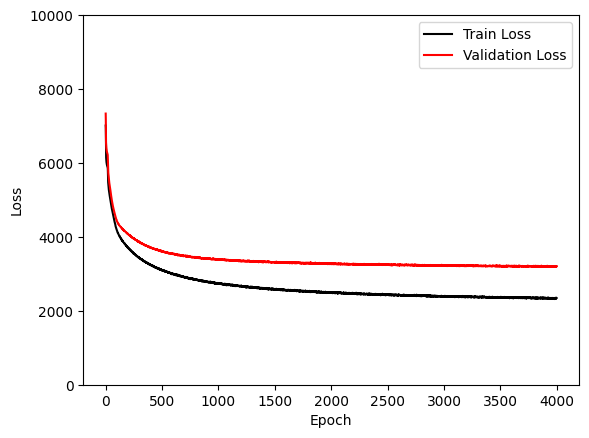

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
log_plot = pd.read_csv(db_path + model_path + "/logs/" + model_name + "/version_0/metrics.csv")
log_plot = log_plot.loc[:, ['epoch', 'val_loss', 'train_loss_epoch']]

# 결측값 제거 및 인덱스 재설정
val_loss_log = log_plot['val_loss'].dropna().reset_index(drop=True)
train_loss_log = log_plot['train_loss_epoch'].dropna().reset_index(drop=True)

# 두 데이터를 합침
log_plot_sum = pd.concat([train_loss_log, val_loss_log], axis=1)

# x 값 재설정 (길이를 로그 데이터와 맞춤)
x = range(len(log_plot_sum))

# Series 객체를 numpy 배열로 변환
train_loss = log_plot_sum['train_loss_epoch'].values
val_loss = log_plot_sum['val_loss'].values

# 그래프 그리기
plt.plot(x, train_loss, c='k', label='Train Loss')
plt.plot(x, val_loss, c='r', label='Validation Loss')
plt.ylim(0, 10000)

# 레이블 추가
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# 그래프 보여주기
plt.show()

In [36]:
db_path

'transferlearning_weight/'

In [37]:
## 분자 찾기 위하여, shuffle=False 로 다시 설정함

train_set = MolGraphDataset(db_path,"Train_DLOS_7800_350_1000_simlilarity_four_peak")
train_loader = DataLoader(train_set, batch_size=50, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

val_set = MolGraphDataset(db_path,"Test_DLOS_7800_350_1000_simlilarity_four_peak")
val_loader = DataLoader(val_set, batch_size=50, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

app_final = MolGraphDataset(db_path,"candidates4")
final_loader = DataLoader(app_final, batch_size=50, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

In [38]:
len(train_set) + len(val_set)

7697

In [39]:
len(train_set)

6280

In [40]:
len(app_final)

13042

In [41]:
db_path = 'transferlearning_weight/' # train 된 weight 가 저장된 위치

model_trained = GCNNet_Eval.load_from_checkpoint(checkpoint_path=db_path + model_path + "/last.ckpt", # GCNNet에 weight 적용!
    file_path=db_path + model_path + "/last.ckpt")

model_trained

GCNNet_Eval(
  (GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (sol_GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (linear_list): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_runni

In [42]:
db_path + model_path

'transferlearning_weight/model/DLOS_trasfer_8000ea_new_weight_fourpeak_special_add_4layer_test'

In [43]:
## Predict !!!

train_pred = list() # 예측
train_y = list() # 정답

val_pred = list() # 예측
val_y = list() # 정답

final_pred = list() # 예측
fianl_y = list() # 정답


model_trained = model_trained.cuda(1)
model_trained.eval() # dropout,batchnorm,.. 등등 학습에 사용하는 Option 들 비 활성화 됨!


with torch.no_grad(): # 아래 계산시 B.P.을 통한 weight update 하지 않음!
    
    for x, y in train_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        train_pred.append(y_hat)                
        train_y.append(y)        
        
    for x, y in val_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        val_pred.append(y_hat)          
        val_y.append(y)
       
    for x, y in final_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        final_pred.append(y_hat)          
        fianl_y.append(y)


train_pred = torch.cat(train_pred,axis=0).cpu().numpy()
train_y = torch.cat(train_y,axis=0).cpu().numpy()

val_pred = torch.cat(val_pred,axis=0).cpu().numpy()
val_y = torch.cat(val_y,axis=0).cpu().numpy()

final_pred = torch.cat(final_pred,axis=0).cpu().numpy()
fianl_y = torch.cat(fianl_y,axis=0).cpu().numpy()

In [51]:
print(type(final_pred))
print(final_pred.shape)

<class 'numpy.ndarray'>
(13042, 326)


In [53]:
final_pred_df = pd.DataFrame(final_pred)
final_pred_df.to_csv('final_pred.csv', index=False, header=False)

In [54]:
final_pred_df

,0,1,2,3,4,5,6,7,8,9,...,316,317,318,319,320,321,322,323,324,325
0,36171.671875,37585.640625,38960.117188,40318.796875,41579.691406,42775.710938,43829.992188,44732.078125,45299.617188,45565.207031,...,2.843341,1.160530,4.590846,3.879271,-2.842447,-2.998247,-0.484040,-0.379915,0.372893,0.390368
1,26755.828125,27214.191406,27502.648438,27624.171875,27584.669922,27427.775391,27169.921875,26813.072266,26221.337891,25441.000000,...,2.199111,1.347180,3.564650,2.474546,-2.013252,-1.174556,0.020090,0.605386,1.753143,1.299726
2,15242.417969,15620.614258,15923.255859,16149.889648,16304.275391,16396.251953,16431.187500,16402.628906,16241.896484,15967.191406,...,2.033278,0.745938,2.351750,1.453190,-0.994748,-0.847170,0.321730,0.536862,1.280695,0.565110
3,17399.933594,18065.763672,18686.966797,19278.597656,19824.902344,20322.230469,20751.406250,21131.574219,21361.736328,21449.345703,...,2.276365,0.876996,2.818383,2.107494,-1.093622,-1.115247,0.102354,0.257738,1.088773,0.434545
4,18938.482422,19510.779297,20015.511719,20458.472656,20820.277344,21118.449219,21345.078125,21473.363281,21427.732422,21218.769531,...,1.857533,0.676126,2.338496,1.713363,-1.438221,-1.293134,0.006668,0.276355,0.683719,0.543980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13037,11134.052734,11680.525391,12214.983398,12760.905273,13309.504883,13838.244141,14352.711914,14879.916016,15354.288086,15798.948242,...,1.801510,0.519287,2.515243,1.725428,-0.558202,-1.058621,0.060093,0.706507,0.374924,-0.108091
13038,9426.919922,9786.793945,10122.769531,10452.226562,10781.923828,11084.829102,11380.334961,11707.483398,11992.110352,12284.359375,...,1.631369,0.643671,2.519644,1.599847,-0.345048,-0.656677,0.262885,0.967071,0.746944,0.003234
13039,10350.517578,10725.107422,11068.799805,11397.564453,11712.328125,11995.056641,12258.389648,12526.178711,12736.092773,12924.992188,...,1.606598,0.391156,2.208097,1.577669,-0.384445,-0.818639,0.171687,0.705256,0.860966,0.160468
13040,13508.351562,14144.791992,14745.948242,15337.082031,15912.183594,16456.275391,16968.666016,17478.900391,17919.220703,18283.732422,...,4.061003,1.808299,4.464135,3.229990,0.449576,-1.019723,0.294690,0.990941,1.623922,0.306231


In [62]:
x = np.linspace(350, 1000, int((1000 - 350) / 2 + 1))
x

array([ 350.,  352.,  354.,  356.,  358.,  360.,  362.,  364.,  366.,
        368.,  370.,  372.,  374.,  376.,  378.,  380.,  382.,  384.,
        386.,  388.,  390.,  392.,  394.,  396.,  398.,  400.,  402.,
        404.,  406.,  408.,  410.,  412.,  414.,  416.,  418.,  420.,
        422.,  424.,  426.,  428.,  430.,  432.,  434.,  436.,  438.,
        440.,  442.,  444.,  446.,  448.,  450.,  452.,  454.,  456.,
        458.,  460.,  462.,  464.,  466.,  468.,  470.,  472.,  474.,
        476.,  478.,  480.,  482.,  484.,  486.,  488.,  490.,  492.,
        494.,  496.,  498.,  500.,  502.,  504.,  506.,  508.,  510.,
        512.,  514.,  516.,  518.,  520.,  522.,  524.,  526.,  528.,
        530.,  532.,  534.,  536.,  538.,  540.,  542.,  544.,  546.,
        548.,  550.,  552.,  554.,  556.,  558.,  560.,  562.,  564.,
        566.,  568.,  570.,  572.,  574.,  576.,  578.,  580.,  582.,
        584.,  586.,  588.,  590.,  592.,  594.,  596.,  598.,  600.,
        602.,  604.,

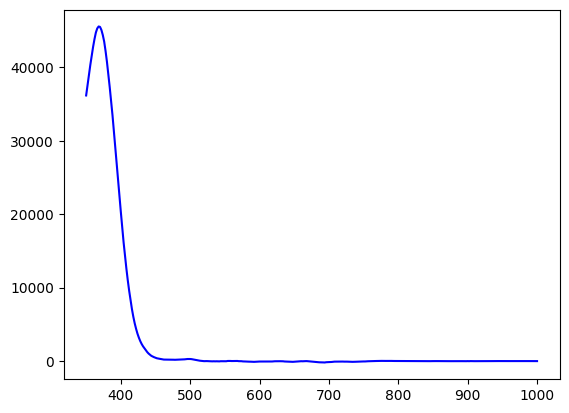

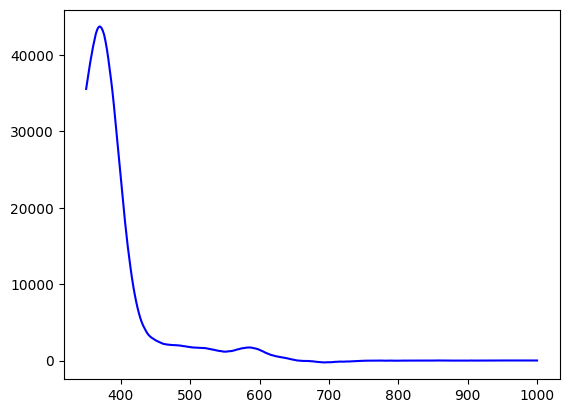

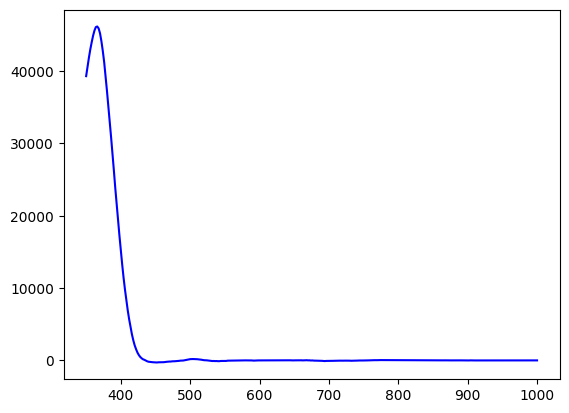

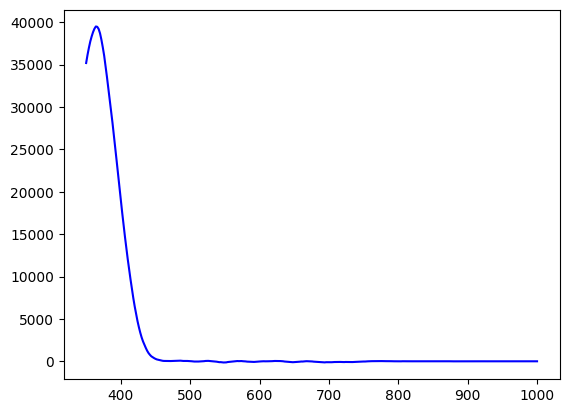

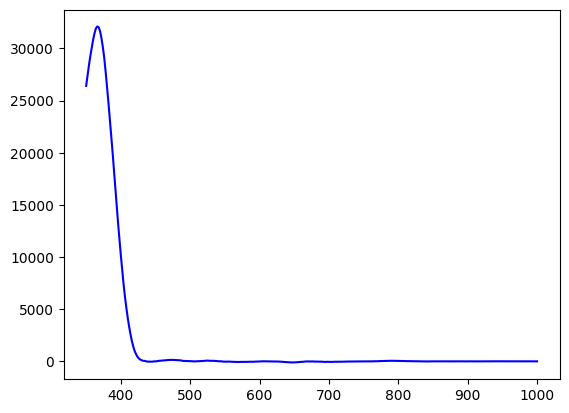

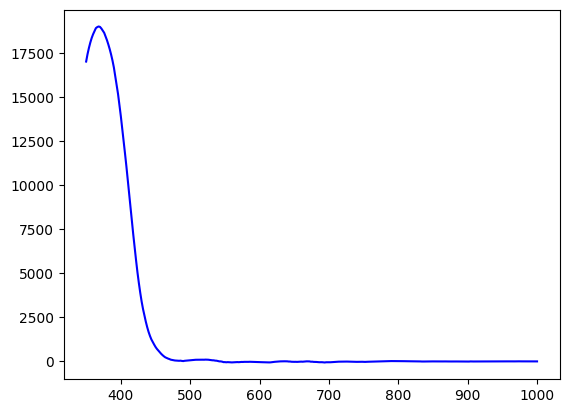

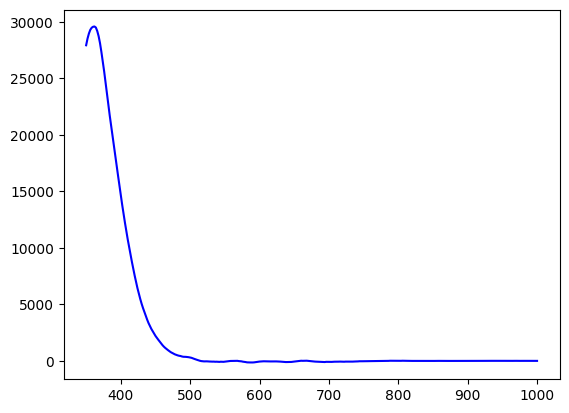

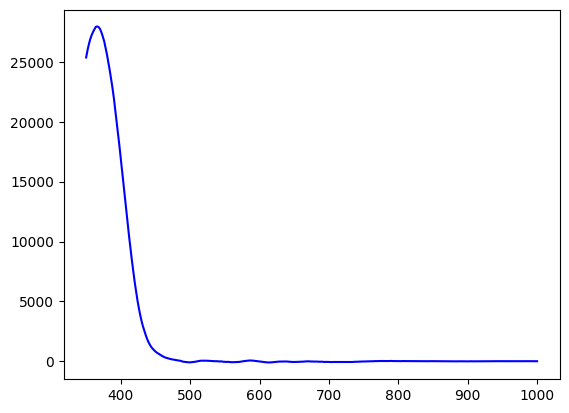

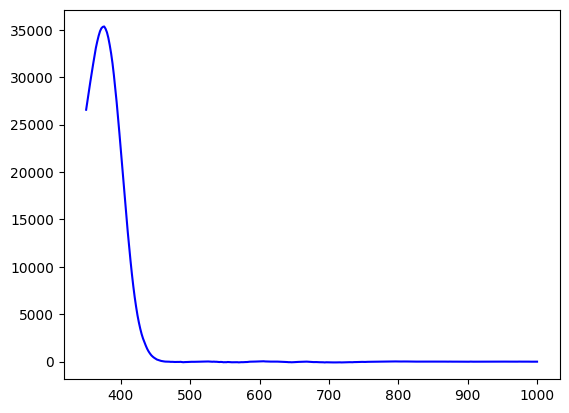

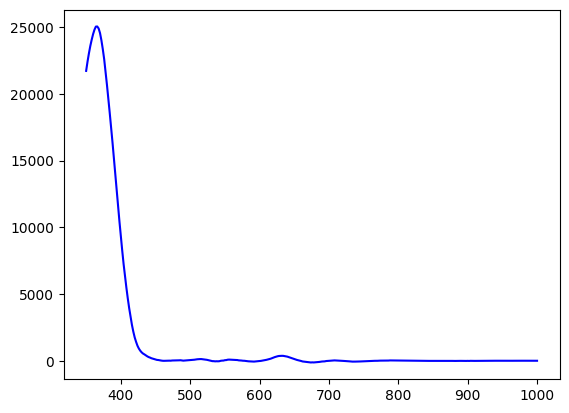

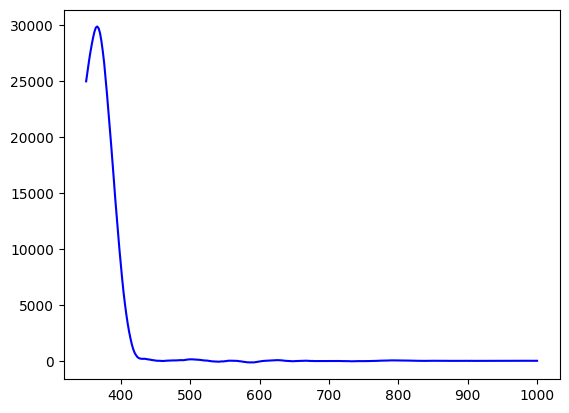

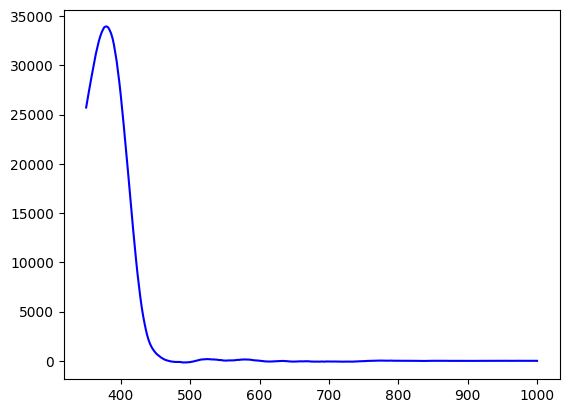

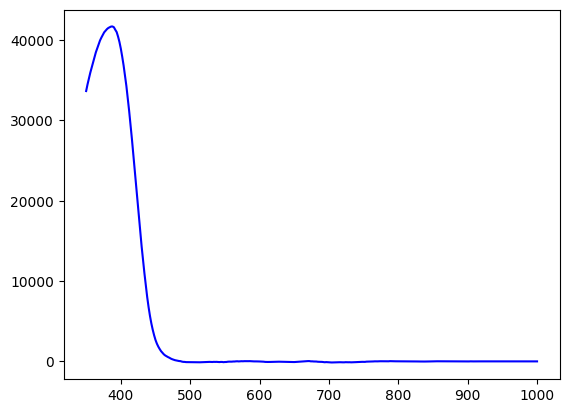

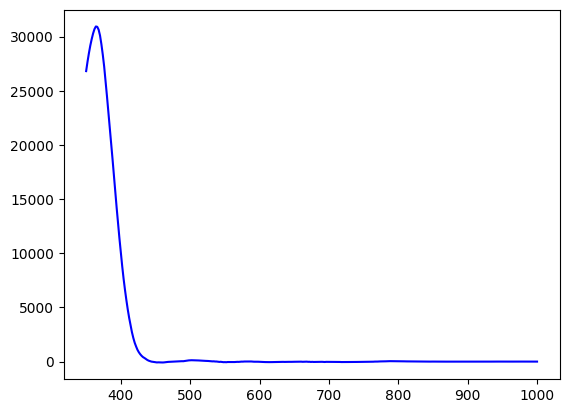

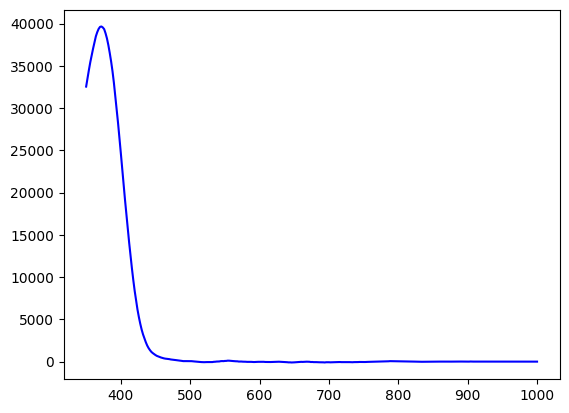

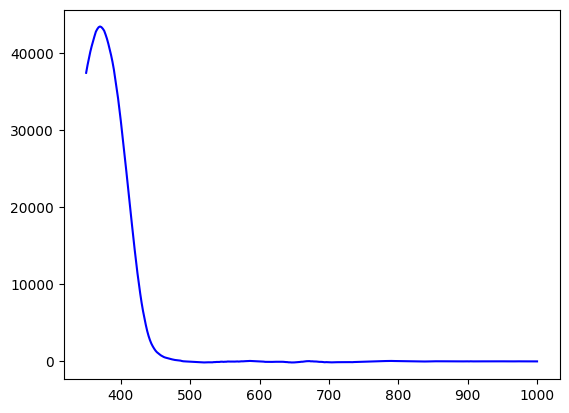

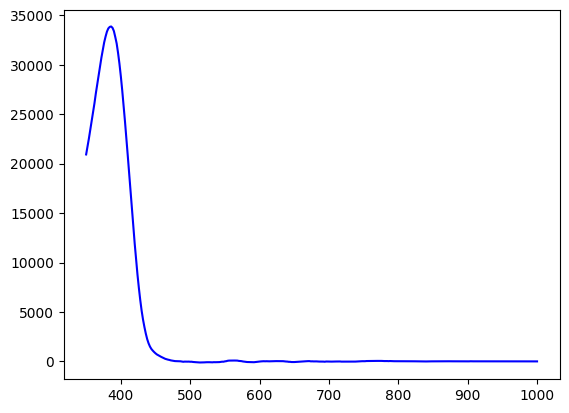

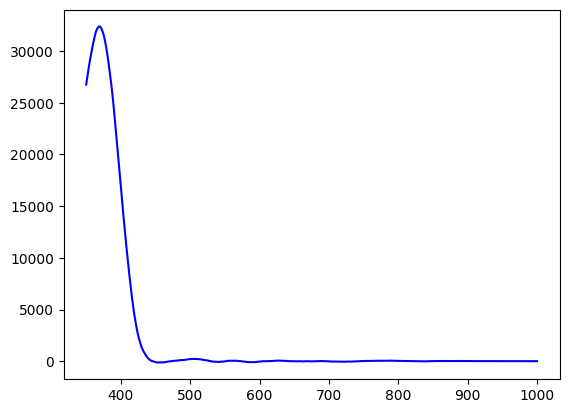

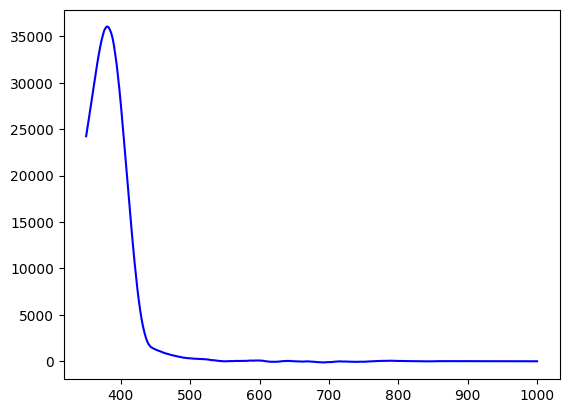

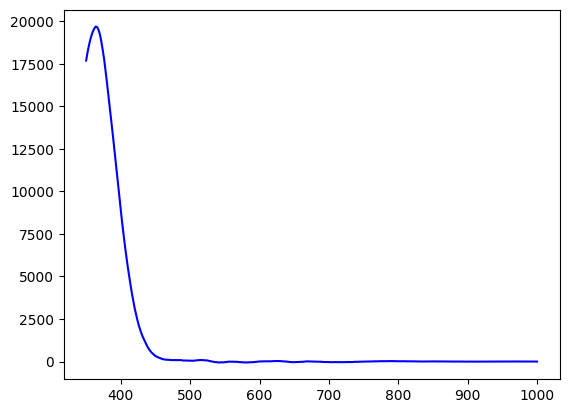

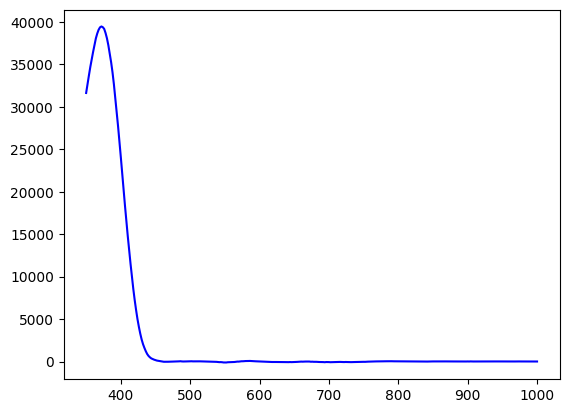

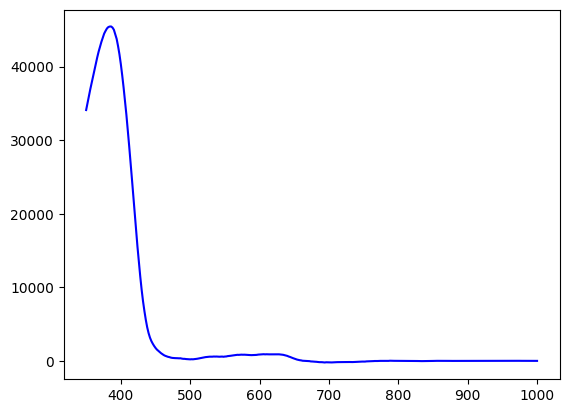

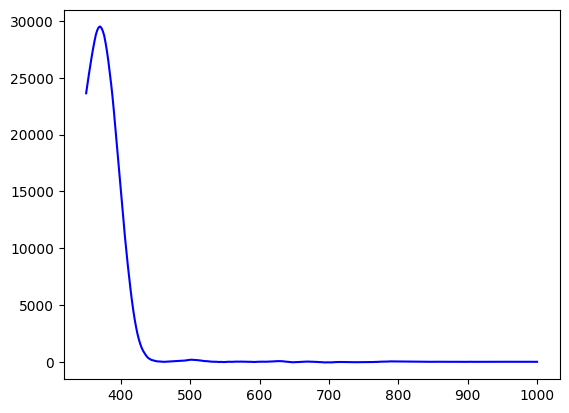

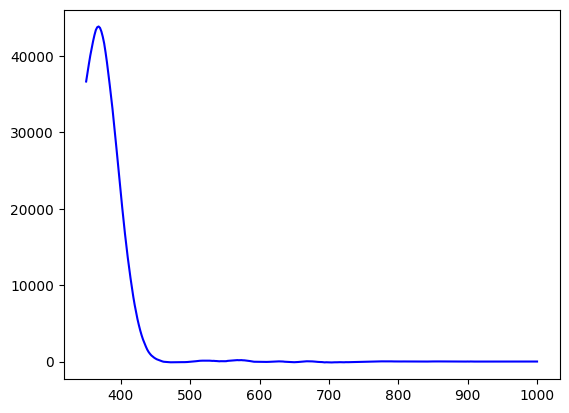

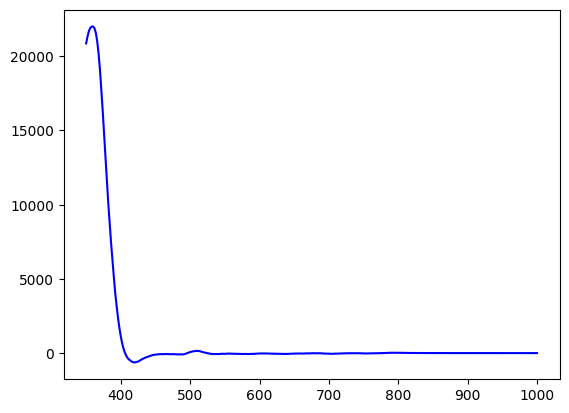

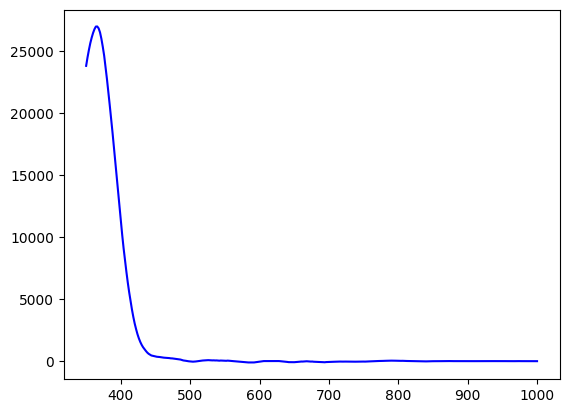

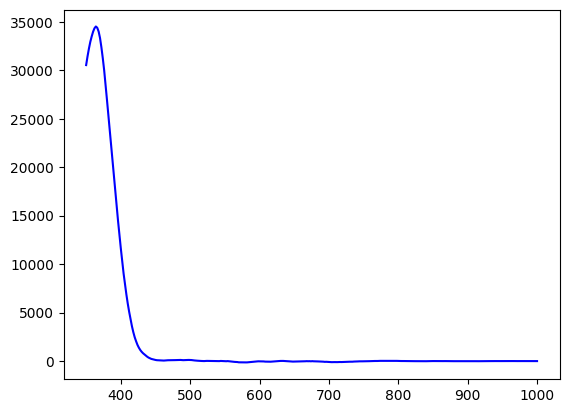

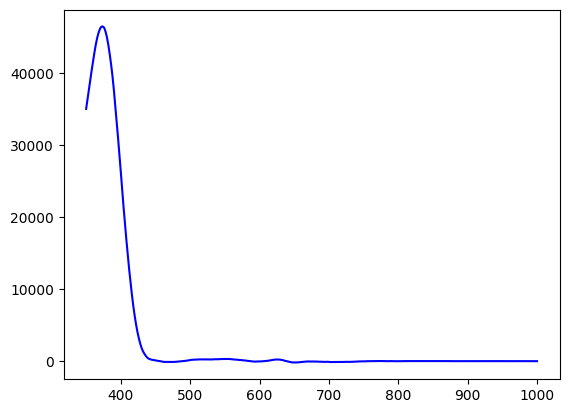

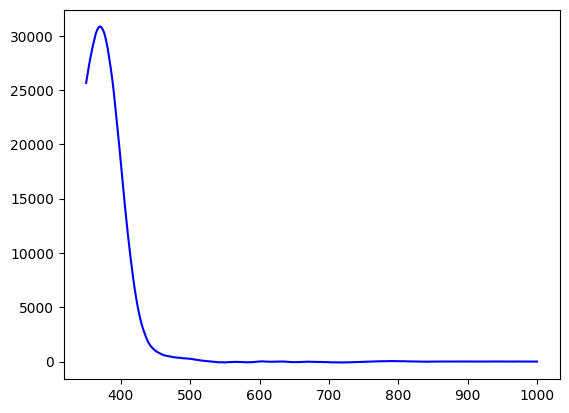

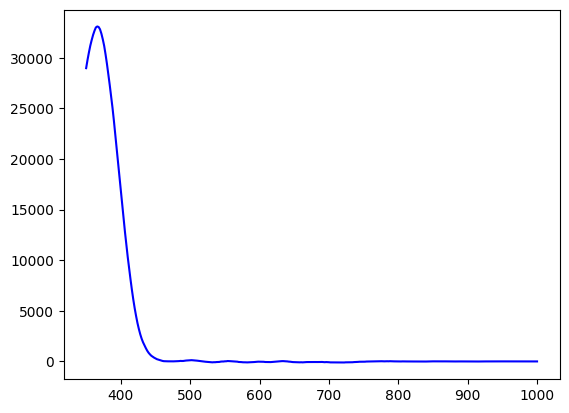

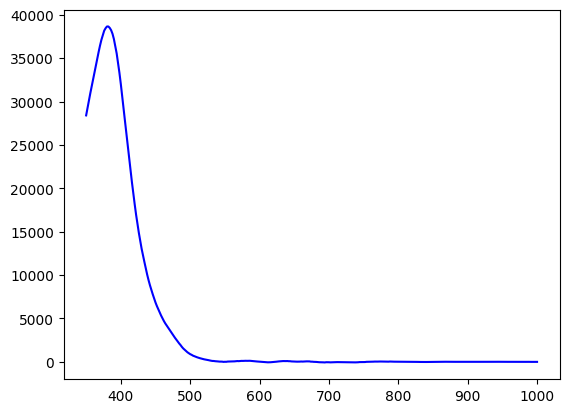

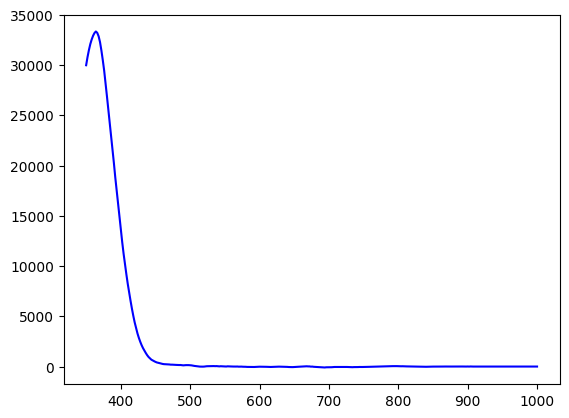

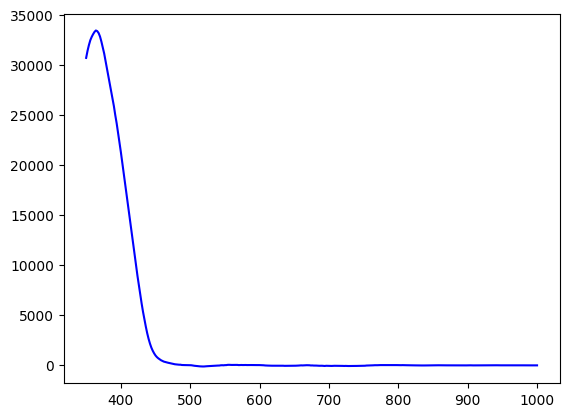

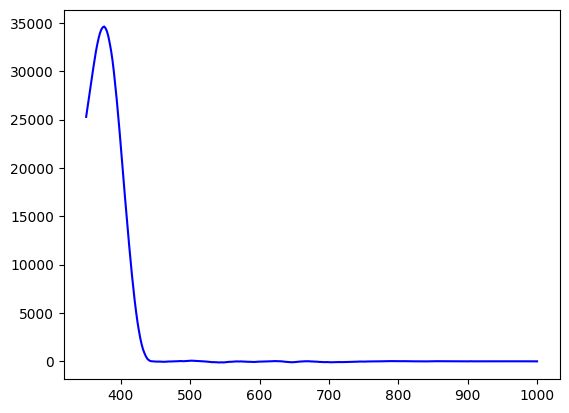

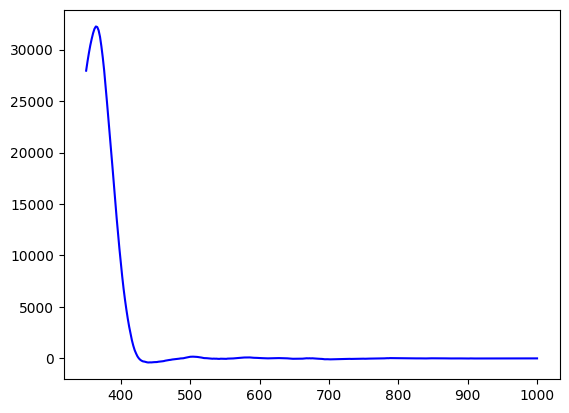

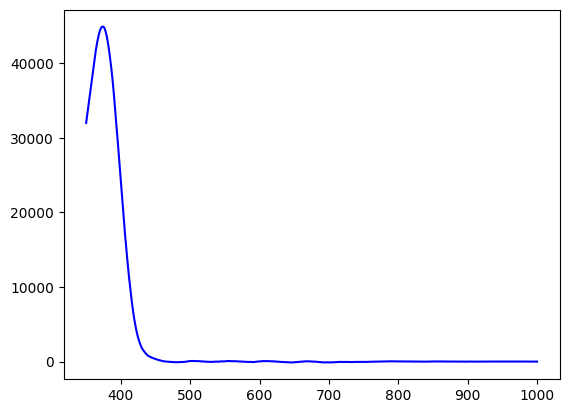

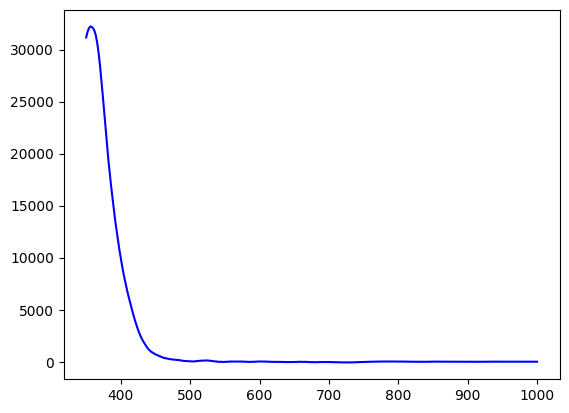

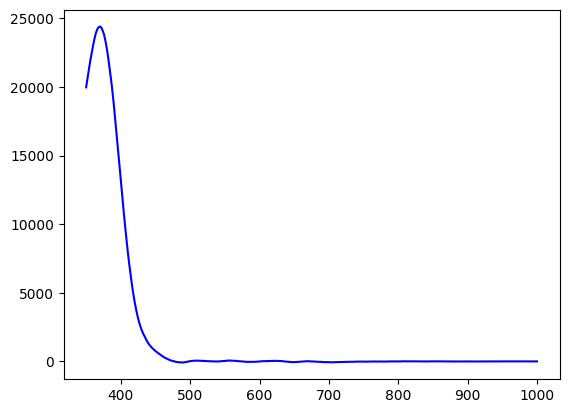

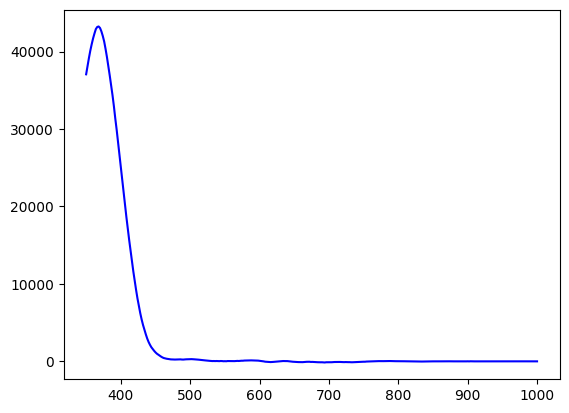

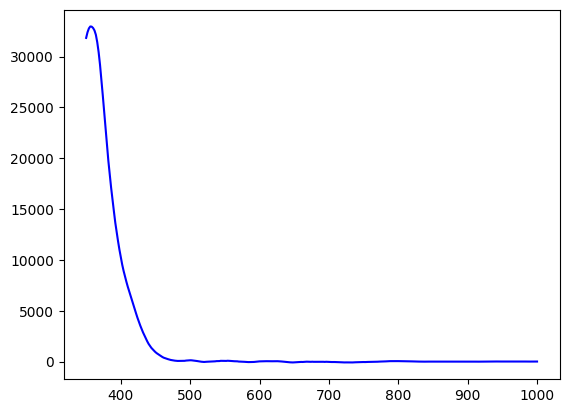

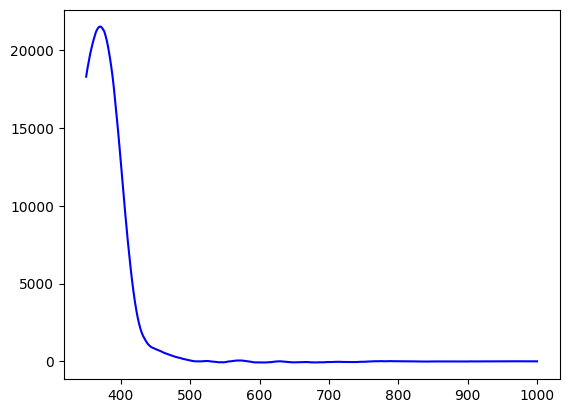

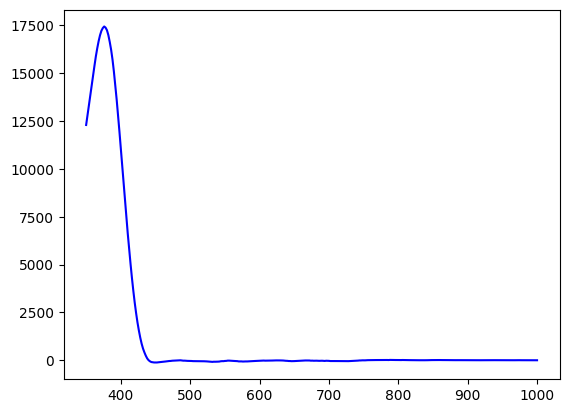

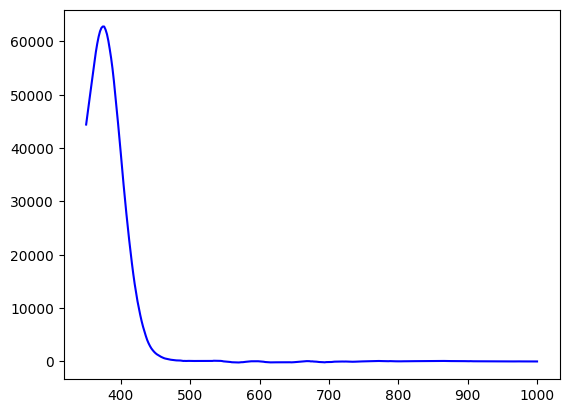

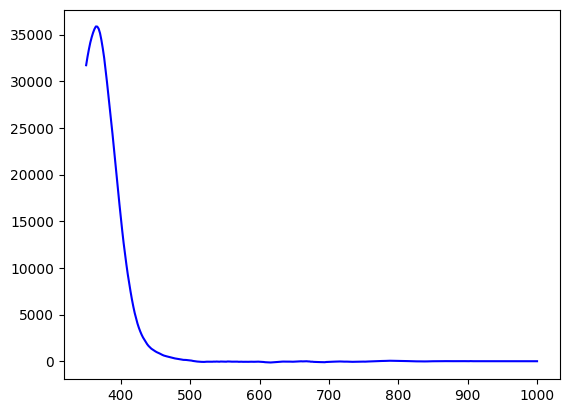

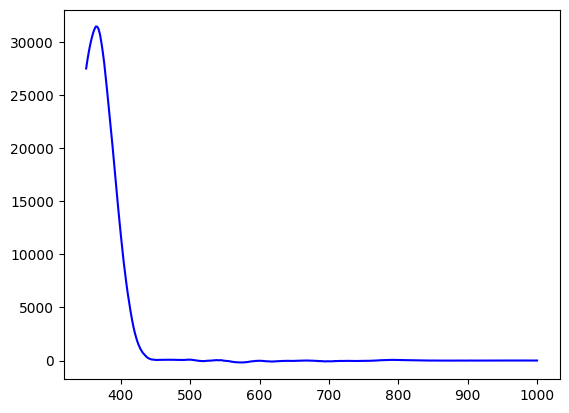

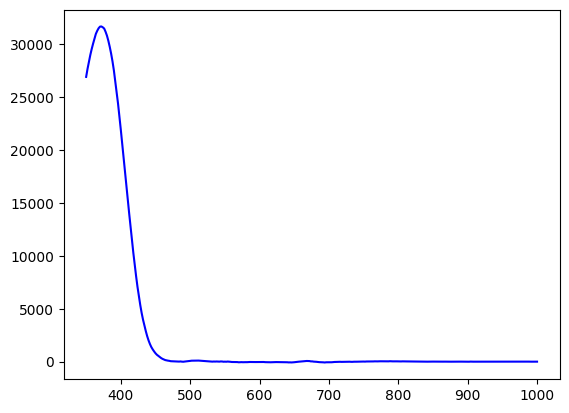

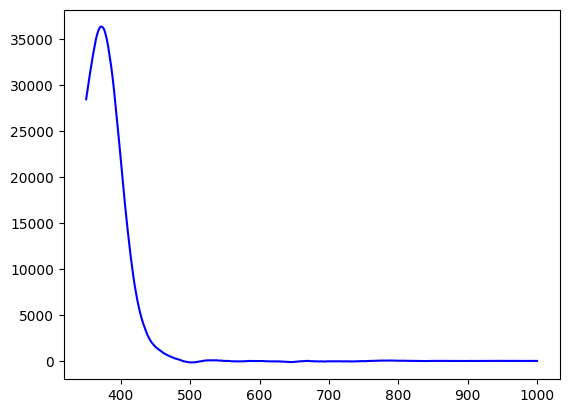

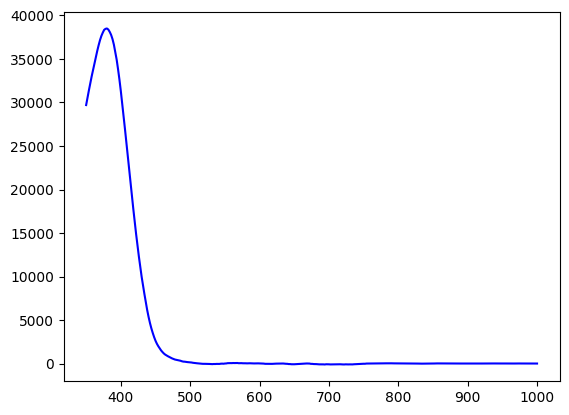

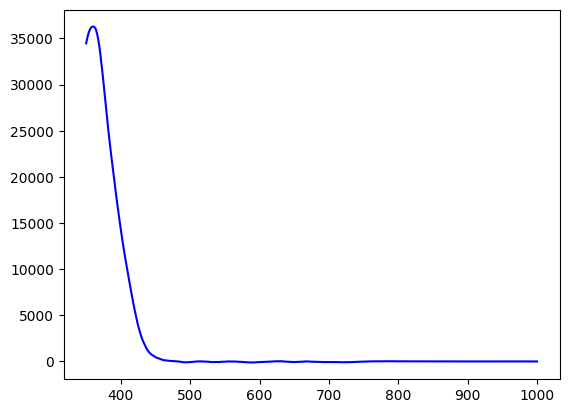

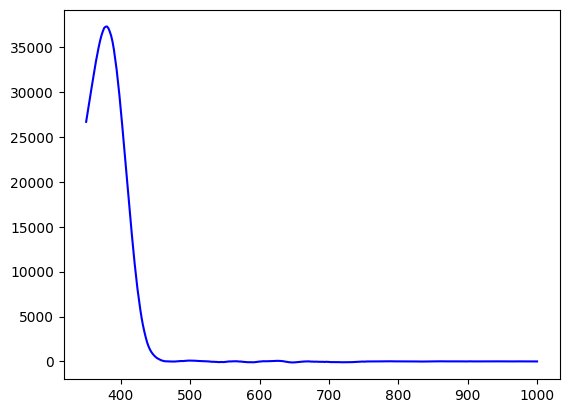

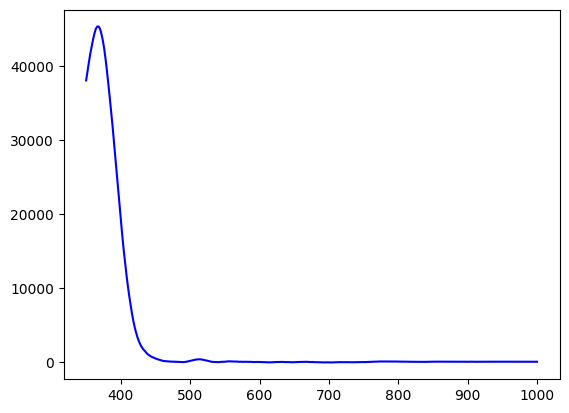

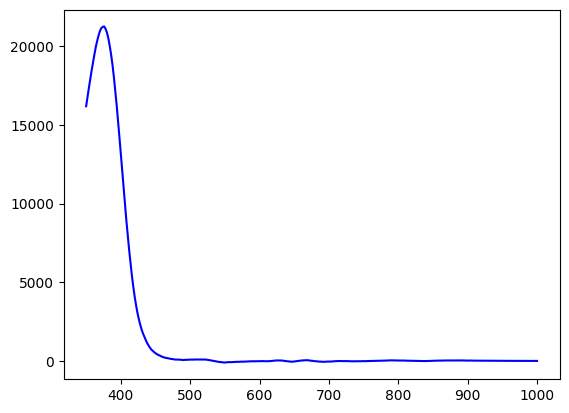

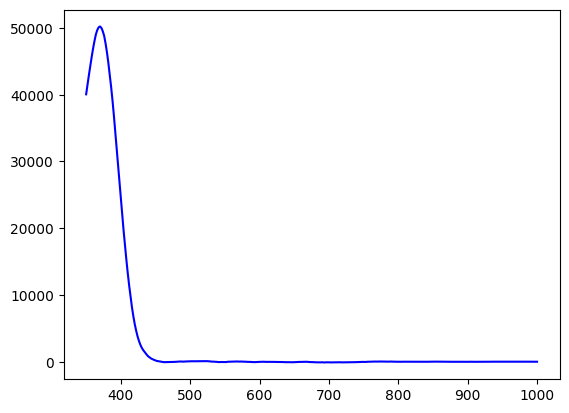

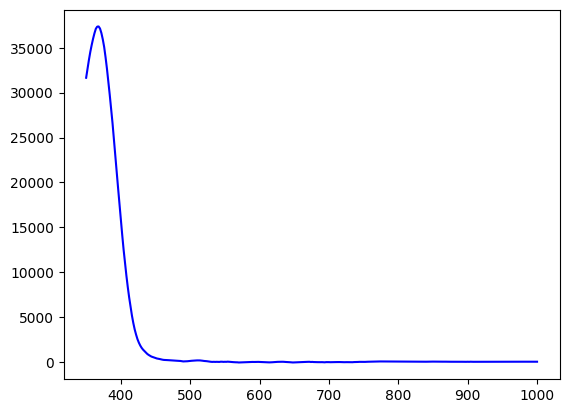

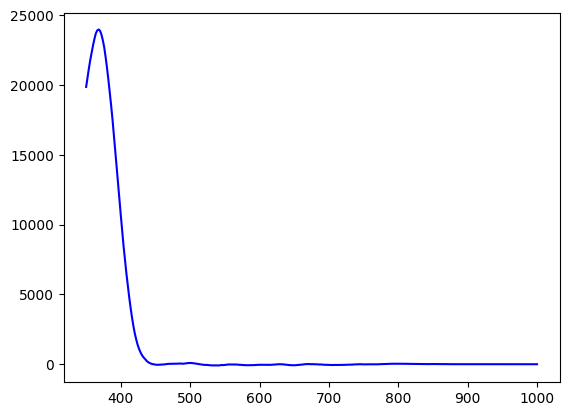

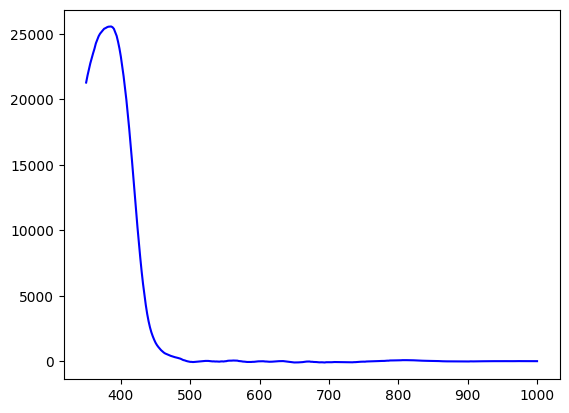

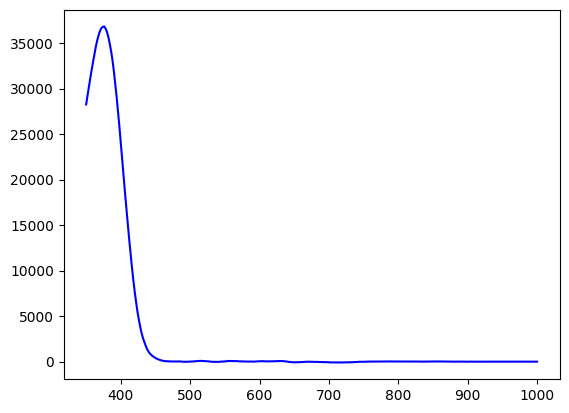

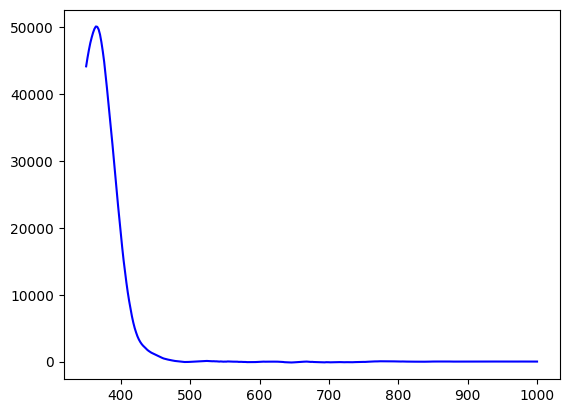

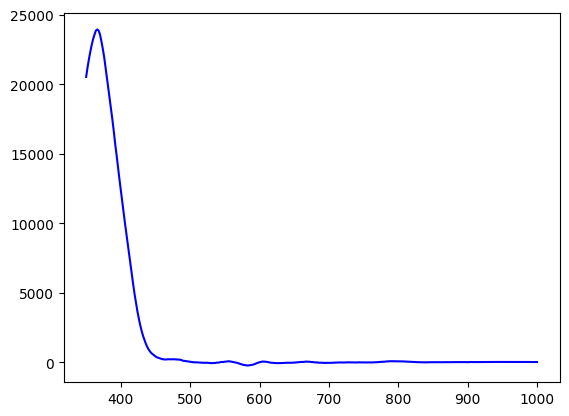

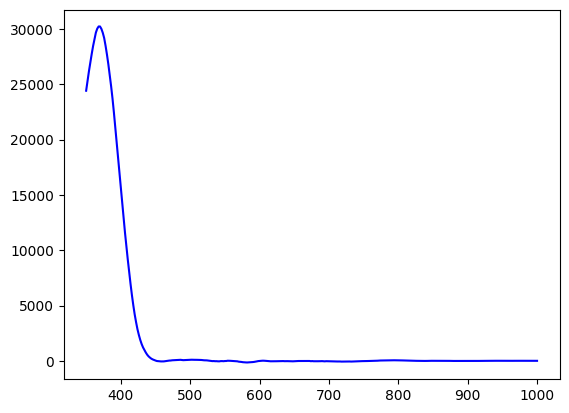

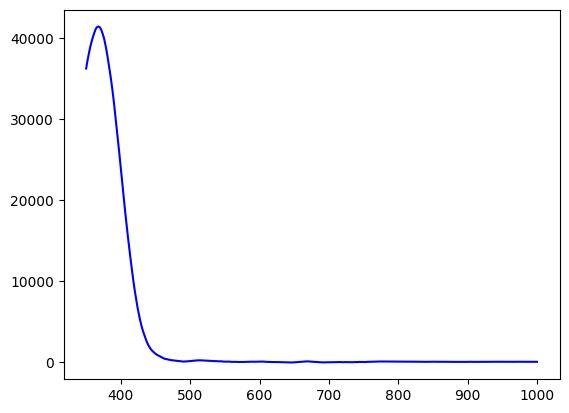

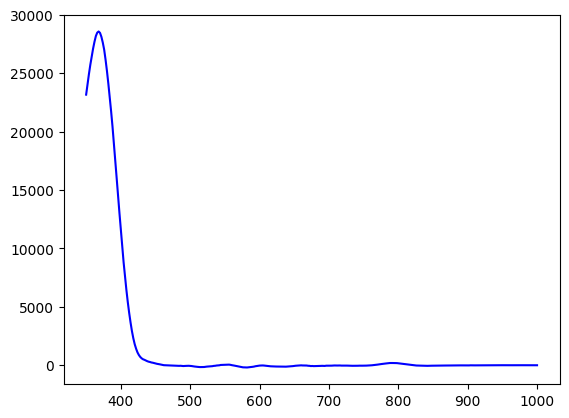

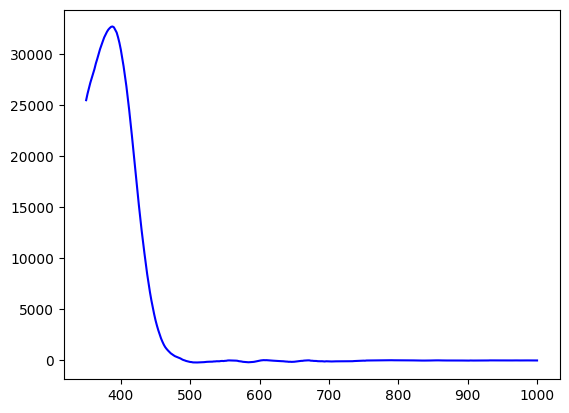

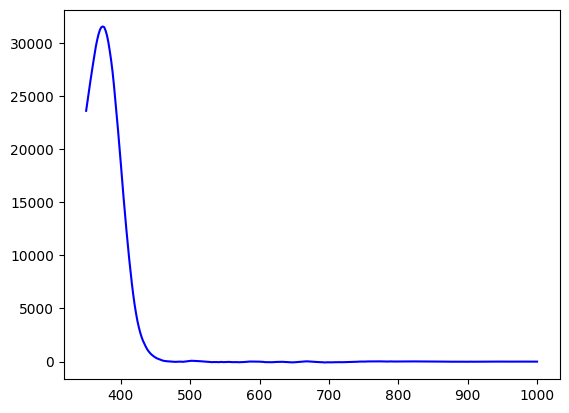

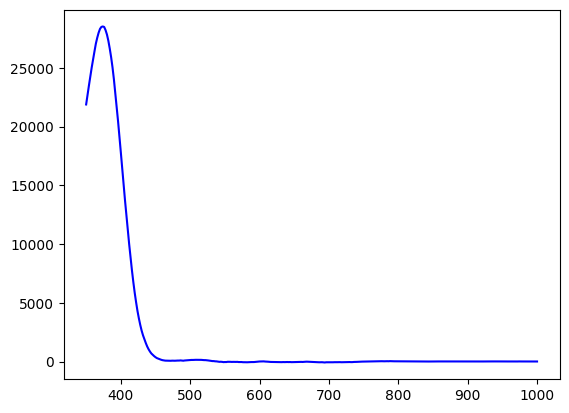

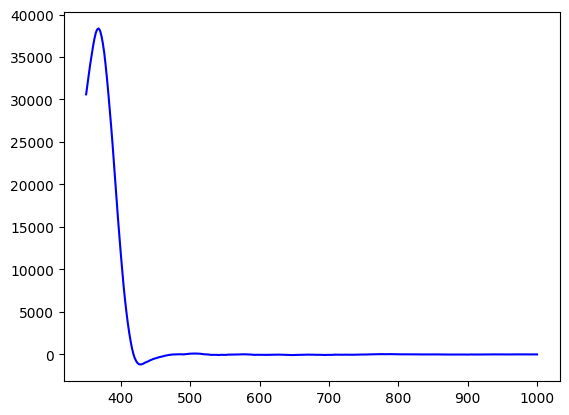

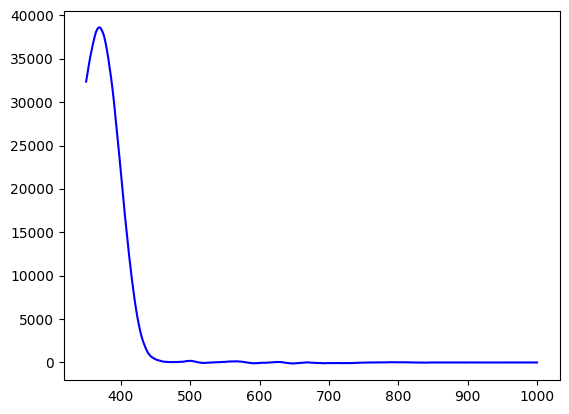

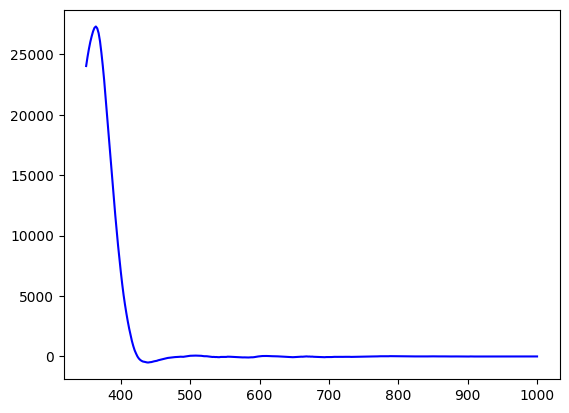

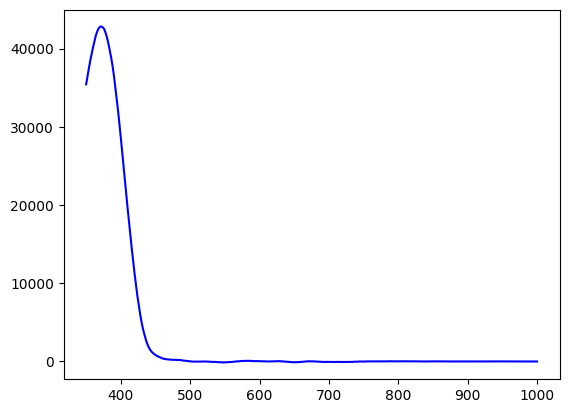

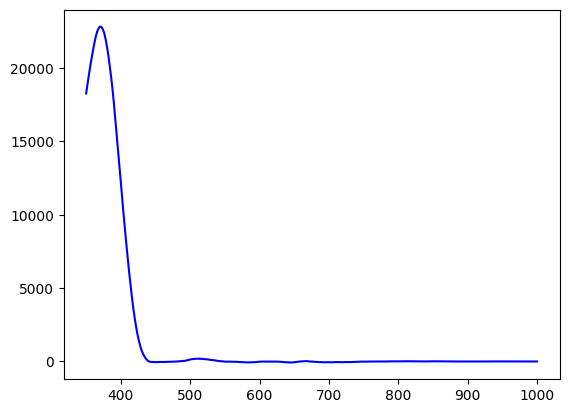

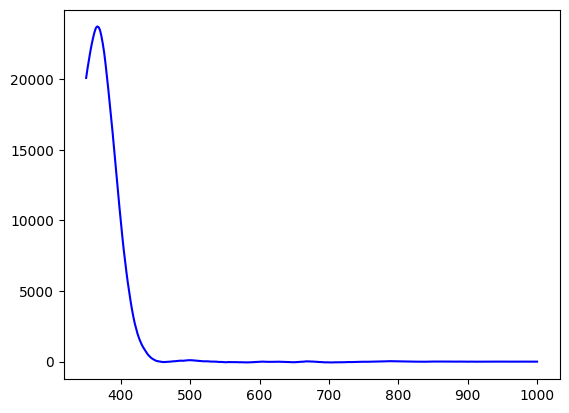

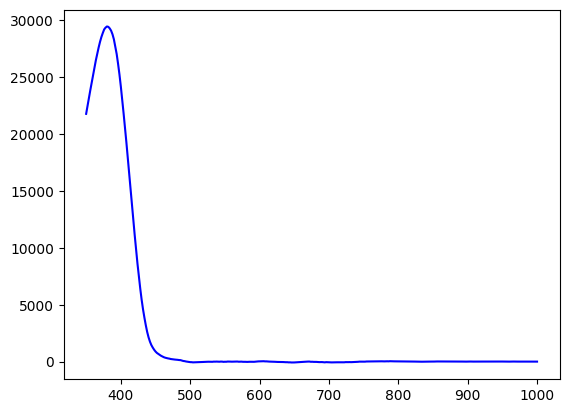

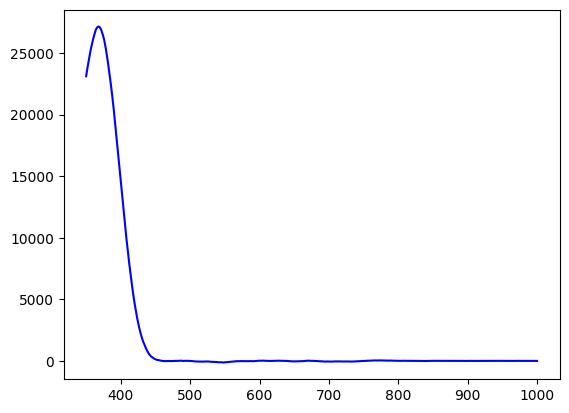

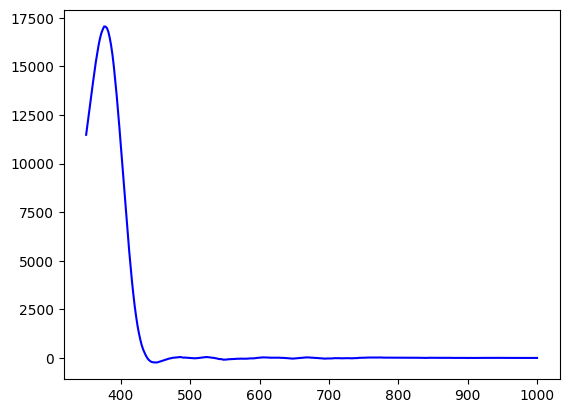

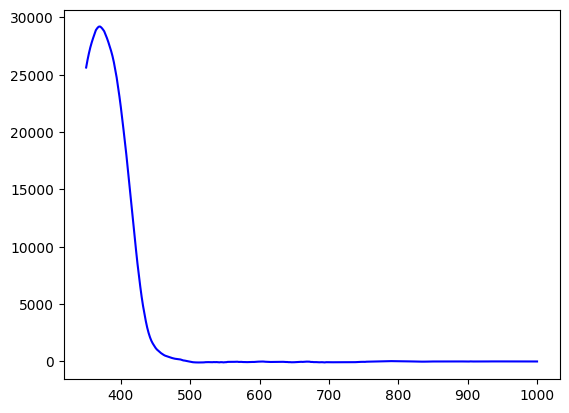

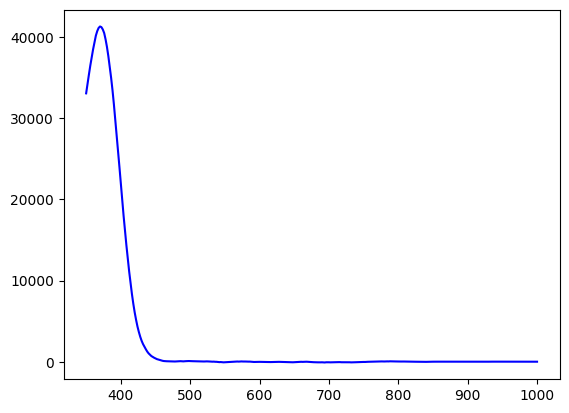

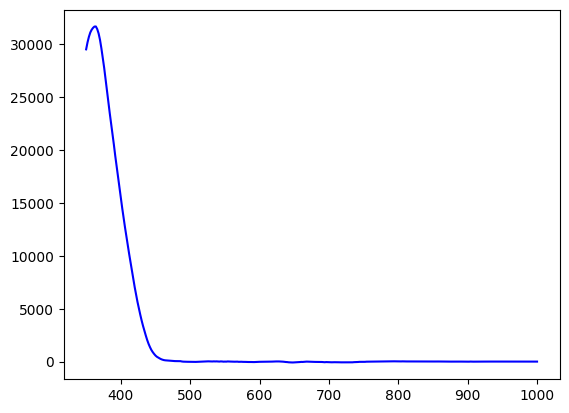

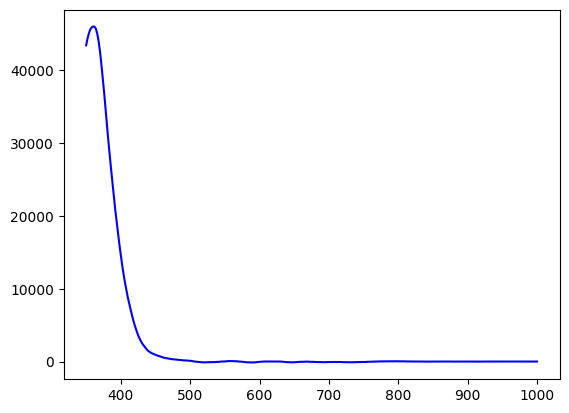

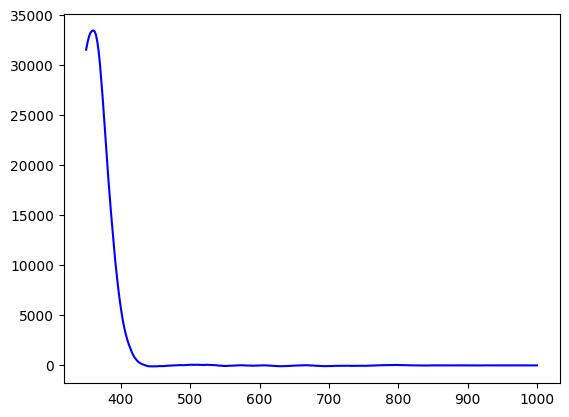

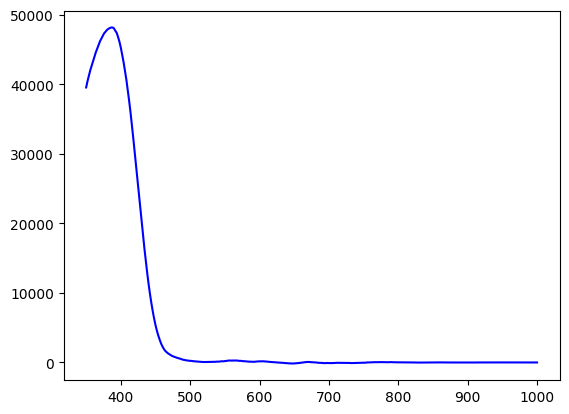

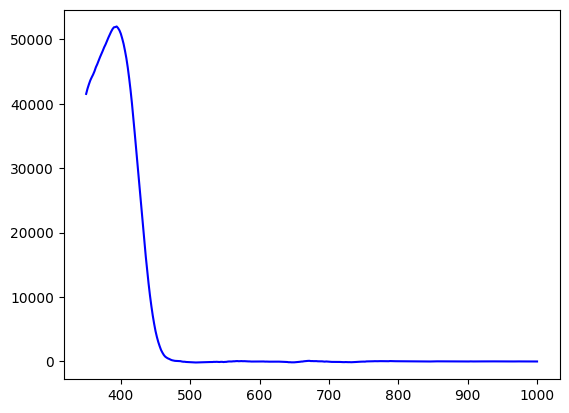

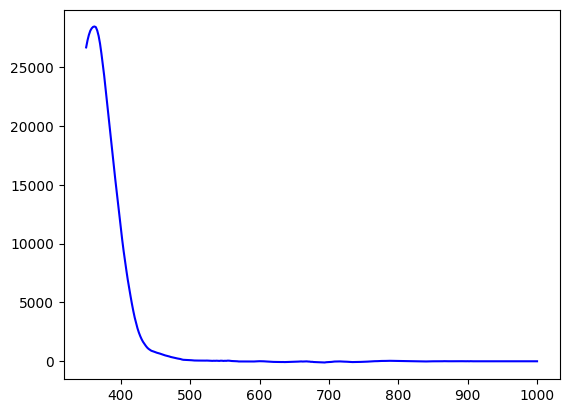

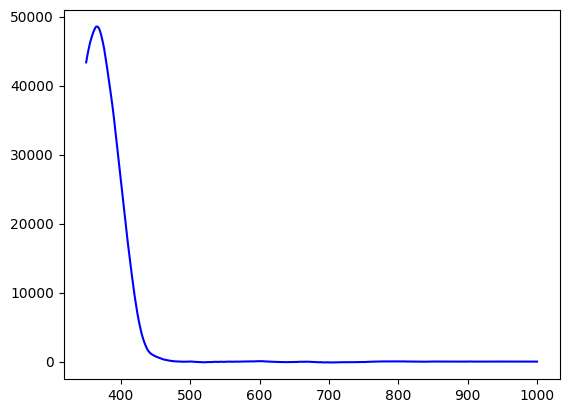

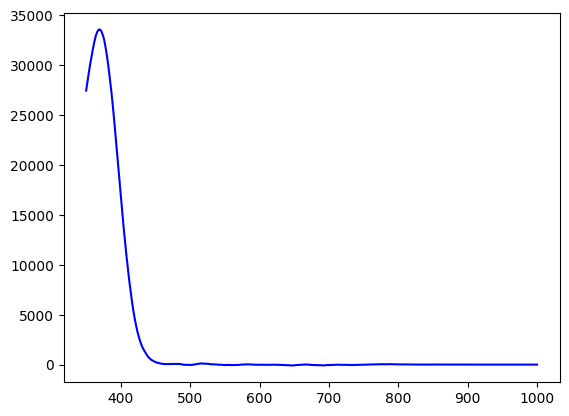

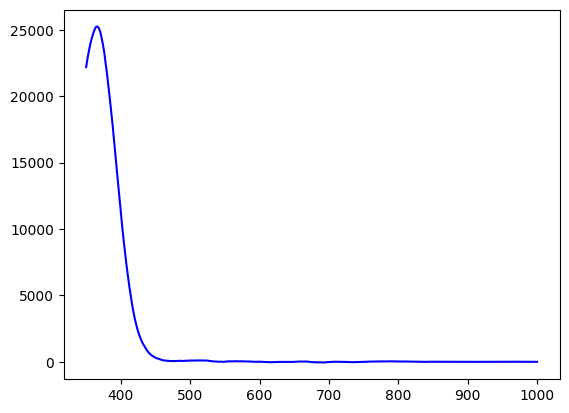

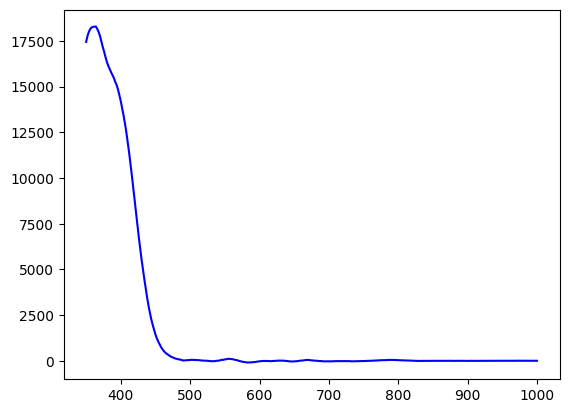

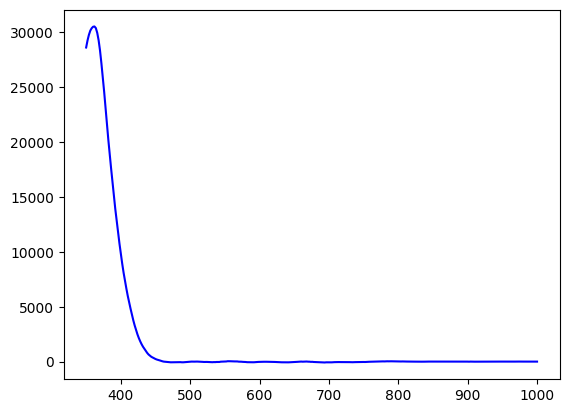

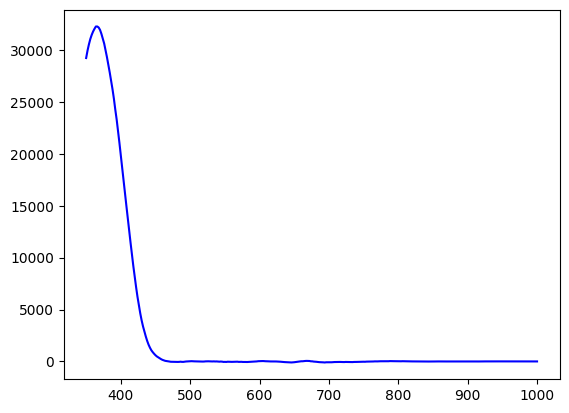

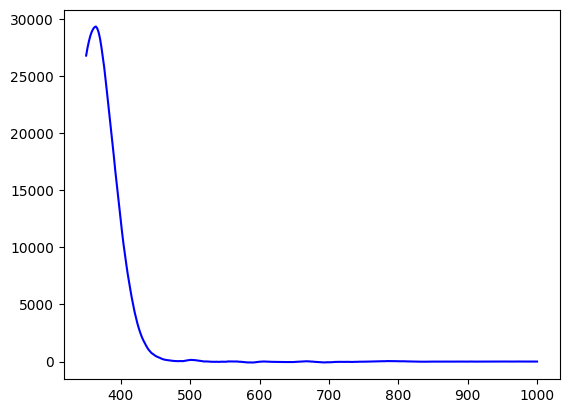

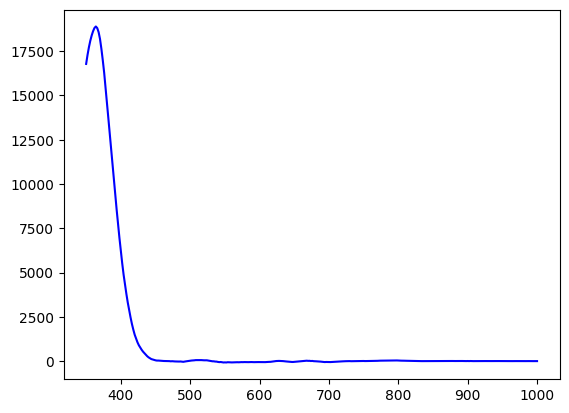

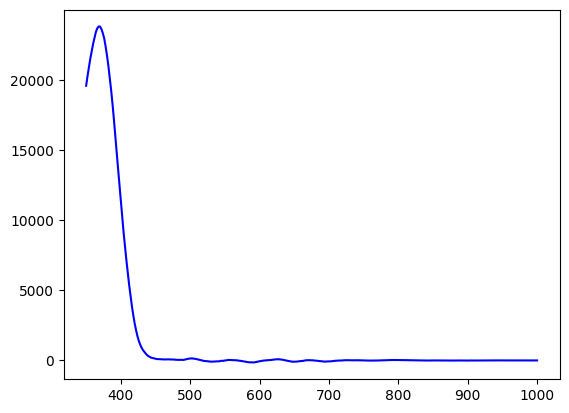

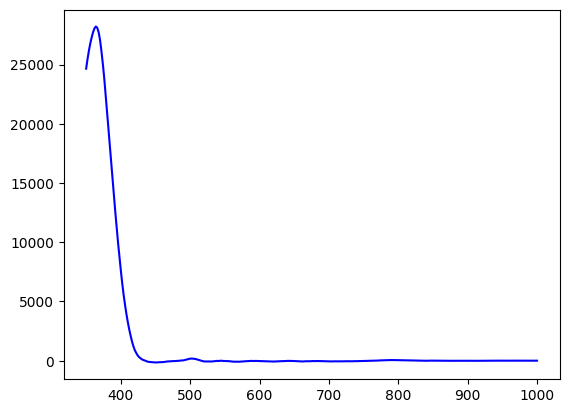

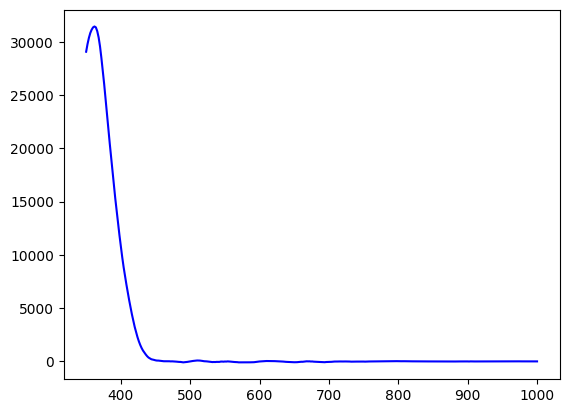

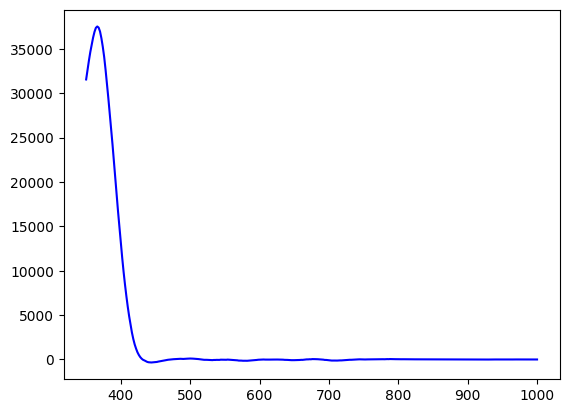

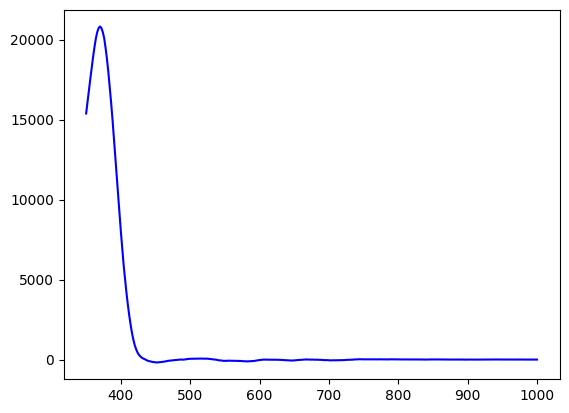

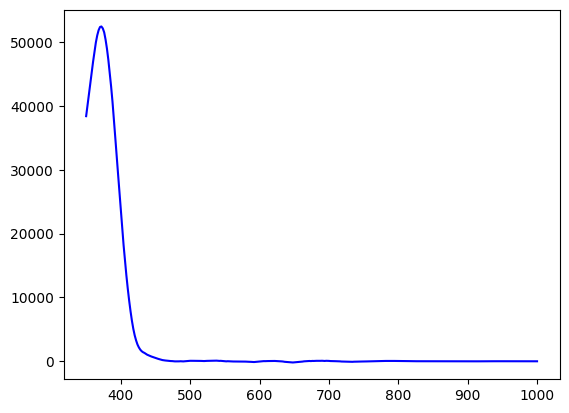

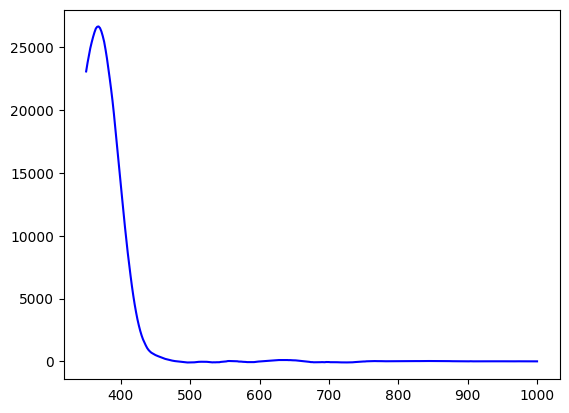

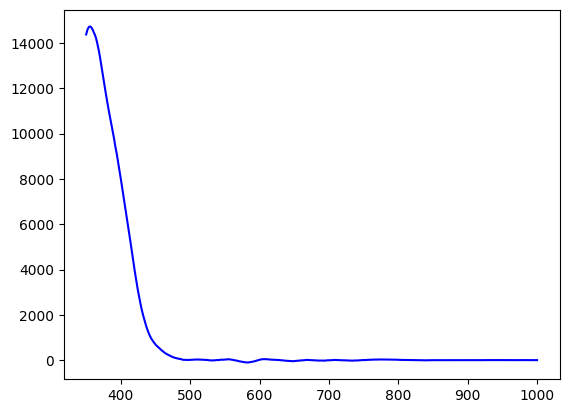

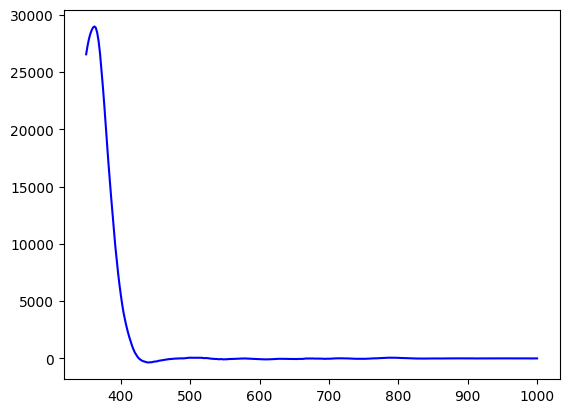

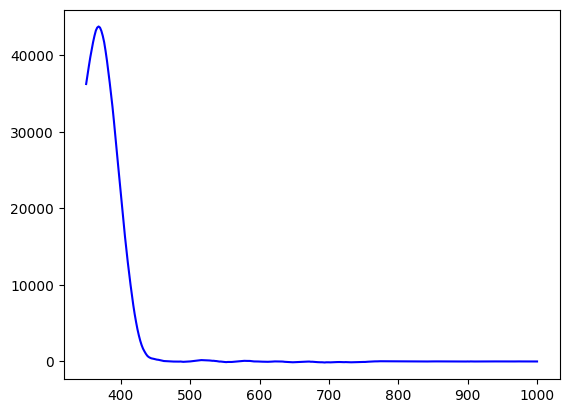

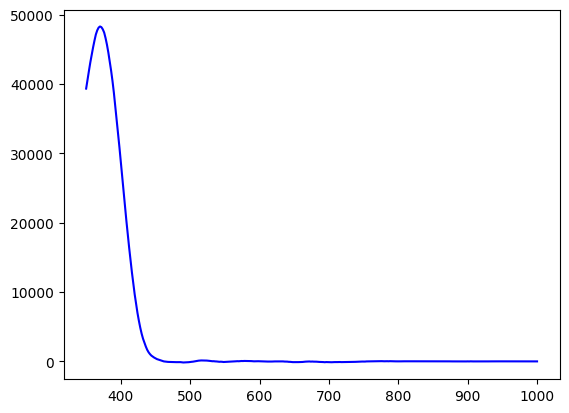

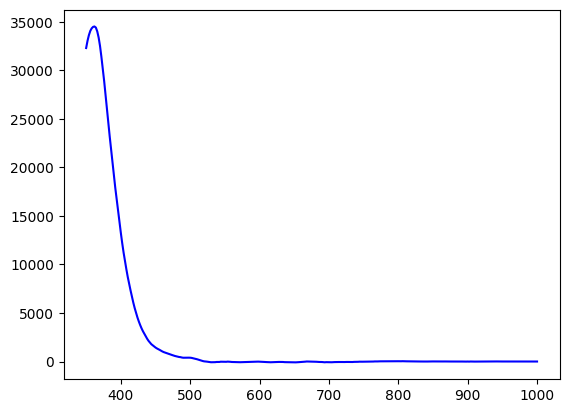

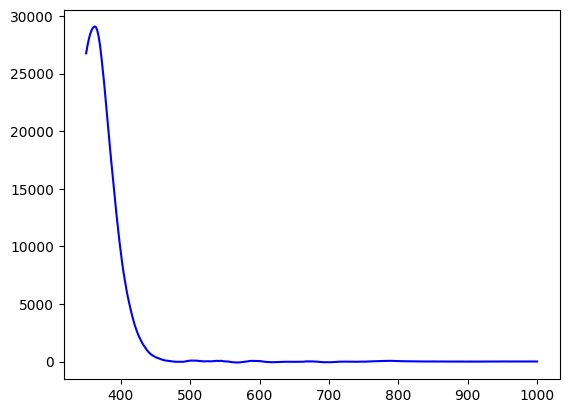

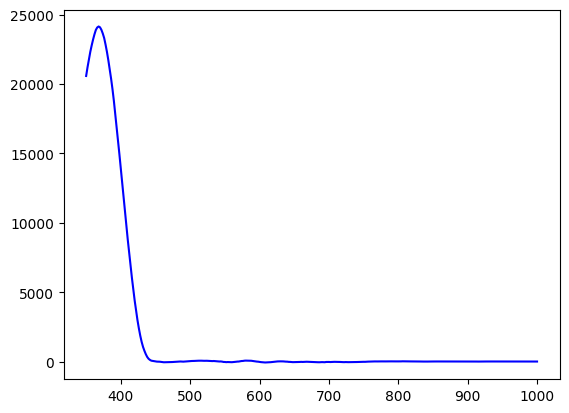

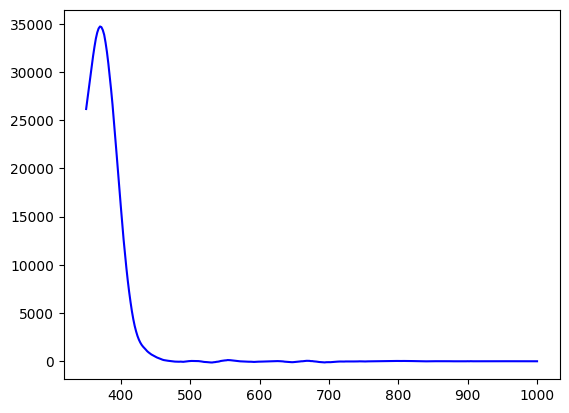

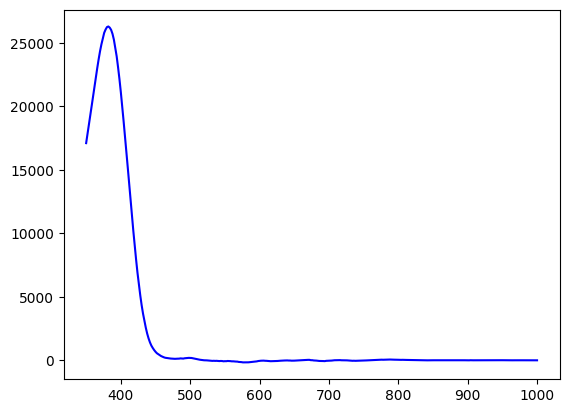

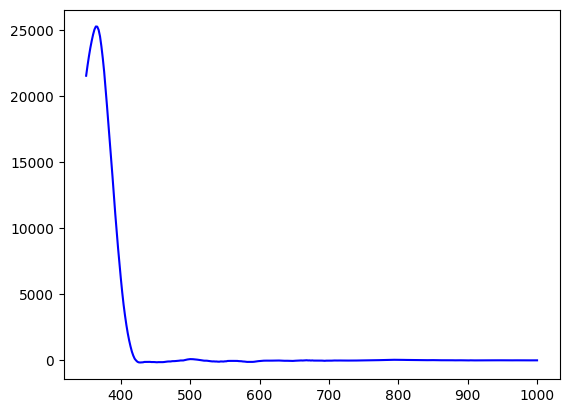

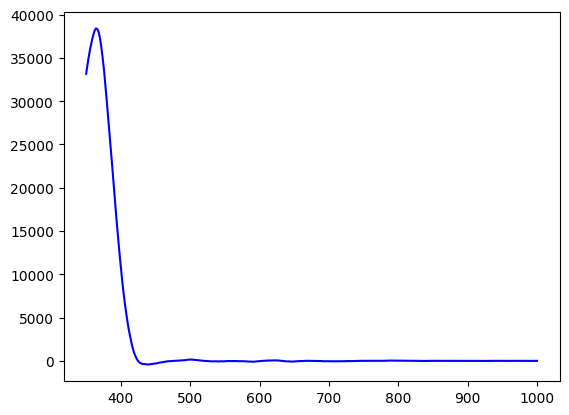

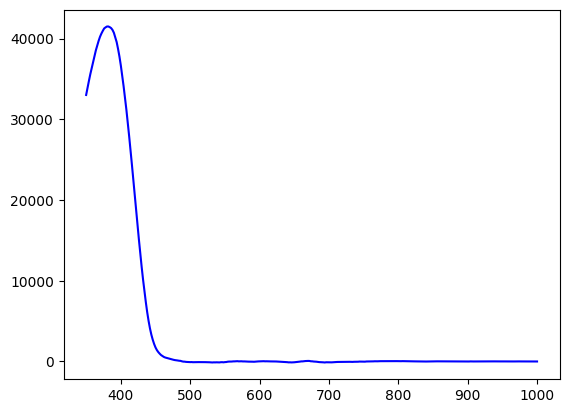

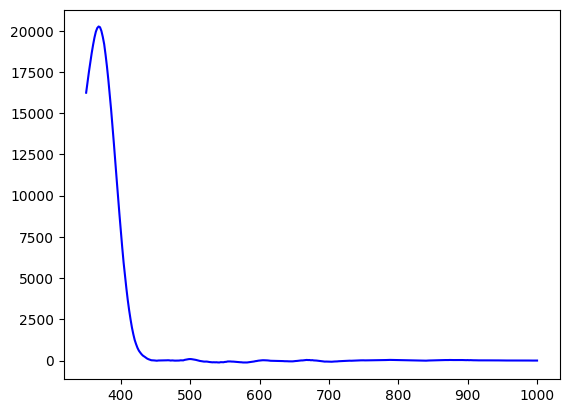

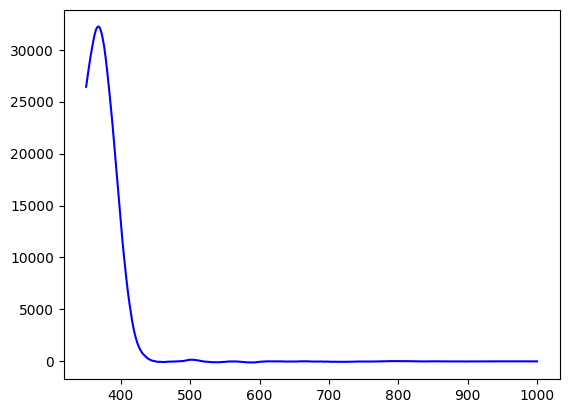

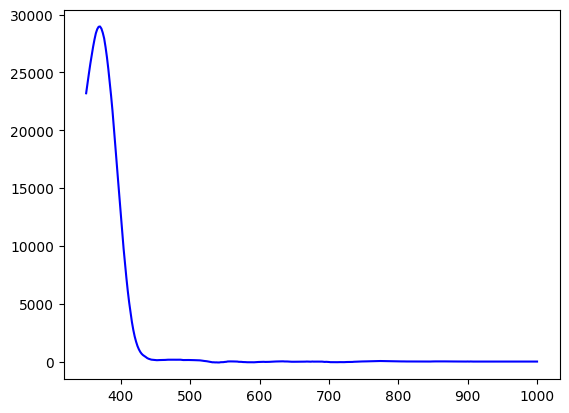

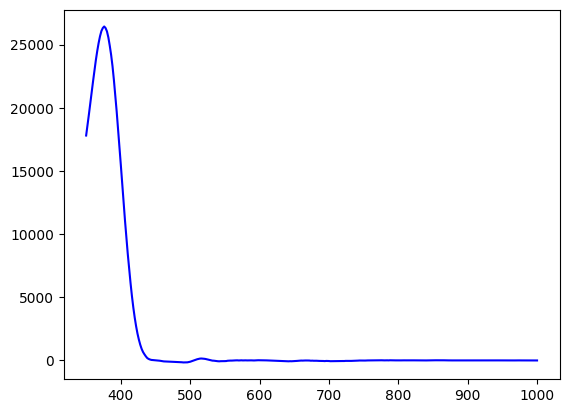

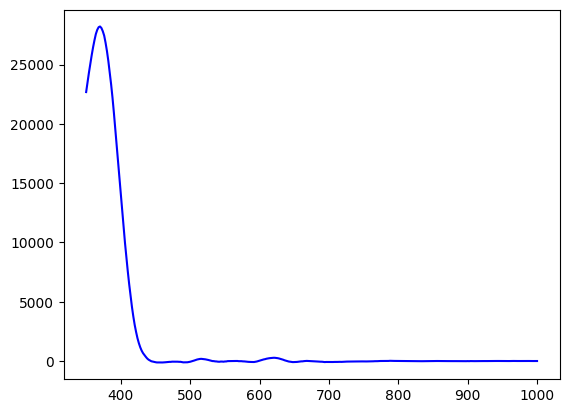

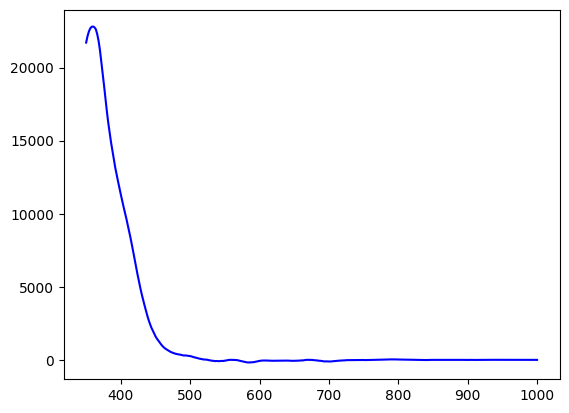

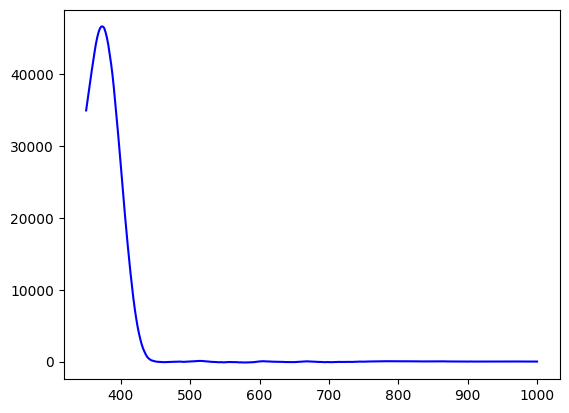

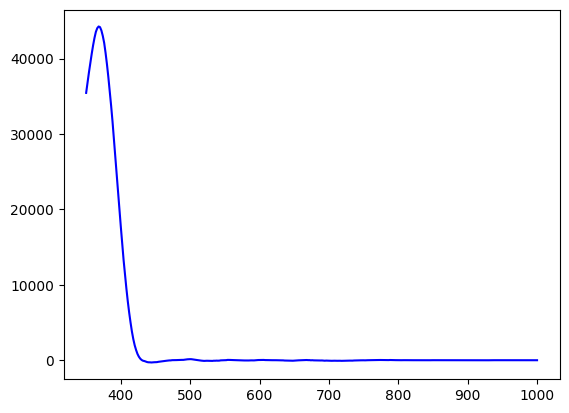

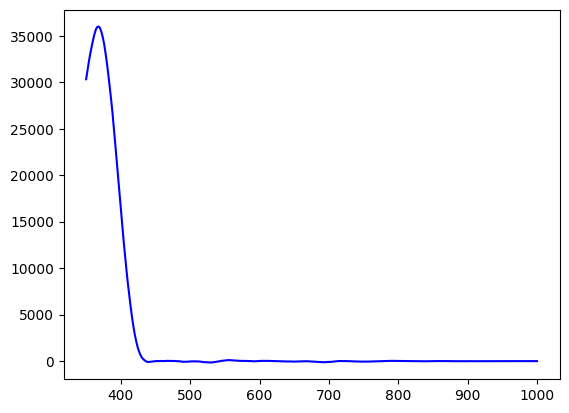

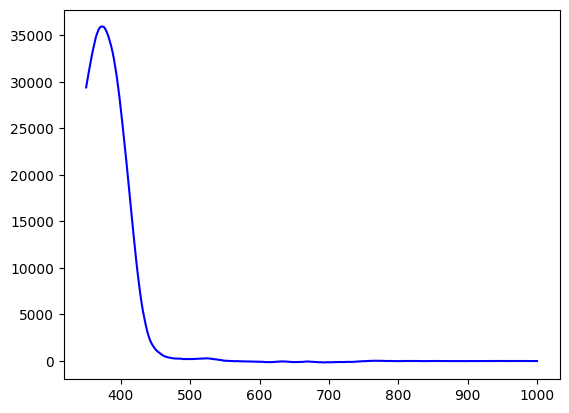

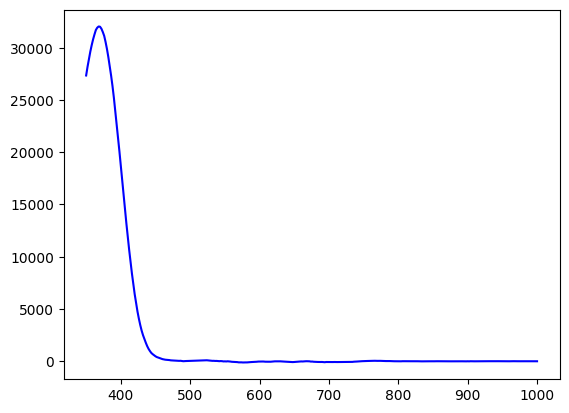

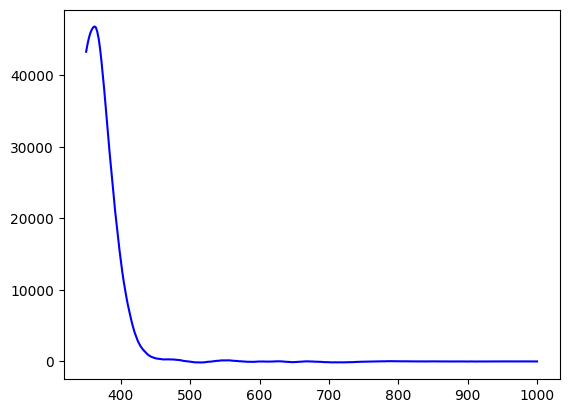

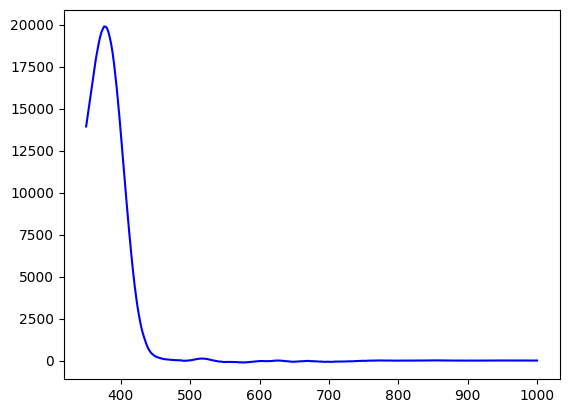

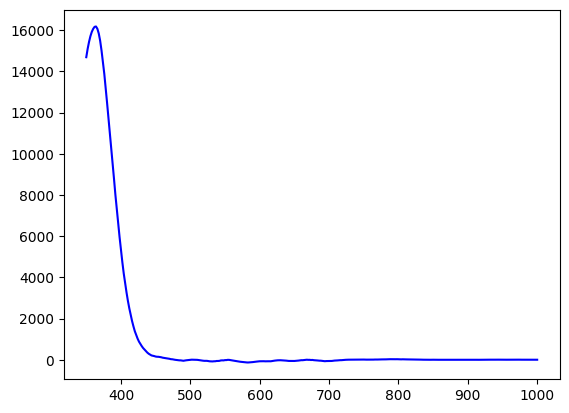

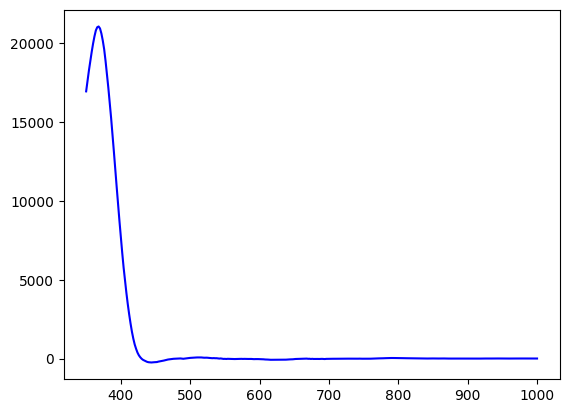

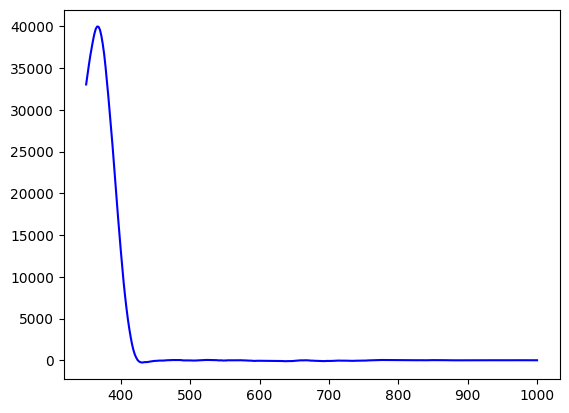

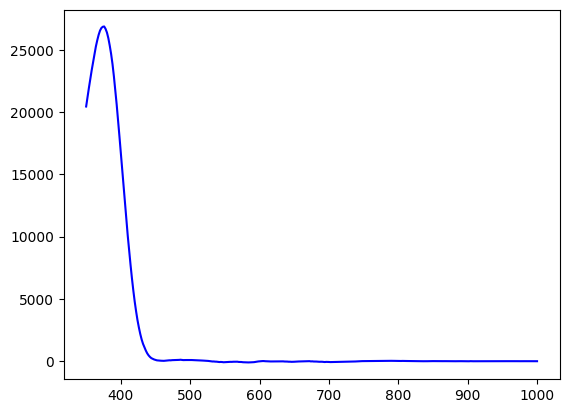

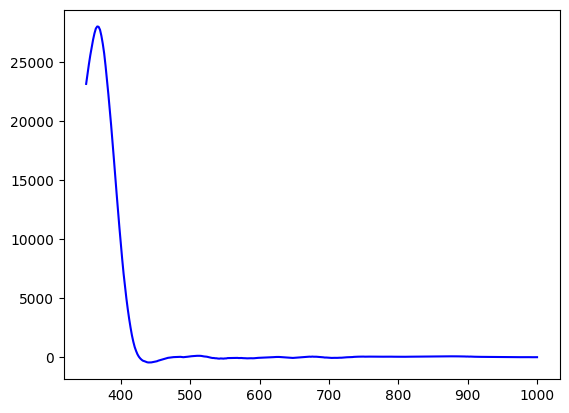

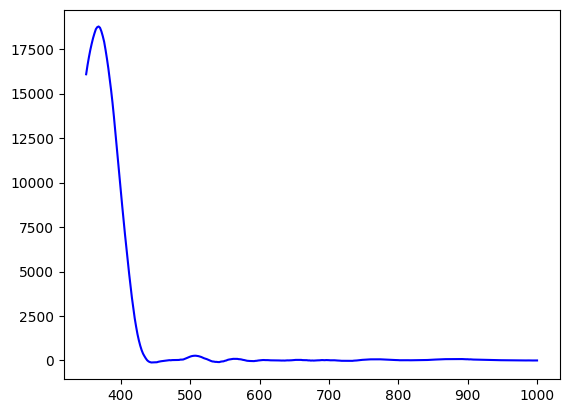

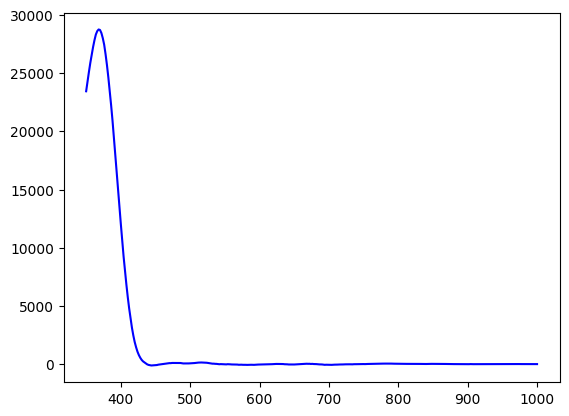

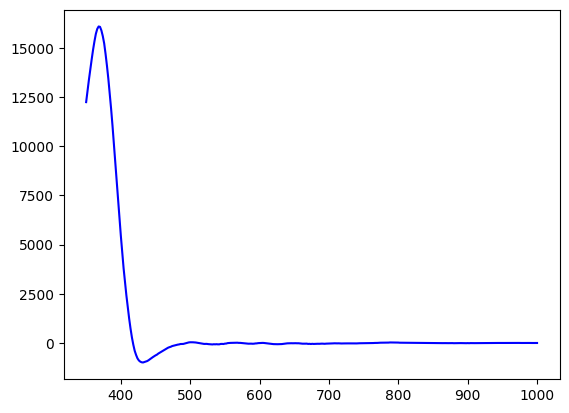

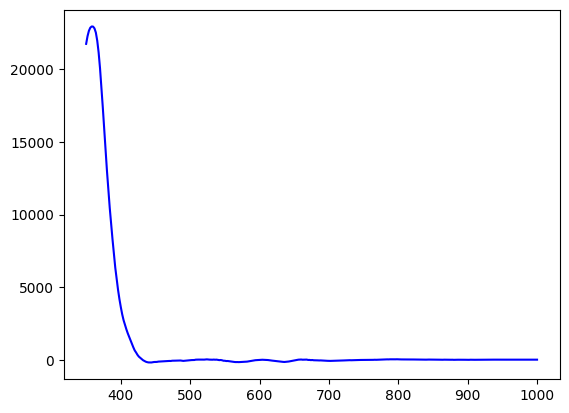

In [68]:
for i in range(len(final_pred_df)):
    
    x = np.linspace(350, 1000, int((1000 - 350) / 2 + 1)) # x축    
    y = final_pred_df.iloc[i, :] # y축

    if i%100 == 0:
    
        plt.plot(x, y, c='b')
        plt.show()

In [44]:
### Evaluation : MAE(Mean Absolute Error) ###

train_mae = []
val_mae = []

train_rmae = []
val_rmae = []

train_sis = []
val_sis = []


def mae(y,pred):        
    non_nan_indices = ~np.isnan(y) & ~np.isnan(pred) # 값 있는 합집합 영역 : boolean      
    return np.mean(np.abs(y[non_nan_indices] - pred[non_nan_indices]))

def rmae(y,pred):
    non_nan_indices = ~np.isnan(y) & ~np.isnan(pred)
    return np.mean((np.abs(y[non_nan_indices] - pred[non_nan_indices]))/(y[non_nan_indices]+1))


def sis(y, pred):

    y = torch.unsqueeze(torch.tensor(y), axis=0)
    pred = torch.unsqueeze(torch.tensor(pred), axis=0)

    
    # normalize the predict spectra : pred  

    nan_mask = torch.isnan(y) # nan MK 생성    
    zero_sub=torch.zeros_like(y) # zero MK 생성    
    threshold = 1e-8    

    pred[pred < threshold] = threshold
    
    sum_pred = torch.sum(torch.where(nan_mask, zero_sub, pred),axis=1) # nan 있는 위치 0으로 대체하고 (sum 할땐 0)
    sum_pred = torch.unsqueeze(sum_pred, axis=1)
    pred = torch.div(pred, sum_pred)

    
    # normalize the target spectra : y
    
    y[y < threshold] = threshold # 음수와 0값은 1e-8 로 대체함 (뒤에 log 계산 위하여)
    
    sum_y = torch.sum(torch.where(nan_mask, zero_sub, y),axis=1) # nan 있는 위치 0으로 대체하고 (sum 할땐 0)
    sum_y = torch.unsqueeze(sum_y, axis=1) # 차원 맞춘다음
    y = torch.div(y, sum_y) # zero to sum normilization
    
    
    # calculate loss value   
   
    loss = torch.ones_like(y)
    
    y[nan_mask] = 1
    pred[nan_mask] = 1 # nan 있는 위치 1으로 대체하고 (log 계산할땐 1)
    
    loss = torch.mul(torch.log(torch.div(pred,y)),pred) + torch.mul(torch.log(torch.div(y,pred)),y)
    
    loss[nan_mask]=0
    loss = torch.sum(loss,axis=1)

    sim = 1/(loss+1) # 이거 하나 추가해봄
    
    return sim


for i in range(train_y.shape[0]): # data 개수
    train_mae.append(mae(train_y[i],train_pred[i]))
    train_rmae.append(rmae(train_y[i], train_pred[i]))
    train_sis.append(sis(train_y[i], train_pred[i]))
  
for i in range(val_y.shape[0]):
    val_mae.append(mae(val_y[i],val_pred[i]))
    val_rmae.append(rmae(val_y[i], val_pred[i]))
    val_sis.append(sis(val_y[i], val_pred[i]))


print("Train의 MAE 값 :", np.mean(train_mae))
print("Val의 MAE 값 :", np.mean(val_mae))
print()
print("Train의 Relative MAE값 :", np.mean(train_rmae))
print("Val의 Relative MAE값 :", np.mean(val_rmae))
print()
print("Train의 SIS 값 :", round(np.mean(train_sis), 4))
print("Val의 SIS 값 :", round(np.mean(val_sis), 4))

Train의 MAE 값 : 1057.797
Val의 MAE 값 : 3775.8574

Train의 Relative MAE값 : 26.398994
Val의 Relative MAE값 : 99.74212

Train의 SIS 값 : 0.9147
Val의 SIS 값 : 0.7069


index: 1416
wl_skew: 80
y_skew: 1.6659586061177754
SIS: tensor([0.0432], dtype=torch.float64)


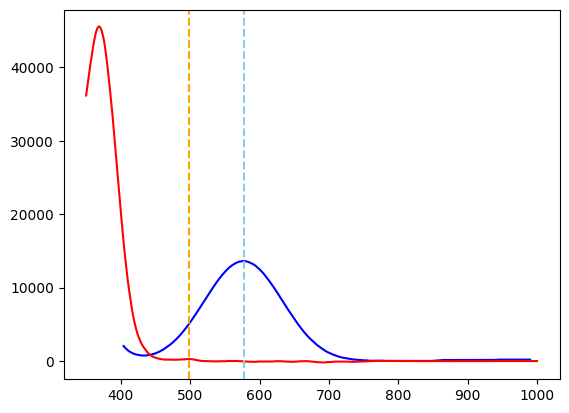

80.0
1.666


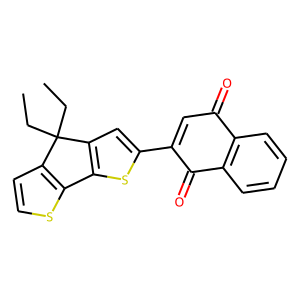

In [45]:
### Chloroform 일때 비교 ###

from rdkit import Chem
from rdkit.Chem import Draw

OPD_application_Final = pd.read_csv('transferlearning_weight/OPD_application_Final.csv')

start_wl = 350

x_max_skew_test = []
y_max_skew_test = []


i_y_spec = OPD_application_Final.iloc[0, 3:].to_numpy() # spectrum 뽑고
i_y_spec_numeric = pd.to_numeric(i_y_spec, errors='coerce')
i_pred_spec = final_pred[0]

nan_mask = np.isnan(i_y_spec_numeric) # target spectrum 으로 : nan MK 생성    
zero_sub = np.zeros_like(i_y_spec_numeric) # zero MK 생성  

i_y_spec_mask = np.where(nan_mask, zero_sub, i_y_spec_numeric) # nan 있는 위치 0으로 대체하고 : y
i_pred_spec_mask = np.where(nan_mask, zero_sub, i_pred_spec) # nan 있는 위치 0으로 대체하고 : pred

i_y_max_idx = start_wl + (np.nanargmax(i_y_spec_mask)*2) # y max 파장 뽑고 
i_y_max_value = np.nanmax(i_y_spec_mask) # y max 값도 뽑음

lower_bound = max(0, (i_y_max_idx - 100 - start_wl) // 2) # y 기준 pred 를 범위(+/- 70) 내에서 검색
upper_bound = min(i_pred_spec_mask.size, (i_y_max_idx + 100 - start_wl) // 2 + 1)

i_pred_max_local_idx = np.nanargmax(i_pred_spec_mask[lower_bound:upper_bound]) # i_pred_spec_mask의 해당 범위 내에서 인덱스 찾기
i_pred_max_idx = start_wl + ((lower_bound + i_pred_max_local_idx) * 2) # 실제 y_pred max 파장으로 변환
i_pred_max_value = np.nanmax(i_pred_spec_mask[lower_bound:upper_bound]) # y_pred 최대값
    
# if (i_y_max_idx > start_wl + 100): # window(500nm 부터) 안에 있으면 
    
X = np.linspace(start_wl, 1000, int((1000 - start_wl) / 2 + 1)) # x축

y = i_y_spec # y축
y_pred = i_pred_spec # y_pred 축

print('index:', i)     
print('wl_skew:', np.abs(i_y_max_idx - i_pred_max_idx))
print('y_skew:', np.abs(np.log10(i_y_max_value) - np.log10(i_pred_max_value)))
print('SIS:', sis(i_y_spec_numeric, i_pred_spec))

plt.plot(X, y, c='b')
plt.plot(X, y_pred, c='r')

plt.axvline(x = i_y_max_idx, color='skyblue', linestyle='--', linewidth=1.5, label='y_max')
plt.axvline(x = i_pred_max_idx, color='orange', linestyle='--', linewidth=1.5, label='pred_max')

plt.show()

x_max_skew_test.append(np.square(i_y_max_idx - i_pred_max_idx))
y_max_skew_test.append(np.square(np.log10(i_y_max_value) - np.log10(i_pred_max_value)))


print(round(np.sqrt(np.mean(x_max_skew_test)), 3))
print(round(np.sqrt(np.mean(y_max_skew_test)), 3))

chr = Chem.MolFromSmiles(OPD_application_Final.iloc[0,0])
sol = Chem.MolFromSmiles(OPD_application_Final.iloc[0,1])
Draw.MolToImage(chr)

wl_skew: 80
y_skew: 1.6659586061177754
SIS: tensor([0.0432], dtype=torch.float64)


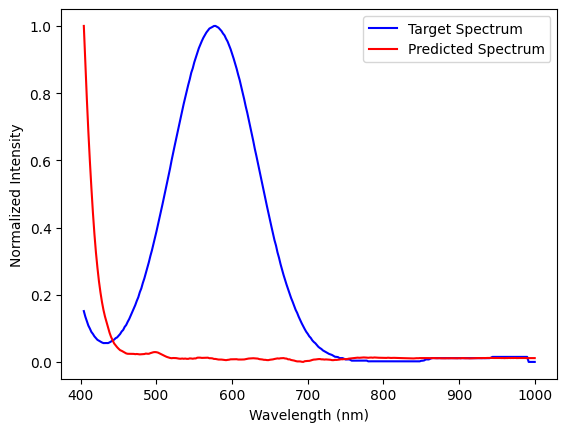

80.0
1.666


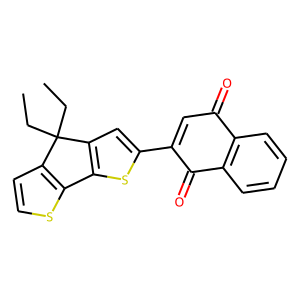

In [46]:
from rdkit import Chem
from rdkit.Chem import Draw
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 파일 읽기
OPD_application_Final = pd.read_csv('transferlearning_weight/OPD_application_Final.csv')

start_wl = 350

x_max_skew_test = []
y_max_skew_test = []

# 스펙트럼 데이터
i_y_spec = OPD_application_Final.iloc[0, 3:].to_numpy()  # spectrum 뽑고
i_y_spec_numeric = pd.to_numeric(i_y_spec, errors='coerce')
i_pred_spec = final_pred[0]

nan_mask = np.isnan(i_y_spec_numeric)  # target spectrum 으로 : nan MK 생성    
zero_sub = np.zeros_like(i_y_spec_numeric)  # zero MK 생성  

i_y_spec_mask = np.where(nan_mask, zero_sub, i_y_spec_numeric)  # nan 있는 위치 0으로 대체하고 : y
i_pred_spec_mask = np.where(nan_mask, zero_sub, i_pred_spec)  # nan 있는 위치 0으로 대체하고 : pred

# 400 nm 이상만 선택
valid_indices = np.where(np.linspace(start_wl, 1000, int((1000 - start_wl) / 2 + 1)) >= 403)[0]
i_y_spec_mask = i_y_spec_mask[valid_indices]
i_pred_spec_mask = i_pred_spec_mask[valid_indices]

# 정규화 과정
i_y_spec_normalized = (i_y_spec_mask - np.min(i_y_spec_mask)) / (np.max(i_y_spec_mask) - np.min(i_y_spec_mask))
i_pred_spec_normalized = (i_pred_spec_mask - np.min(i_pred_spec_mask)) / (np.max(i_pred_spec_mask) - np.min(i_pred_spec_mask))

# 최대값 위치 찾기
i_y_max_idx = start_wl + (np.nanargmax(i_y_spec_mask) * 2)  # y max 파장 뽑고 
i_y_max_value = np.nanmax(i_y_spec_mask)  # y max 값도 뽑음

lower_bound = max(0, (i_y_max_idx - 100 - start_wl) // 2)  # y 기준 pred 를 범위(+/- 100) 내에서 검색
upper_bound = min(i_pred_spec_mask.size, (i_y_max_idx + 100 - start_wl) // 2 + 1)

i_pred_max_local_idx = np.nanargmax(i_pred_spec_mask[lower_bound:upper_bound])  # i_pred_spec_mask의 해당 범위 내에서 인덱스 찾기
i_pred_max_idx = start_wl + ((lower_bound + i_pred_max_local_idx) * 2)  # 실제 y_pred max 파장으로 변환
i_pred_max_value = np.nanmax(i_pred_spec_mask[lower_bound:upper_bound])  # y_pred 최대값

# x축
X = np.linspace(start_wl, 1000, int((1000 - start_wl) / 2 + 1))[valid_indices]  # x축

# y축 (정규화된 데이터 사용)
y = i_y_spec_normalized
y_pred = i_pred_spec_normalized

print('wl_skew:', np.abs(i_y_max_idx - i_pred_max_idx))
print('y_skew:', np.abs(np.log10(i_y_max_value) - np.log10(i_pred_max_value)))
print('SIS:', sis(i_y_spec_numeric, i_pred_spec))

# 플롯
plt.plot(X, y, c='b', label='Target Spectrum')
plt.plot(X, y_pred, c='r', label='Predicted Spectrum')

#plt.axvline(x=i_y_max_idx, color='skyblue', linestyle='--', linewidth=1.5, label='y_max')
#plt.axvline(x=i_pred_max_idx, color='orange', linestyle='--', linewidth=1.5, label='pred_max')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Intensity')
plt.legend()
plt.show()

# Skew 계산
x_max_skew_test.append(np.square(i_y_max_idx - i_pred_max_idx))
y_max_skew_test.append(np.square(np.log10(i_y_max_value) - np.log10(i_pred_max_value)))

print(round(np.sqrt(np.mean(x_max_skew_test)), 3))
print(round(np.sqrt(np.mean(y_max_skew_test)), 3))

# 분자 구조 그림
chr = Chem.MolFromSmiles(OPD_application_Final.iloc[0, 0])
sol = Chem.MolFromSmiles(OPD_application_Final.iloc[0, 1])
Draw.MolToImage(chr)

index: 0
wl_skew: 70
y_skew: 2.8722184164685016
SIS: tensor([0.0579], dtype=torch.float64)


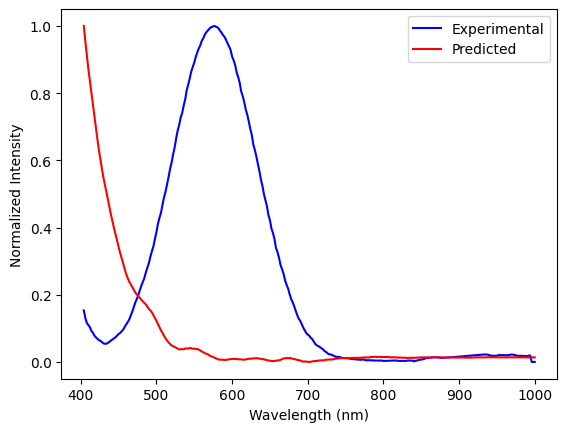

70.0
2.872


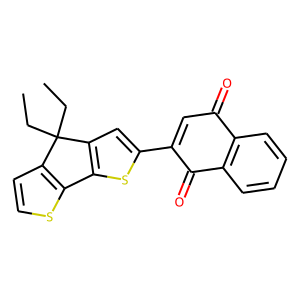

In [47]:
start_wl = 350

x_max_skew_test = []
y_max_skew_test = []

i_y_spec = OPD_application_Final.iloc[1, 3:].to_numpy() # spectrum 뽑고
i_y_spec_numeric = pd.to_numeric(i_y_spec, errors='coerce')
i_pred_spec = final_pred[1]

# Apply nan_mask only to the target spectrum
nan_mask = np.isnan(i_y_spec_numeric)  # target spectrum 으로 : nan MK 생성    
zero_sub = np.zeros_like(i_y_spec_numeric)  # zero MK 생성  

i_y_spec_mask = np.where(nan_mask, zero_sub, i_y_spec_numeric)  # nan 있는 위치 0으로 대체하고 : y
i_pred_spec_mask = i_pred_spec  # pred에 대해서는 nan_mask 적용하지 않음

# Only consider wavelengths above 400nm
valid_indices = np.where(np.linspace(start_wl, 1000, int((1000 - start_wl) / 2 + 1)) > 402)

i_y_spec_mask = i_y_spec_mask[valid_indices]
i_pred_spec_mask = i_pred_spec_mask[valid_indices]

i_y_max_idx = start_wl + (np.nanargmax(i_y_spec_mask) * 2)  # y max 파장 뽑고 
i_y_max_value = np.nanmax(i_y_spec_mask)  # y max 값도 뽑음

lower_bound = max(0, (i_y_max_idx - 70 - start_wl) // 2)  # y 기준 pred 를 범위(+/- 70) 내에서 검색
upper_bound = min(i_pred_spec_mask.size, (i_y_max_idx + 70 - start_wl) // 2 + 1)

i_pred_max_local_idx = np.nanargmax(i_pred_spec_mask[lower_bound:upper_bound])  # i_pred_spec_mask의 해당 범위 내에서 인덱스 찾기
i_pred_max_idx = start_wl + ((lower_bound + i_pred_max_local_idx) * 2)  # 실제 y_pred max 파장으로 변환
i_pred_max_value = np.nanmax(i_pred_spec_mask[lower_bound:upper_bound])  # y_pred 최대값

# Normalize the spectra to the range [0, 1]
i_y_spec_norm = (i_y_spec_mask - np.min(i_y_spec_mask)) / (np.max(i_y_spec_mask) - np.min(i_y_spec_mask))
i_pred_spec_norm = (i_pred_spec_mask - np.min(i_pred_spec_mask)) / (np.max(i_pred_spec_mask) - np.min(i_pred_spec_mask))

X = np.linspace(start_wl, 1000, int((1000 - start_wl) / 2 + 1))[valid_indices]  # x축

y = i_y_spec_norm  # y축
y_pred = i_pred_spec_norm  # y_pred 축

print('index:', 0)     
print('wl_skew:', np.abs(i_y_max_idx - i_pred_max_idx))
print('y_skew:', np.abs(np.log10(i_y_max_value) - np.log10(i_pred_max_value)))
print('SIS:', sis(i_y_spec_numeric, i_pred_spec))

plt.plot(X, y, c='b', label='Experimental')
plt.plot(X, y_pred, c='r', label='Predicted')

# plt.axvline(x=i_y_max_idx, color='skyblue', linestyle='--', linewidth=1.5, label='y_max')
# plt.axvline(x=i_pred_max_idx, color='orange', linestyle='--', linewidth=1.5, label='pred_max')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Intensity')
plt.legend()
plt.show()

x_max_skew_test.append(np.square(i_y_max_idx - i_pred_max_idx))
y_max_skew_test.append(np.square(np.log10(i_y_max_value) - np.log10(i_pred_max_value)))

print(round(np.sqrt(np.mean(x_max_skew_test)), 3))
print(round(np.sqrt(np.mean(y_max_skew_test)), 3))

chr = Chem.MolFromSmiles(OPD_application_Final.iloc[1,0])
sol = Chem.MolFromSmiles(OPD_application_Final.iloc[1,1])
Draw.MolToImage(chr)

wl_skew: 4
extinc_skew: 0.03408718


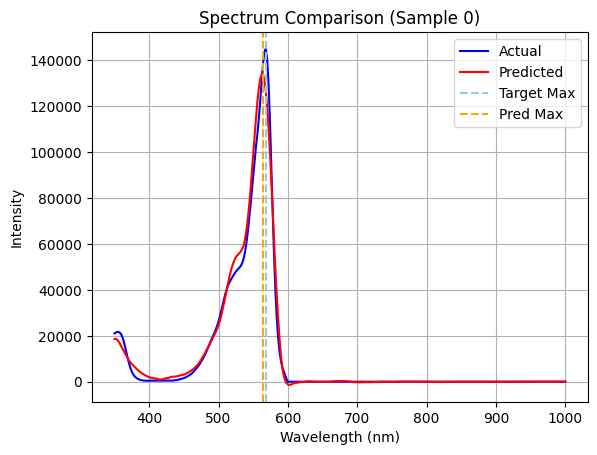

wl_skew: 6
extinc_skew: 0.16788197


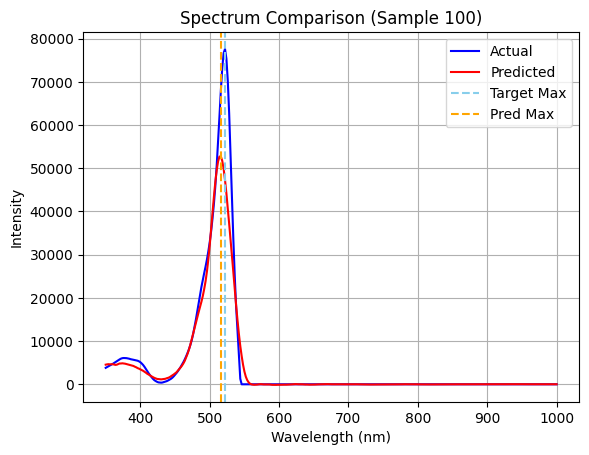

wl_skew: 2
extinc_skew: 0.00090169907


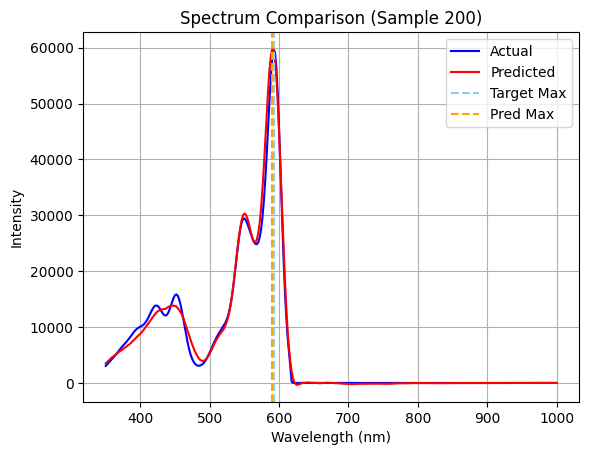

wl_skew: 2
extinc_skew: 0.022732258


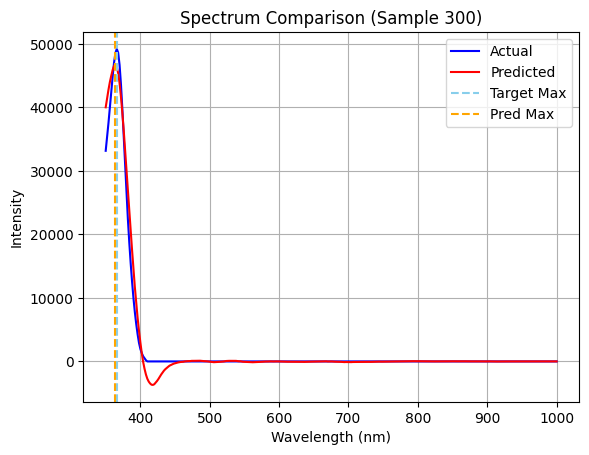

wl_skew: 2
extinc_skew: 0.055056095


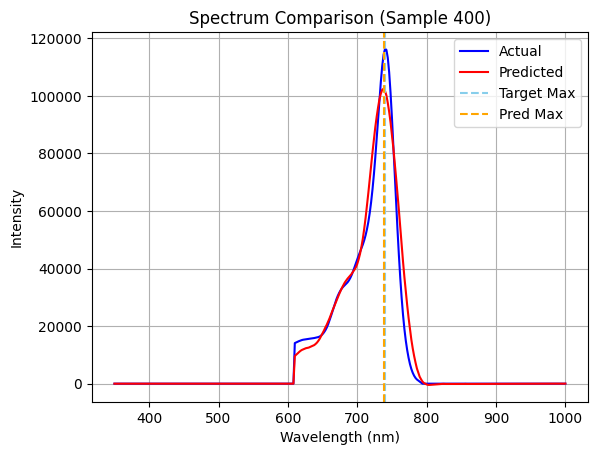

wl_skew: 0
extinc_skew: 0.0126366615


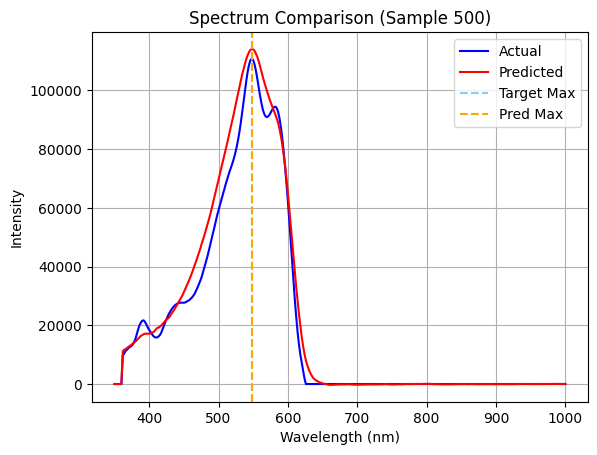

wl_skew: 4
extinc_skew: 0.01095438


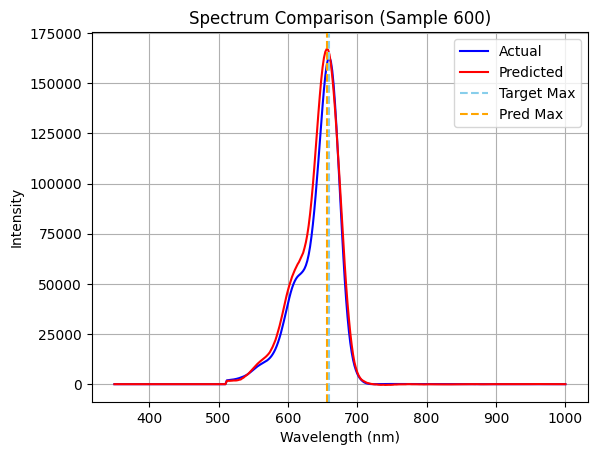

wl_skew: 2
extinc_skew: 0.039355755


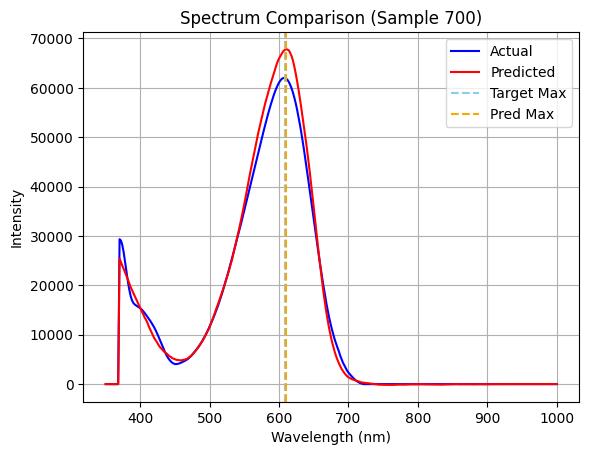

wl_skew: 0
extinc_skew: 0.07681131


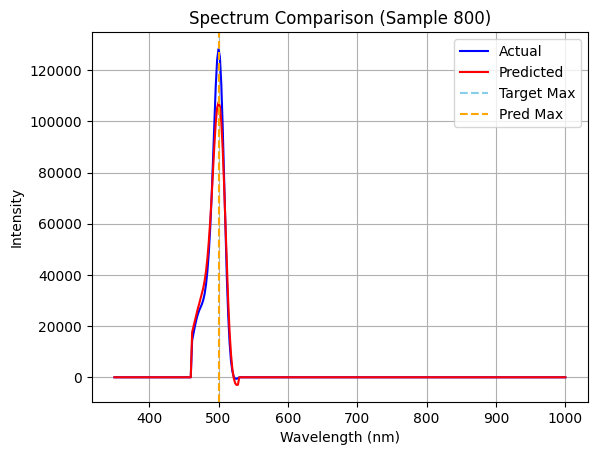

wl_skew: 2
extinc_skew: 0.004116535


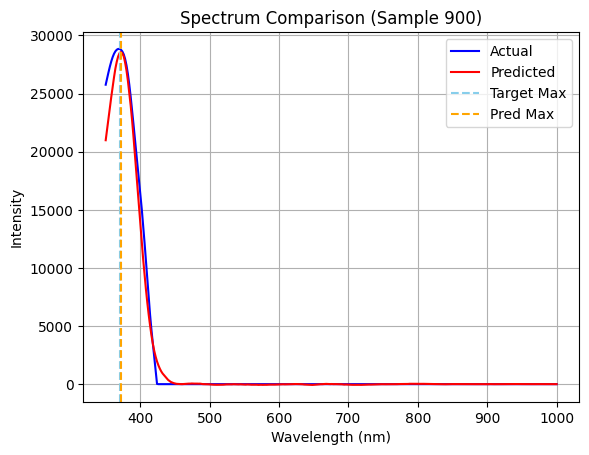

wl_skew: 8
extinc_skew: 0.13707829


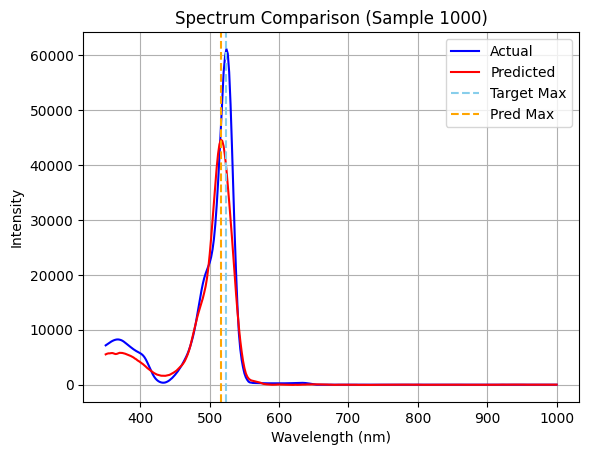

wl_skew: 2
extinc_skew: 0.10962343


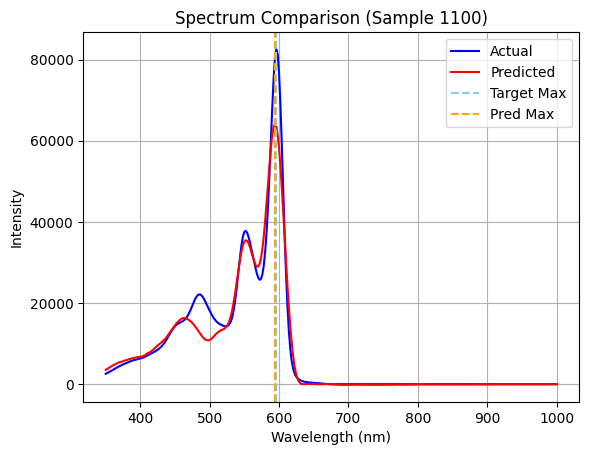

wl_skew: 6
extinc_skew: 0.0876565


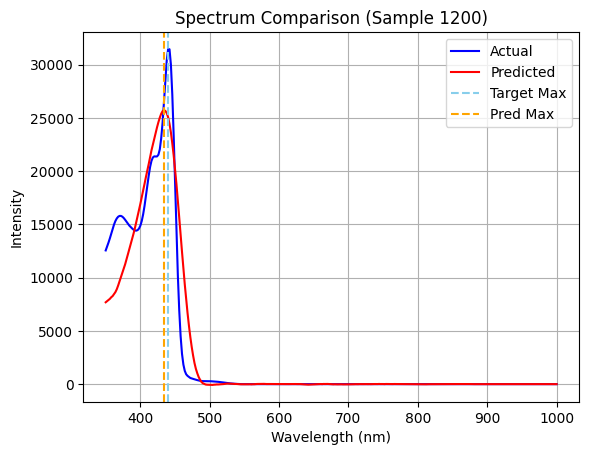

wl_skew: 6
extinc_skew: 0.006254673


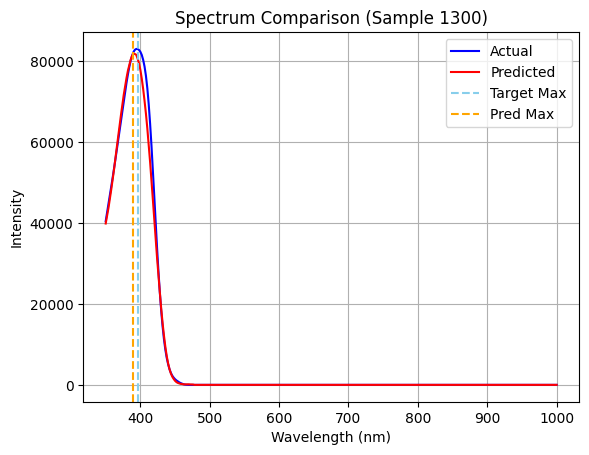

wl_skew: 2
extinc_skew: 0.11622


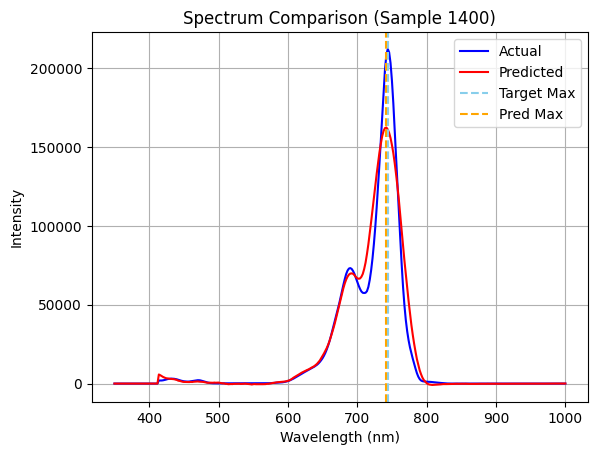

wl_skew: 4
extinc_skew: 0.01833582


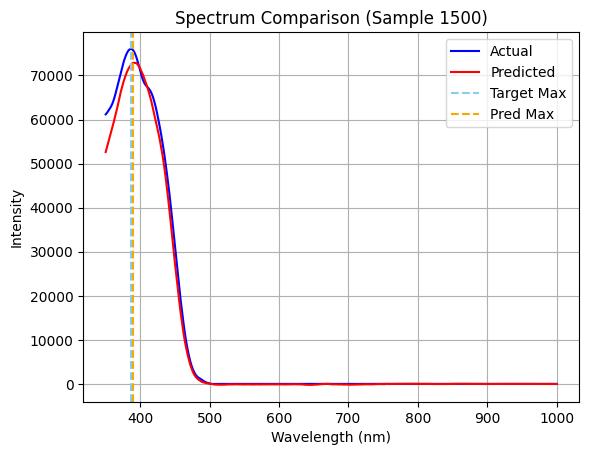

wl_skew: 6
extinc_skew: 0.22784233


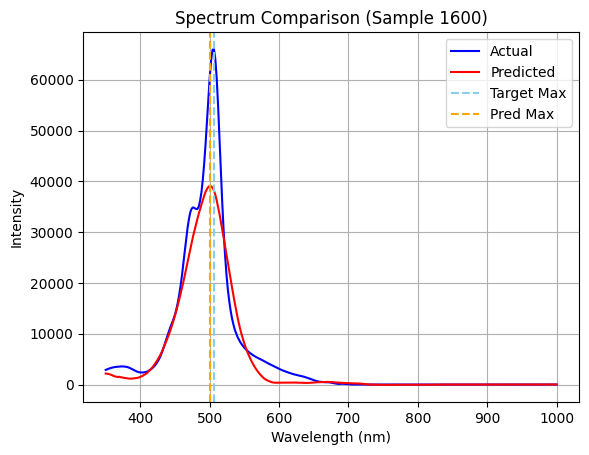

wl_skew: 2
extinc_skew: 0.011985779


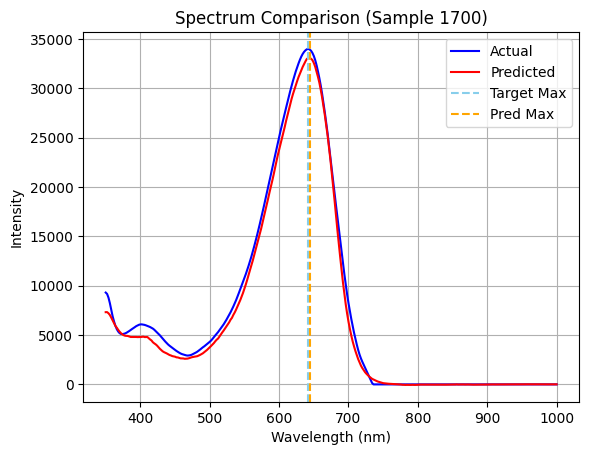

wl_skew: 0
extinc_skew: 0.045856


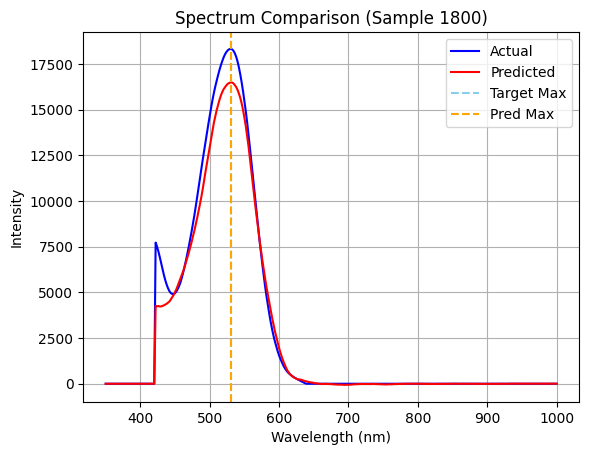

wl_skew: 4
extinc_skew: 0.00040483475


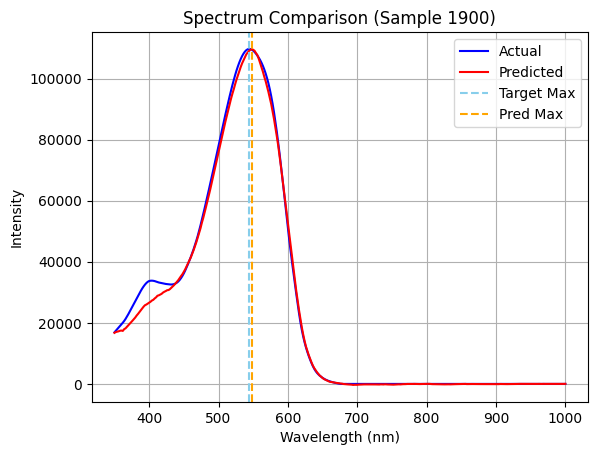

wl_skew: 2
extinc_skew: 0.0141944885


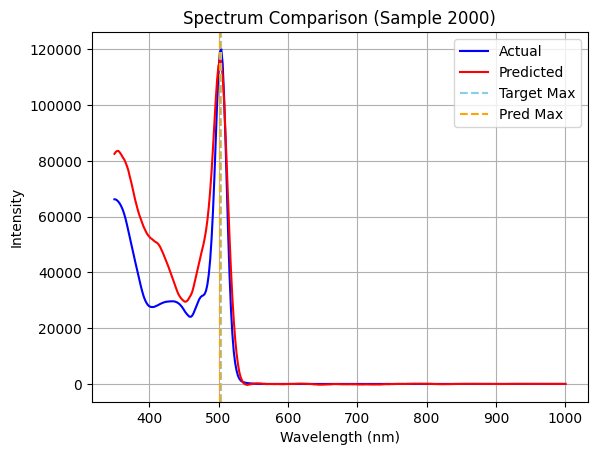

wl_skew: 2
extinc_skew: 0.08198929


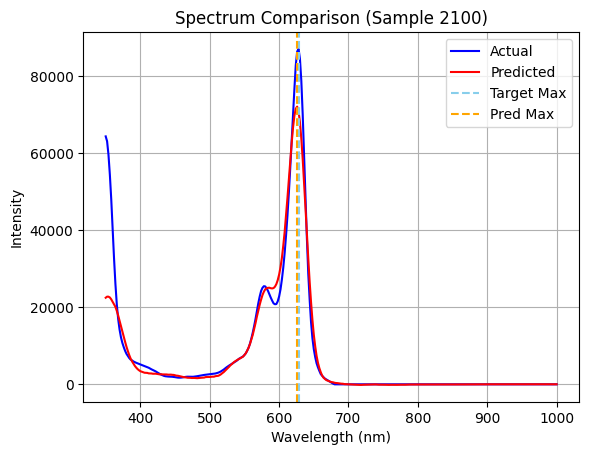

wl_skew: 2
extinc_skew: 0.0026154518


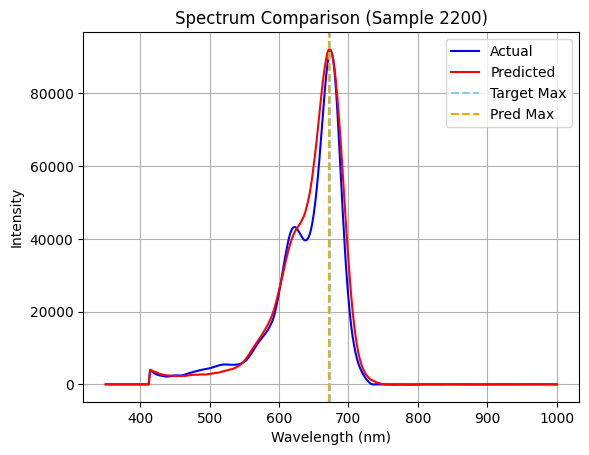

wl_skew: 2
extinc_skew: 0.046394825


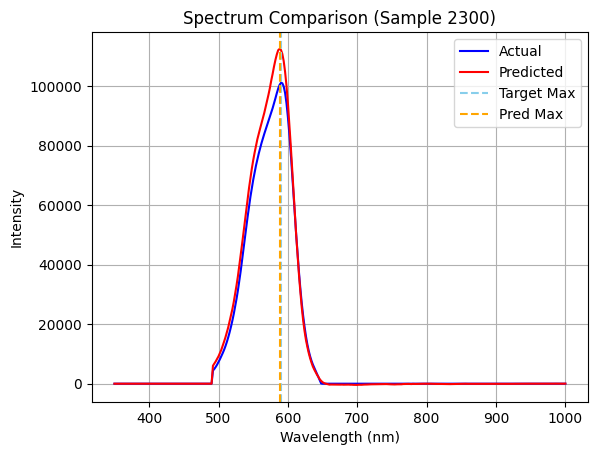

wl_skew: 2
extinc_skew: 0.014576435


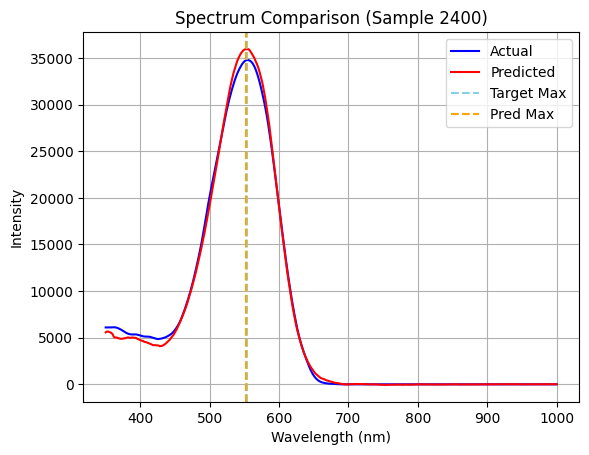

wl_skew: 4
extinc_skew: 0.030164719


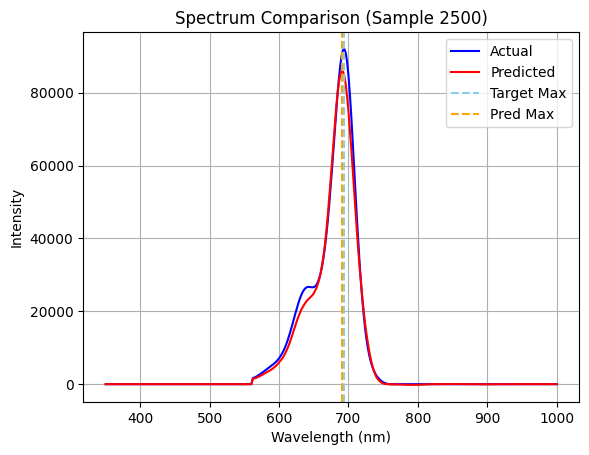

wl_skew: 2
extinc_skew: 0.009610653


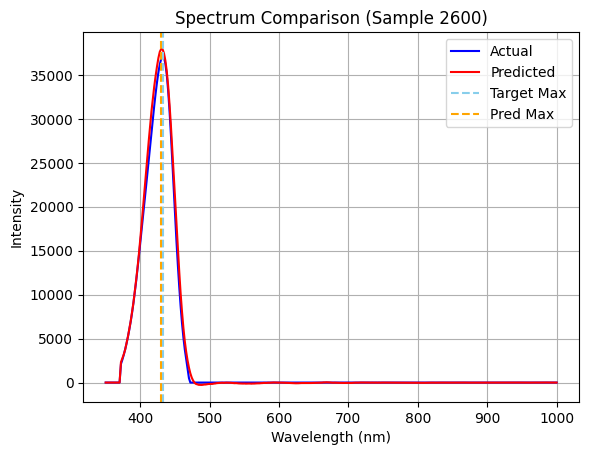

wl_skew: 4
extinc_skew: 0.0181489


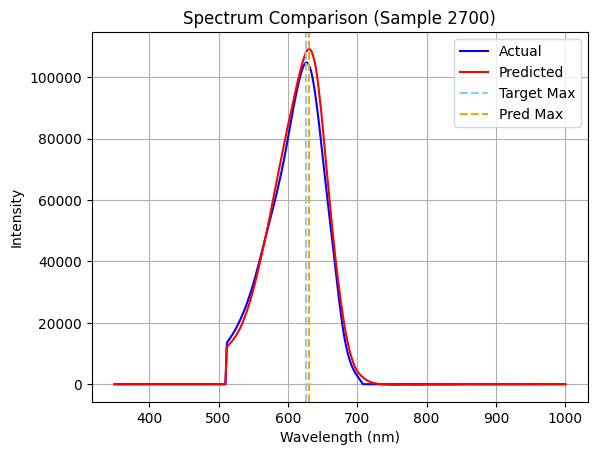

wl_skew: 2
extinc_skew: 0.0439744


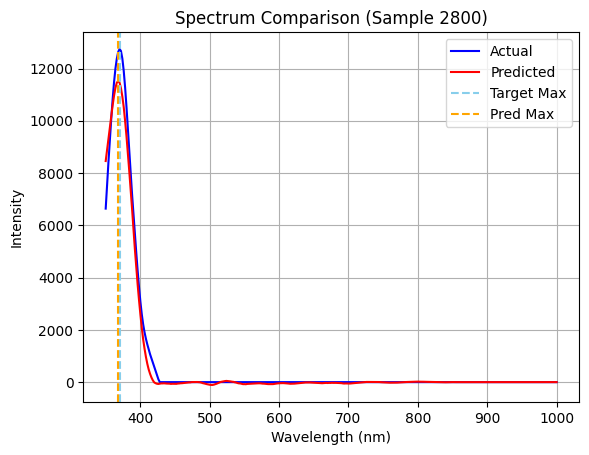

wl_skew: 2
extinc_skew: 0.0015263557


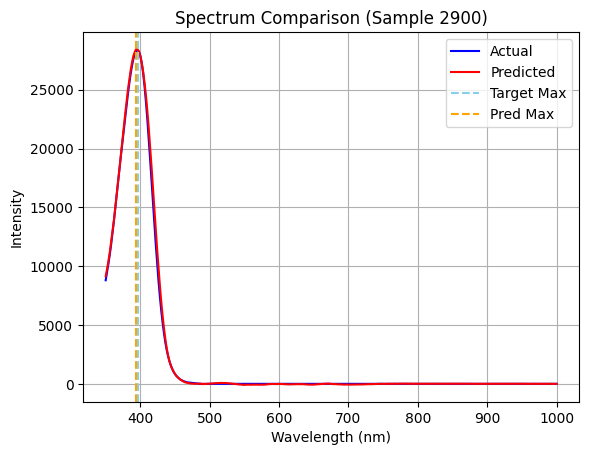

wl_skew: 2
extinc_skew: 0.022863865


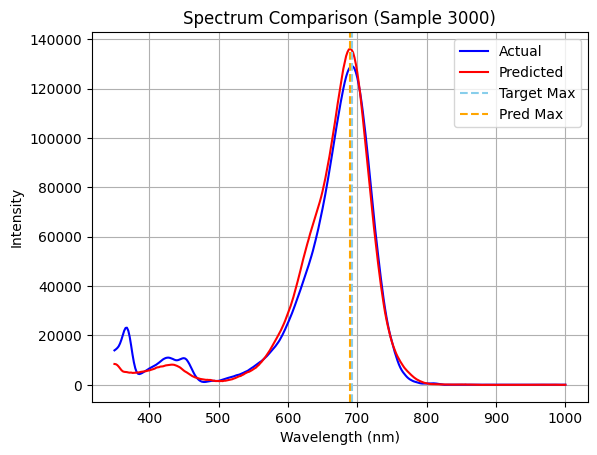

wl_skew: 4
extinc_skew: 0.015097618


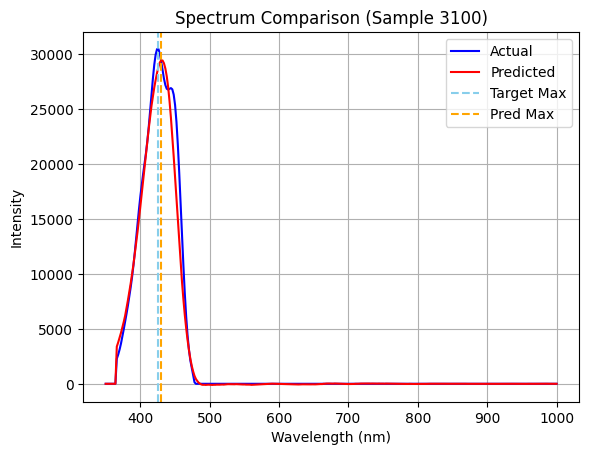

wl_skew: 0
extinc_skew: 0.01726818


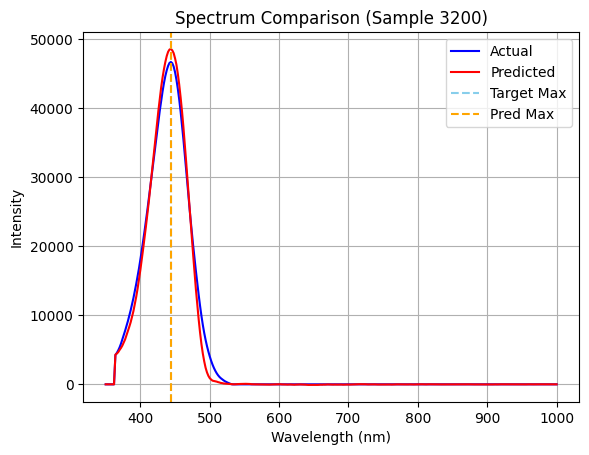

wl_skew: 4
extinc_skew: 0.025209904


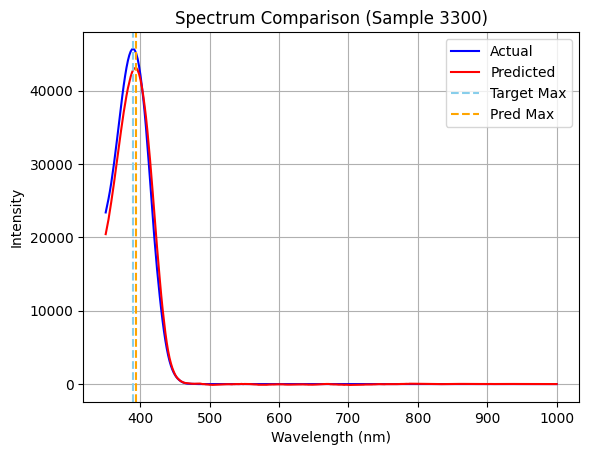

wl_skew: 8
extinc_skew: 0.023217678


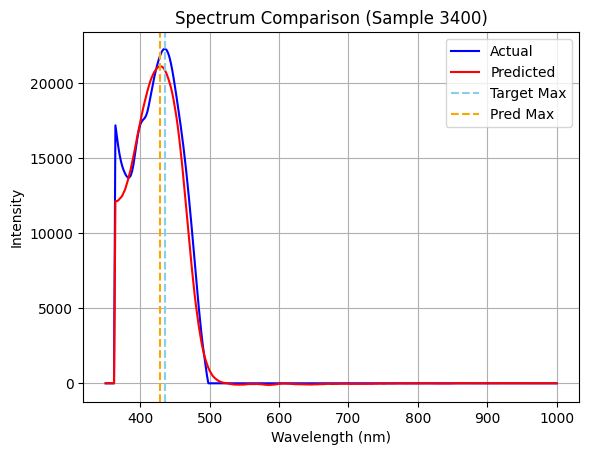

wl_skew: 8
extinc_skew: 0.031163216


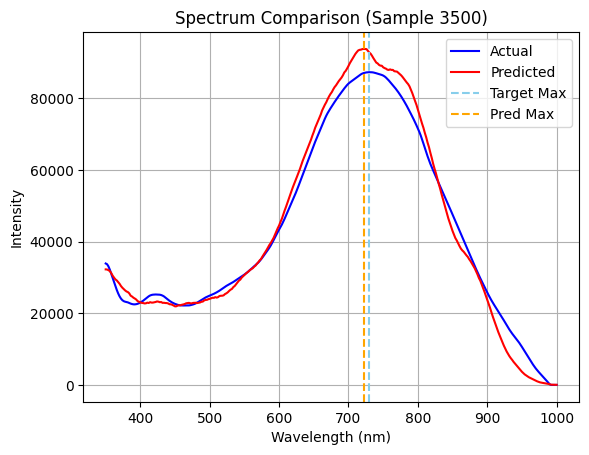

wl_skew: 10
extinc_skew: 0.0306983


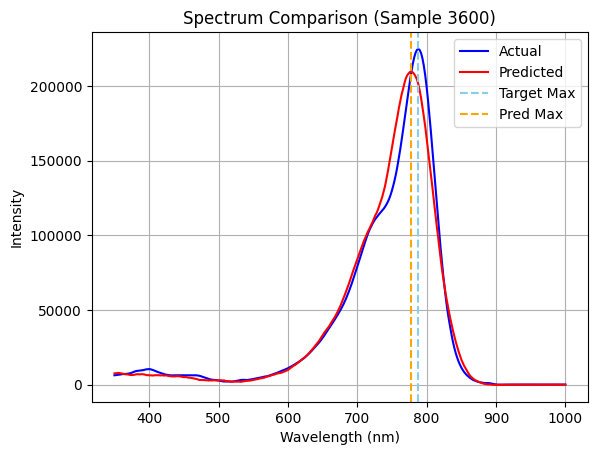

wl_skew: 0
extinc_skew: 0.045594215


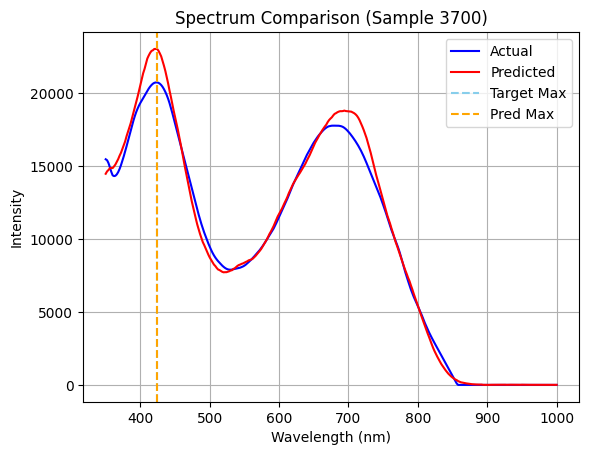

wl_skew: 4
extinc_skew: 0.019935608


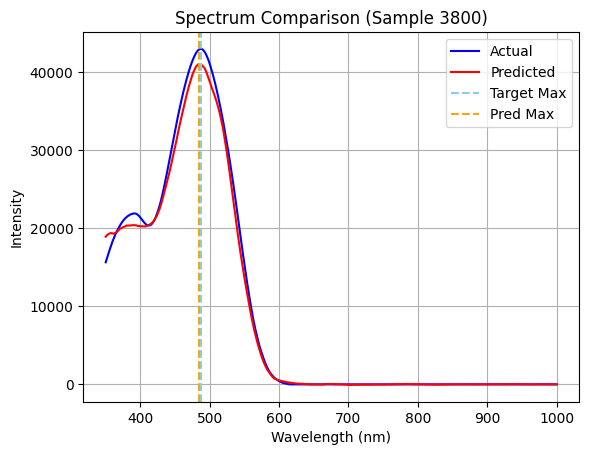

wl_skew: 4
extinc_skew: 0.020586014


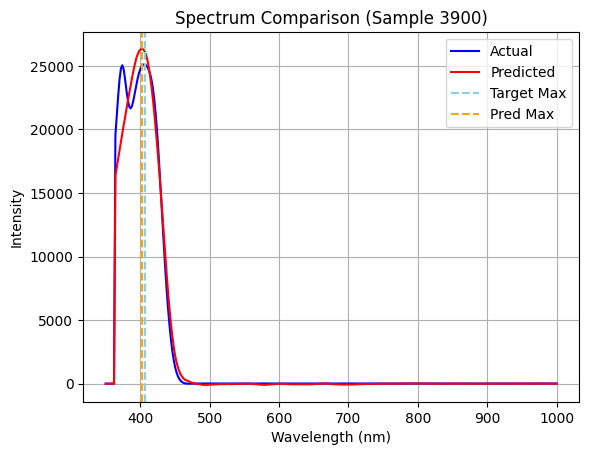

wl_skew: 4
extinc_skew: 0.022351265


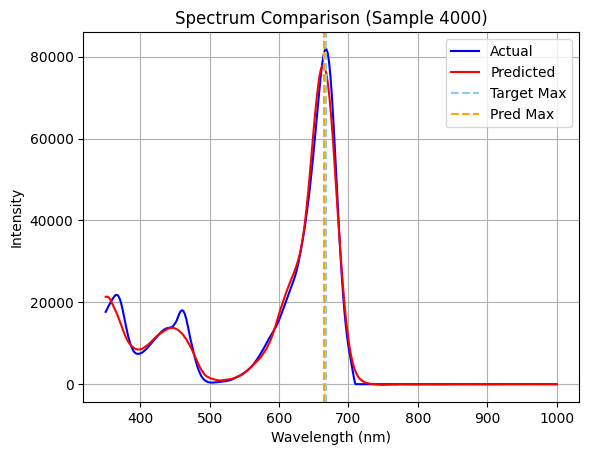

wl_skew: 0
extinc_skew: 0.02042532


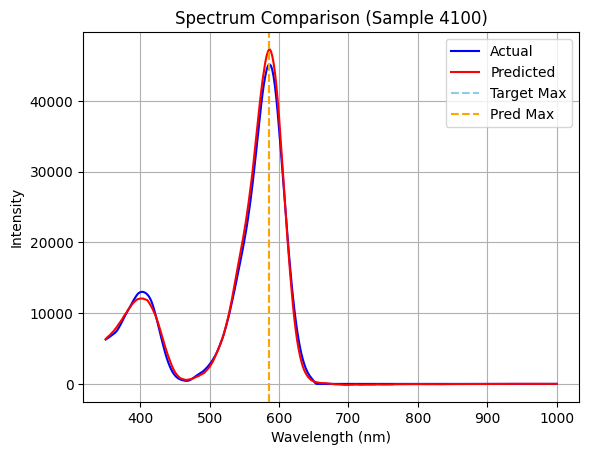

wl_skew: 4
extinc_skew: 0.05536127


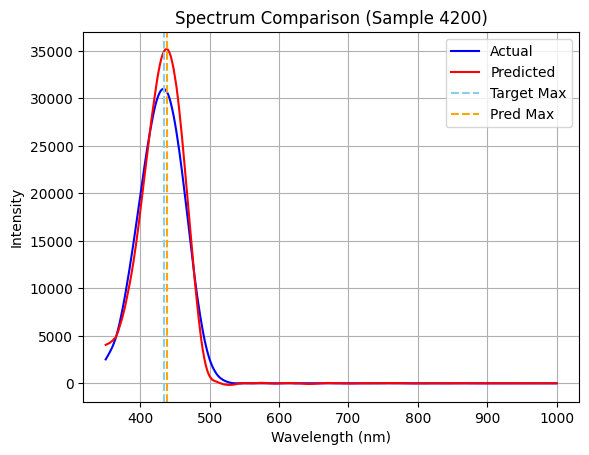

wl_skew: 4
extinc_skew: 0.07171869


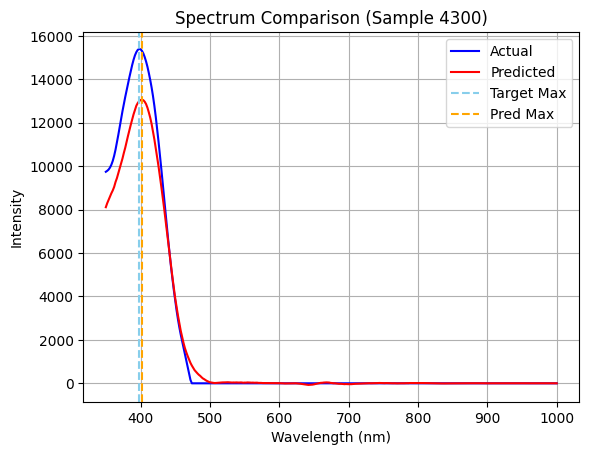

wl_skew: 6
extinc_skew: 0.012313843


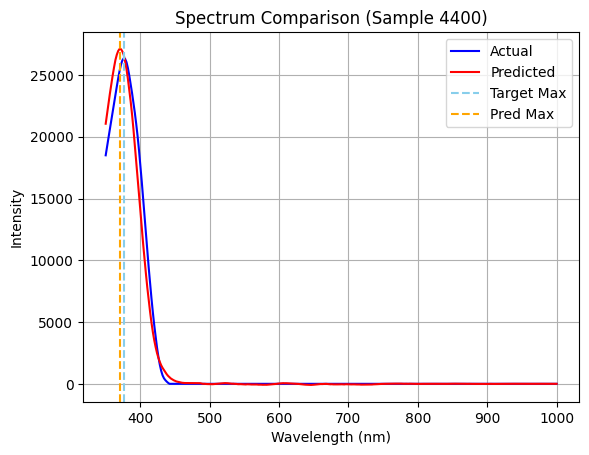

wl_skew: 12
extinc_skew: 0.06577206


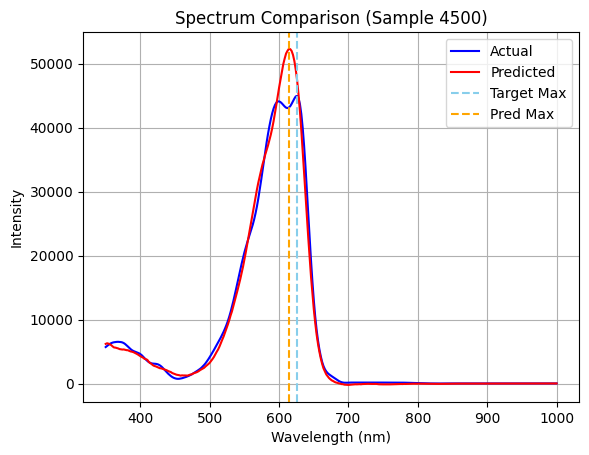

wl_skew: 4
extinc_skew: 0.0018281937


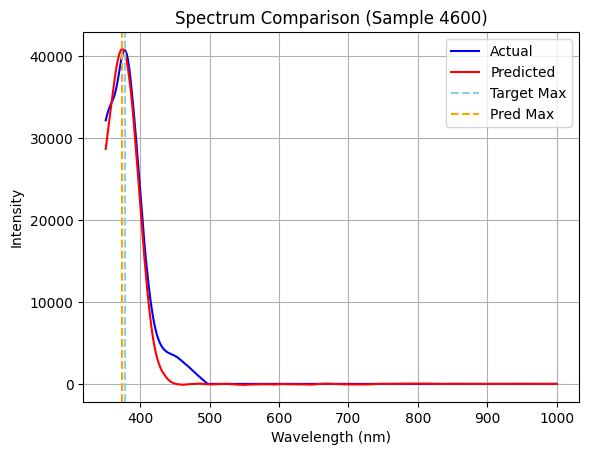

wl_skew: 2
extinc_skew: 0.035342693


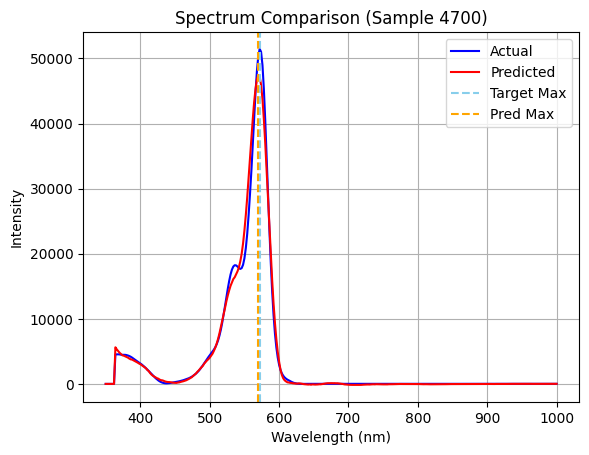

wl_skew: 2
extinc_skew: 0.044672012


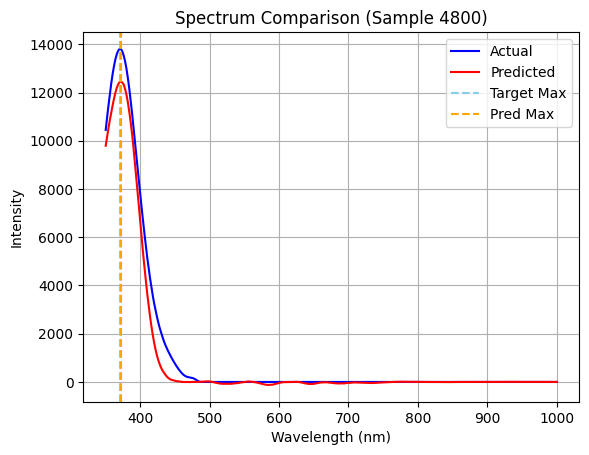

wl_skew: 0
extinc_skew: 0.049212933


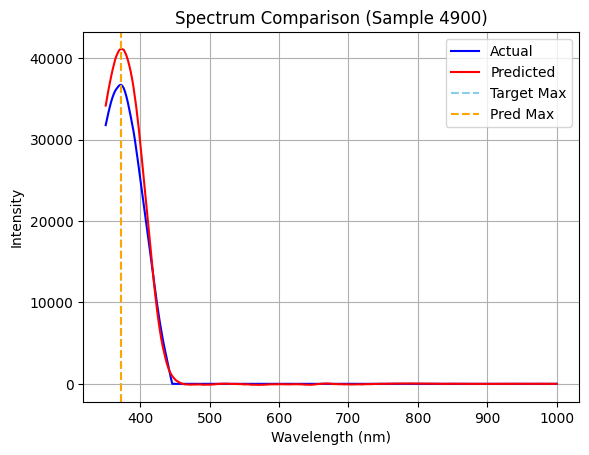

wl_skew: 34
extinc_skew: 0.029110432


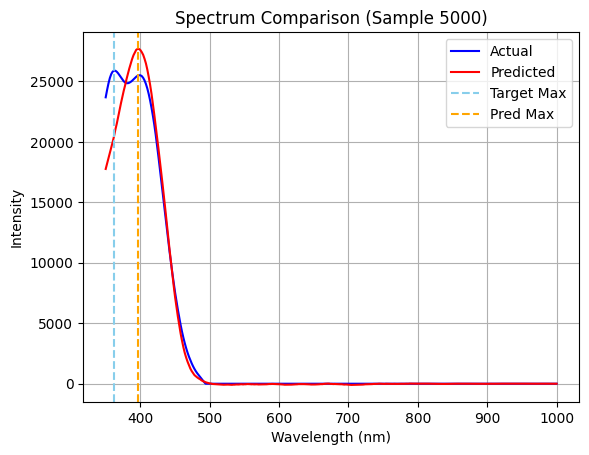

wl_skew: 0
extinc_skew: 0.006755352


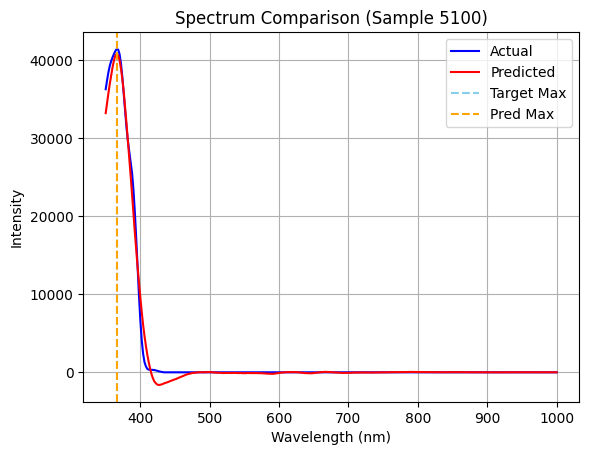

wl_skew: 6
extinc_skew: 0.032458782


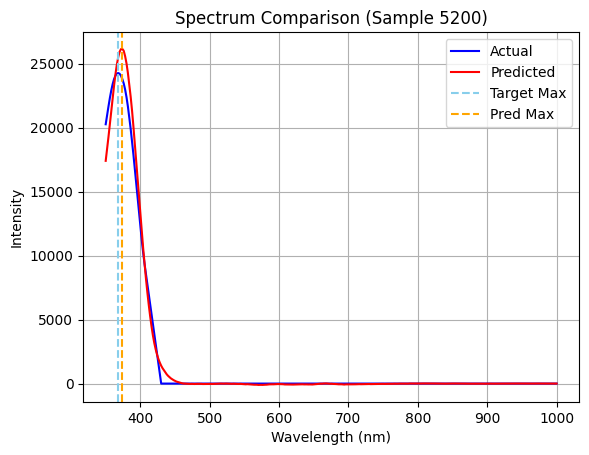

wl_skew: 4
extinc_skew: 0.06459904


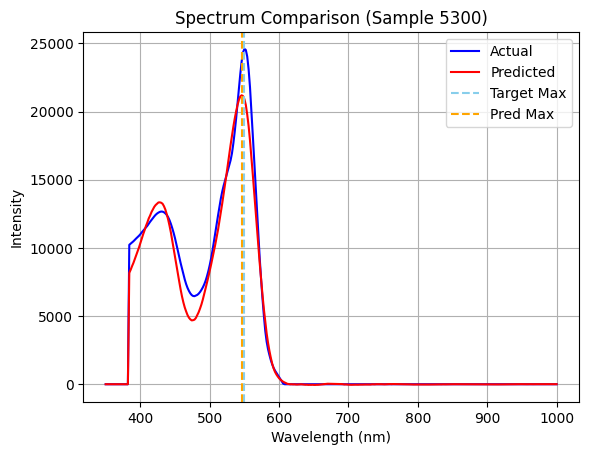

wl_skew: 2
extinc_skew: 0.023101807


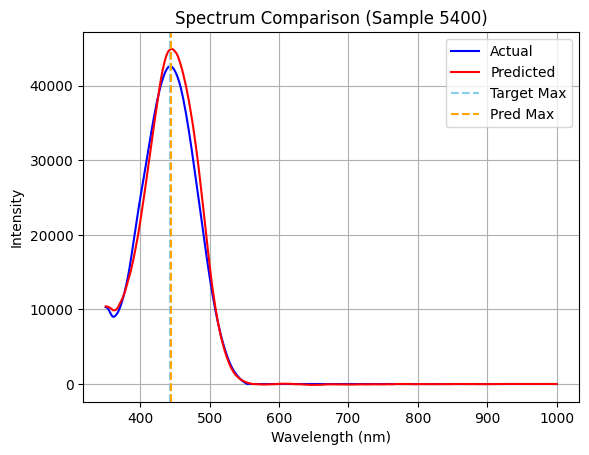

wl_skew: 4
extinc_skew: 0.02217102


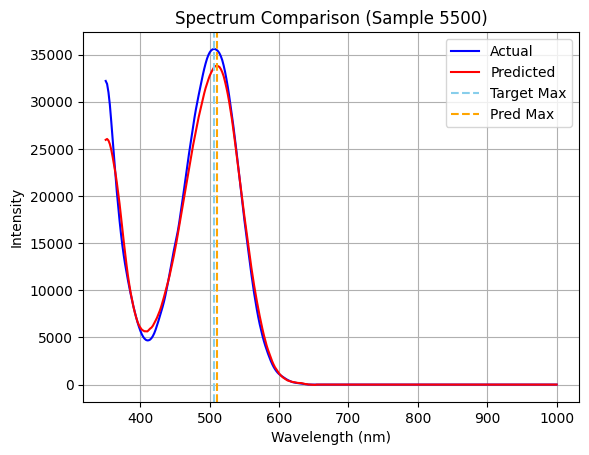

wl_skew: 4
extinc_skew: 0.05942774


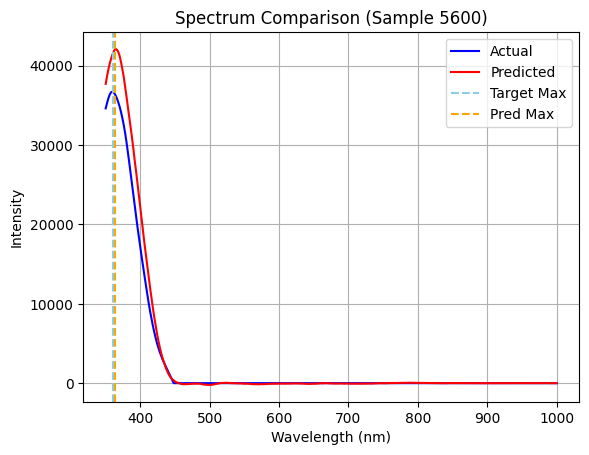

wl_skew: 2
extinc_skew: 0.0725317


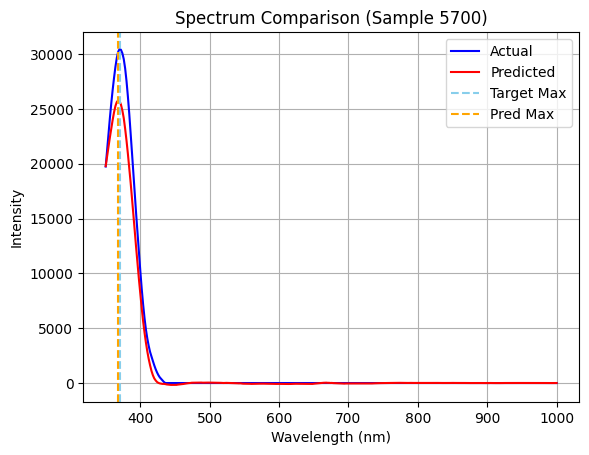

wl_skew: 6
extinc_skew: 0.05181551


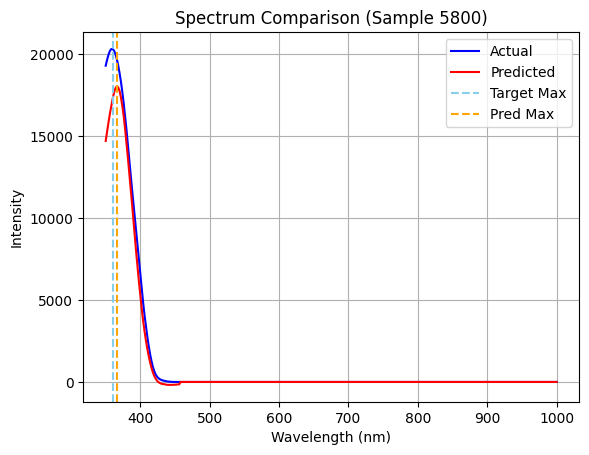

wl_skew: 4
extinc_skew: 0.007265568


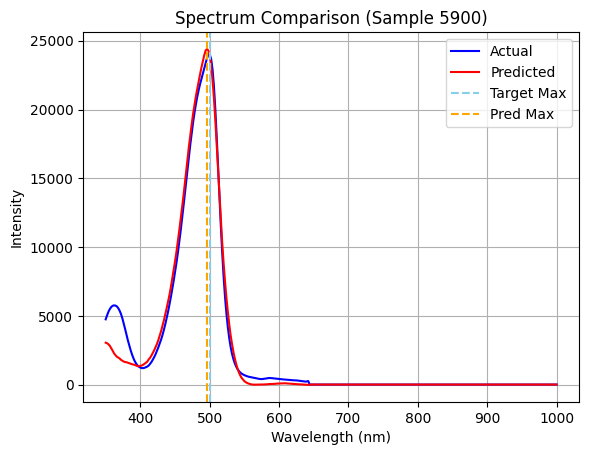

wl_skew: 44
extinc_skew: 0.25257993


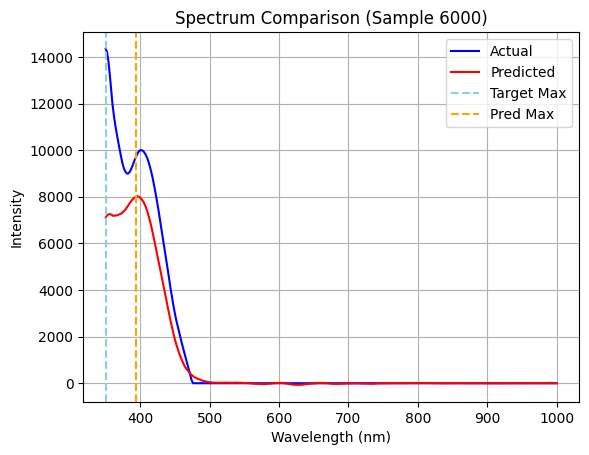

wl_skew: 2
extinc_skew: 0.007967472


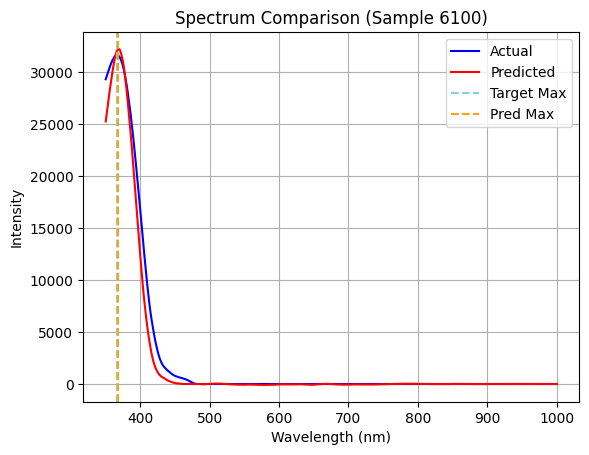

wl_skew: 4
extinc_skew: 0.001452446


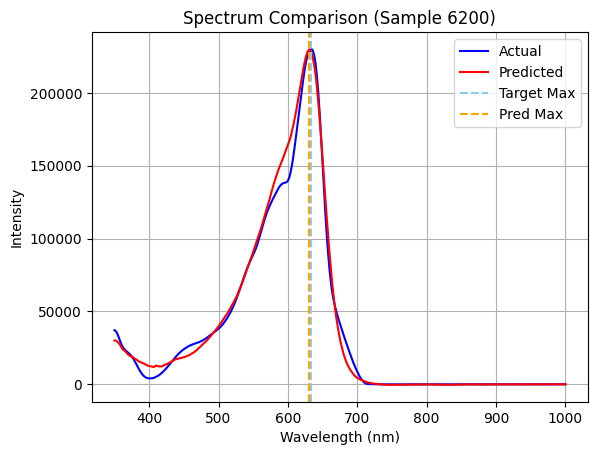

wl_skew: 2
extinc_skew: 0.051004887


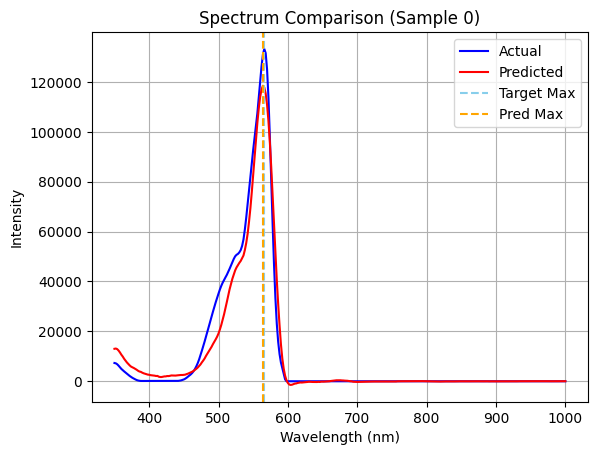

wl_skew: 18
extinc_skew: 0.26385355


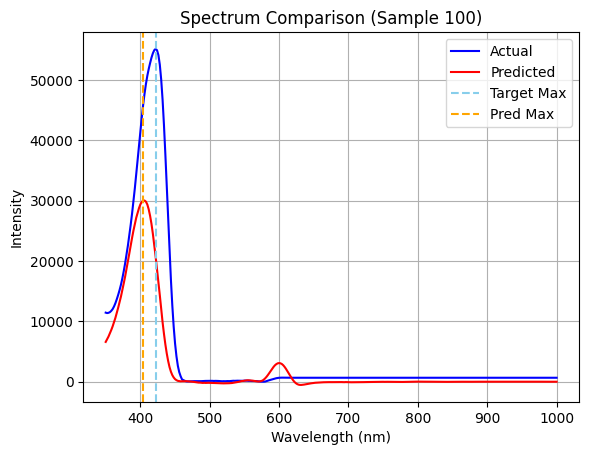

wl_skew: 8
extinc_skew: 0.14419079


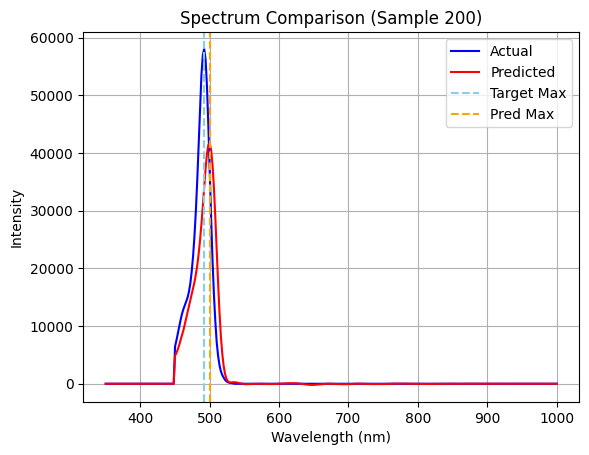

wl_skew: 34
extinc_skew: 0.08880234


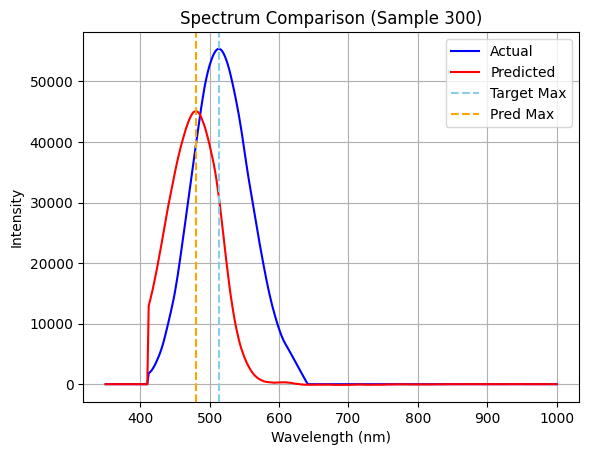

wl_skew: 28
extinc_skew: 0.6762018


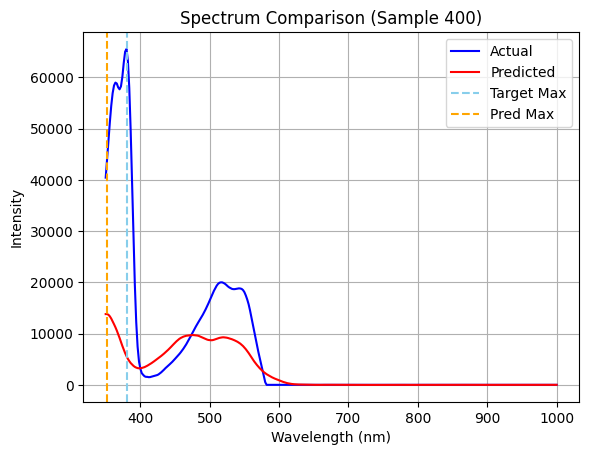

wl_skew: 0
extinc_skew: 0.2011261


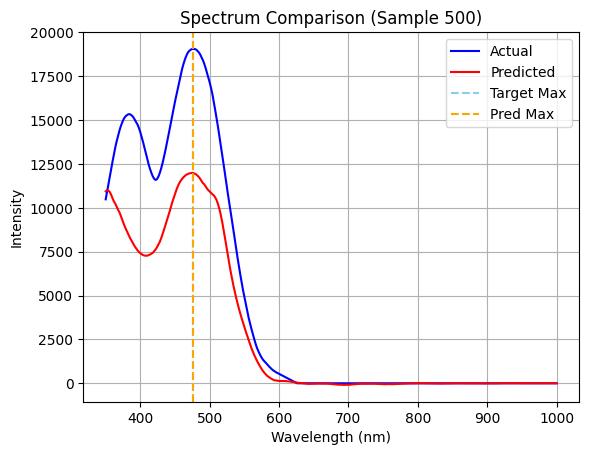

wl_skew: 0
extinc_skew: 0.07756376


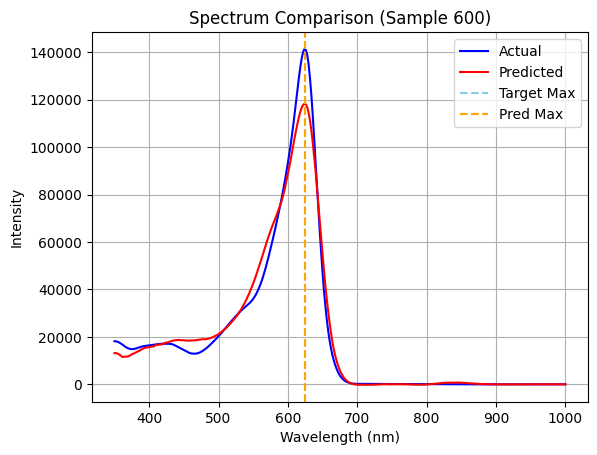

wl_skew: 12
extinc_skew: 0.3429513


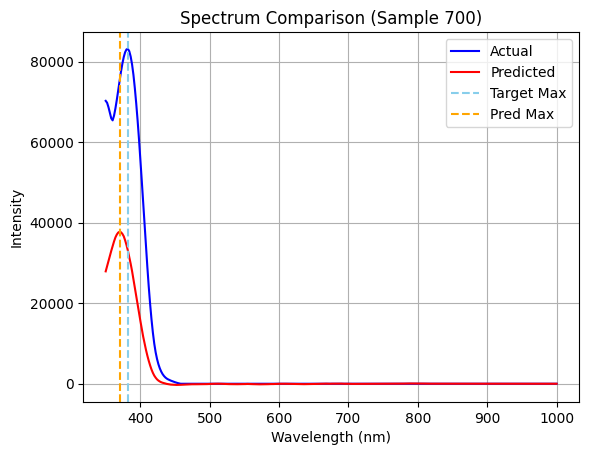

wl_skew: 16
extinc_skew: 0.31929564


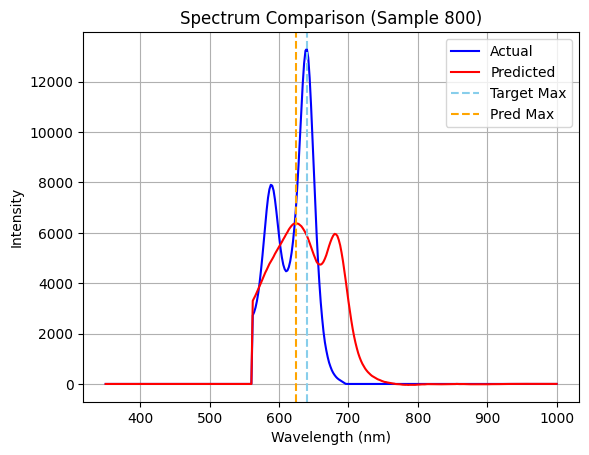

wl_skew: 30
extinc_skew: 0.28302383


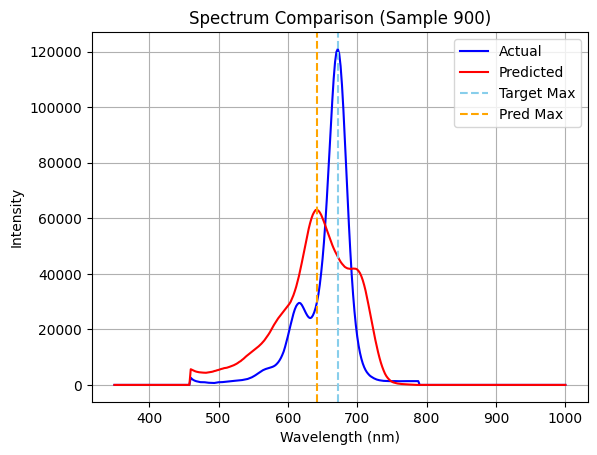

wl_skew: 8
extinc_skew: 0.11939263


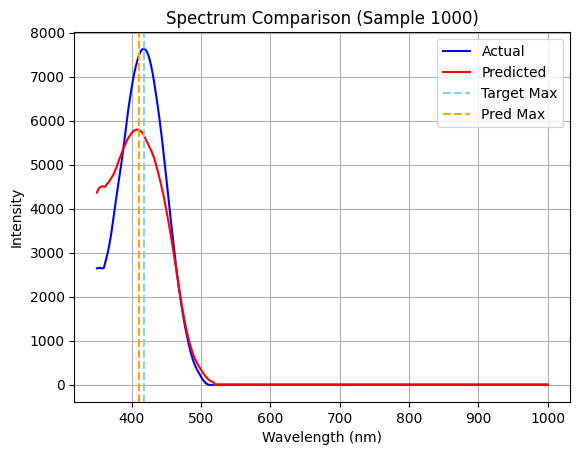

wl_skew: 8
extinc_skew: 0.1186049


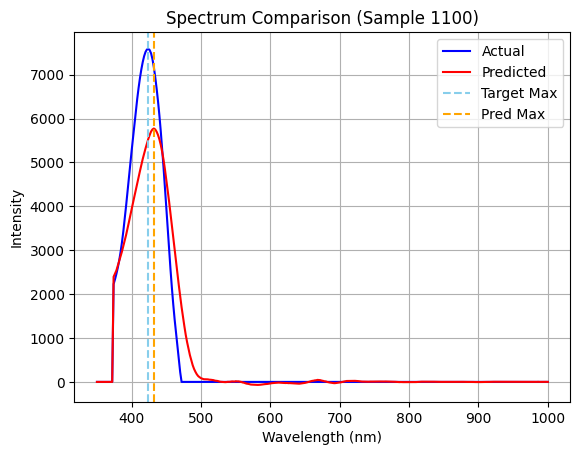

wl_skew: 18
extinc_skew: 0.6149111


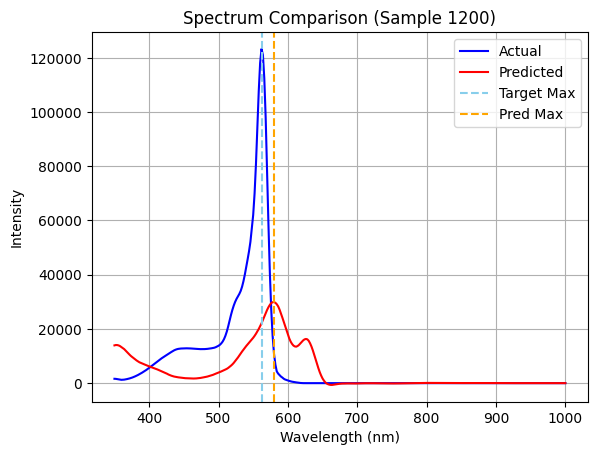

wl_skew: 2
extinc_skew: 0.15364885


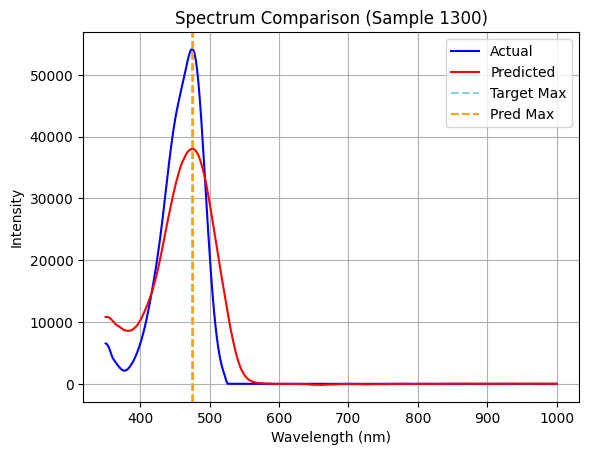

wl_skew: 32
extinc_skew: 0.33094454


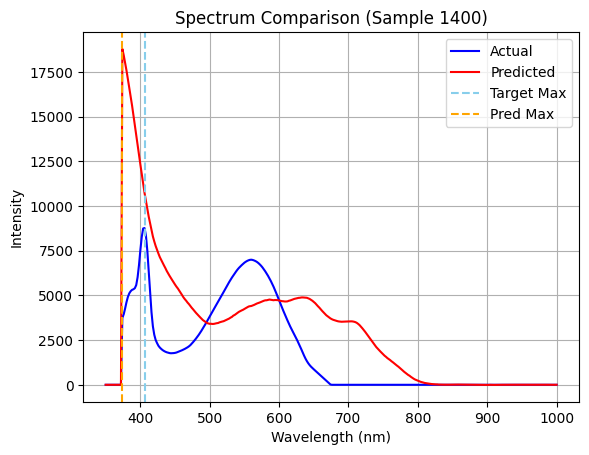

Train MAE WL Skew: 4.878
Train MAE Y Skew: 0.04500000178813934
Validation MAE WL Skew: 17.258
Validation MAE Y Skew: 0.164000004529953


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define wl_skew and y_skew calculation function
def calculate_skews(pred, target, start_wl=350, step=2, range_window=100):
    nan_mask = np.isnan(target)
    zero_sub = np.zeros_like(target)

    target_mask = np.where(nan_mask, zero_sub, target)
    pred_mask = np.where(nan_mask, zero_sub, pred)

    target_max_idx = start_wl + (np.nanargmax(target_mask) * step)
    target_max_value = np.nanmax(target_mask)

    lower_bound = max(0, (target_max_idx - range_window - start_wl) // step)
    upper_bound = min(pred_mask.size, (target_max_idx + range_window - start_wl) // step + 1)

    pred_max_local_idx = np.nanargmax(pred_mask[lower_bound:upper_bound])
    pred_max_idx = start_wl + ((lower_bound + pred_max_local_idx) * step)
    pred_max_value = np.nanmax(pred_mask[lower_bound:upper_bound])

    wl_skew = np.abs(target_max_idx - pred_max_idx)
    y_skew = np.abs(np.log10(target_max_value) - np.log10(pred_max_value))

    return wl_skew, y_skew, target_mask, pred_mask, target_max_idx, pred_max_idx

# Function to process all batches
def process_batches(pred_set, target_set, start_wl=350):
    x_skews, y_skews = [], []

    for i in range(len(pred_set)):
        target = target_set[i]
        pred = pred_set[i]

        wl_skew, y_skew, target_mask, pred_mask, target_max_idx, pred_max_idx = calculate_skews(pred, target, start_wl)

        x_skews.append(wl_skew)
        y_skews.append(y_skew)

        if i % 100 == 0:

            print('wl_skew:', wl_skew)
            print('extinc_skew:', y_skew)
            
            # Optionally plot the spectrum
            X = np.linspace(start_wl, 1000, int((1000 - start_wl) / 2 + 1))
    
            plt.figure()
            plt.plot(X, target_mask, c='b', label='Actual')
            plt.plot(X, pred_mask, c='r', label='Predicted')
            plt.axvline(x=target_max_idx, color='skyblue', linestyle='--', linewidth=1.5, label='Target Max')
            plt.axvline(x=pred_max_idx, color='orange', linestyle='--', linewidth=1.5, label='Pred Max')
            plt.title(f'Spectrum Comparison (Sample {i})')
            plt.xlabel('Wavelength (nm)')
            plt.ylabel('Intensity')
            plt.legend()
            plt.grid(True)
            plt.show()

    mae_wl_skew = round(np.mean(x_skews), 3)
    mae_y_skew = round(np.mean(y_skews), 3)

    return mae_wl_skew, mae_y_skew

# Example usage
train_wl_skew, train_y_skew = process_batches(train_pred, train_y)
val_wl_skew, val_y_skew = process_batches(val_pred, val_y)

print(f"Train MAE WL Skew: {train_wl_skew}")
print(f"Train MAE Y Skew: {train_y_skew}")
print(f"Validation MAE WL Skew: {val_wl_skew}")
print(f"Validation MAE Y Skew: {val_y_skew}")